# Virginia Regional Economic Intelligence

## 04 — Economic Development Document Intelligence

Virginia's regional economy is shaped not only by historical employment trends but also by forward-looking developments such as business expansions, new facilities, capital investment, workforce initiatives, and economic-development projects.

Many of these signals first appear in press releases and public-sector documents rather than structured datasets.

This notebook develops a reproducible document-intelligence workflow that converts unstructured Virginia economic-development announcements into structured analytical data.

## 1. Research Objective

### Research Question

**What forward-looking economic-development signals can be extracted from public Virginia documents, and how do those signals relate to the regional employment patterns identified in the QCEW analysis?**

The workflow is designed to identify and structure information such as:

- company or organization,
- announcement date,
- Virginia locality,
- project type,
- announced capital investment,
- announced job creation,
- industry or economic theme,
- workforce-development references,
- infrastructure or site-development references,
- and the original document text and source.

The resulting document-level dataset can then be compared with the historical regional indicators developed in Notebook 03.

### Analytical Design

The document-intelligence pipeline contains five stages:

1. **Document discovery**  
   Collect official Virginia economic-development announcements from the Virginia Economic Development Partnership.

2. **Text acquisition and cleaning**  
   Download the underlying webpages and convert their HTML content into clean document text.

3. **Structured information extraction**  
   Extract entities and quantitative information such as companies, localities, investment amounts, and announced jobs.

4. **Semantic classification**  
   Use NLP and AI-assisted text representations to classify announcements into economically meaningful themes.

5. **Economic integration**  
   Connect extracted announcements with locality and industry indicators from the QCEW regional analysis.

The objective is not simply to summarize documents. It is to transform unstructured public information into a reproducible analytical dataset.

### Source Corpus

The primary document source is the **Virginia Economic Development Partnership (VEDP) press-release archive**.

VEDP announcements are particularly useful for this analysis because they regularly contain structured economic signals embedded within narrative text, including:

- project location,
- company name,
- capital investment,
- expected job creation,
- business expansion or relocation status,
- industry descriptions,
- workforce-development programs,
- and state or local economic-development support.

Using an official public source also provides a transparent and reproducible document corpus for policy-oriented analysis.

In [1]:
# Import libraries used for document acquisition, text processing,
# structured extraction, and later NLP analysis.

from pathlib import Path
import re
import time
import json

import numpy as np
import pandas as pd
import requests

from bs4 import BeautifulSoup
from urllib.parse import urljoin

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
# Define project paths for the document-intelligence workflow.
# ------------------------------------------------------------
# Raw HTML and extracted text are stored separately from structured
# outputs so that the acquisition process remains reproducible.

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DOCUMENT_DIR = DATA_DIR / "raw" / "vedp_press_releases"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"

RAW_DOCUMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Raw document directory:\n{RAW_DOCUMENT_DIR}")

Raw document directory:
C:\Users\Chris\Documents\virginia-regional-economic-intelligence\data\raw\vedp_press_releases


In [3]:
# Define the official VEDP press-release archive used as the
# starting point for document discovery.

VEDP_BASE_URL = "https://www.vedp.org"
VEDP_PRESS_RELEASE_URL = (
    "https://www.vedp.org/press-releases"
)

print(f"Document source:\n{VEDP_PRESS_RELEASE_URL}")

Document source:
https://www.vedp.org/press-releases


## 2. Document Discovery

Before collecting the full press-release corpus, the archive page is inspected to confirm that it is accessible programmatically and to identify the HTML structure used for document links.

This validation step reduces the risk of building a scraper around assumptions about the webpage structure.

In [4]:
# Request the VEDP press-release archive and validate the response.
# -----------------------------------------------------------------
# A descriptive User-Agent is provided because this workflow accesses
# a public website programmatically for research purposes.

HEADERS = {
    "User-Agent": (
        "VirginiaRegionalEconomicIntelligence/1.0 "
        "(public policy research project)"
    )
}

response = requests.get(
    VEDP_PRESS_RELEASE_URL,
    headers=HEADERS,
    timeout=30
)

print(f"HTTP status: {response.status_code}")
print(f"Downloaded HTML size: {len(response.content) / 1_000:.1f} KB")

response.raise_for_status()

HTTP status: 200
Downloaded HTML size: 28.3 KB


In [5]:
# Parse the archive HTML and inspect the page title.
# --------------------------------------------------
# BeautifulSoup converts the raw HTML into a searchable document tree
# that can be used to discover press-release links and metadata.

archive_soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print(
    "Page title:",
    archive_soup.title.get_text(strip=True)
    if archive_soup.title
    else "No title found"
)

Page title: Press Releases | Virginia Economic Development Partnership


### Inspect Press-Release Link Structure

The archive page is now searched for hyperlinks that appear to point to individual press releases.

Rather than hard-coding a URL pattern in advance, the link structure is inspected directly so the scraper can be based on the website's actual HTML.

In [6]:
# Inspect candidate hyperlinks from the press-release archive.
# ------------------------------------------------------------
# Only links containing "press-release" are displayed so we can identify
# the URL pattern used for individual VEDP announcements.

candidate_links = []

for tag in archive_soup.find_all("a", href=True):
    href = tag["href"].strip()
    text = tag.get_text(" ", strip=True)

    if "press-release" in href.lower():
        candidate_links.append(
            {
                "link_text": text,
                "href": href
            }
        )

candidate_links_df = (
    pd.DataFrame(candidate_links)
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    f"Candidate press-release links found: "
    f"{len(candidate_links_df):,}"
)

candidate_links_df.head(30)

Candidate press-release links found: 10


,link_text,href
0,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,/press-release/2026-08/chesapeake-defense-maritime-solutions
1,Virginia Steel Expands in Bland County,/press-release/2026-08/bland-virginia-steel
2,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,/press-release/2026-07/valet-summer-2026
3,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,/press-release/2026-07/hepburn-and-sons-prince-william
4,Virginia Rises to America’s Top 3 for Business,/press-release/2026-07/cnbc-2026
5,Virginia Ranked No. 1 in Nation for Customized Workforce Training,/press-release/2026-07/customized-workforce-training-2026
6,Rural King Invests $40M in Henry County,/press-release/2026-06/rural-king-henry
7,RINGANA Establishes First U.S. Headquarters in Roanoke,/press-release/2026-06/ringana-roanoke
8,Scout Space to Create 31 New Jobs in Fairfax County,/press-release/2026-06/scout-space-fairfax
9,Virginia Solar Panel Startup Invests $23M in Shenandoah County,/press-release/2026-06/msolar-shenandoah


### Inspect Archive Pagination

The current archive page exposes 10 individual press releases.

Before collecting a larger historical corpus, the page is inspected for pagination or archive-navigation links. Identifying the site's actual navigation structure allows the discovery process to remain reproducible rather than relying on guessed page parameters.

In [7]:
# Inspect links that may control pagination or archive navigation.
# ---------------------------------------------------------------
# We search for URLs containing common pagination terms such as
# "page", "pager", or "offset" and display their visible link text.

pagination_candidates = []

for tag in archive_soup.find_all("a", href=True):
    href = tag["href"].strip()
    text = tag.get_text(" ", strip=True)

    href_lower = href.lower()

    if any(
        term in href_lower
        for term in ["page", "pager", "offset"]
    ):
        pagination_candidates.append(
            {
                "link_text": text,
                "href": href
            }
        )

pagination_candidates_df = (
    pd.DataFrame(pagination_candidates)
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    f"Candidate pagination links found: "
    f"{len(pagination_candidates_df):,}"
)

pagination_candidates_df

Candidate pagination links found: 7


,link_text,href
0,Current page 1,?page=0
1,Page 2,?page=1
2,Page 3,?page=2
3,Page 4,?page=3
4,Page 5,?page=4
5,Next page Next,?page=1
6,Last page Last »,?page=215


### Build a Reusable Document-Discovery Function

The archive uses a zero-indexed `page` parameter for pagination.

A reusable discovery function is created to request an archive page, identify individual press-release links, convert relative URLs into absolute URLs, and retain basic document metadata.

The function is tested on a small number of pages before any larger collection process is started.

In [8]:
# Build a reusable function for discovering press releases on one archive page.
# -----------------------------------------------------------------------------
# The function:
#   1. requests a specified archive page,
#   2. validates the HTTP response,
#   3. parses the HTML,
#   4. identifies individual press-release links,
#   5. converts relative URLs into absolute URLs,
#   6. and removes duplicate links.

def discover_press_releases(page_number):
    """
    Discover VEDP press-release links from a single archive page.

    Parameters
    ----------
    page_number : int
        Zero-indexed archive page number.

    Returns
    -------
    pandas.DataFrame
        Press-release titles, URLs, and archive-page metadata.
    """

    page_url = (
        f"{VEDP_PRESS_RELEASE_URL}?page={page_number}"
    )

    response = requests.get(
        page_url,
        headers=HEADERS,
        timeout=30
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    records = []

    for tag in soup.find_all("a", href=True):
        href = tag["href"].strip()
        title = tag.get_text(" ", strip=True)

        # Individual VEDP releases follow the /press-release/YYYY-MM/... pattern.
        if re.match(
            r"^/press-release/\d{4}-\d{2}/",
            href
        ):
            records.append(
                {
                    "archive_page": page_number,
                    "title": title,
                    "url": urljoin(
                        VEDP_BASE_URL,
                        href
                    )
                }
            )

    return (
        pd.DataFrame(records)
        .drop_duplicates(subset="url")
        .reset_index(drop=True)
    )

In [9]:
# Test document discovery on the first two archive pages.
# -------------------------------------------------------
# Testing multiple pages confirms that pagination works and that
# individual releases are being discovered consistently.

page_0_releases = discover_press_releases(0)
page_1_releases = discover_press_releases(1)

print(f"Page 0 releases: {len(page_0_releases):,}")
print(f"Page 1 releases: {len(page_1_releases):,}")

discovery_test = pd.concat(
    [
        page_0_releases,
        page_1_releases
    ],
    ignore_index=True
)

print(
    f"Unique releases across test pages: "
    f"{discovery_test['url'].nunique():,}"
)

discovery_test

Page 0 releases: 10
Page 1 releases: 10
Unique releases across test pages: 20


,archive_page,title,url
0,0,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,https://www.vedp.org/press-release/2026-08/chesapeake-defense-maritime-solutions
1,0,Virginia Steel Expands in Bland County,https://www.vedp.org/press-release/2026-08/bland-virginia-steel
2,0,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,https://www.vedp.org/press-release/2026-07/valet-summer-2026
3,0,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,https://www.vedp.org/press-release/2026-07/hepburn-and-sons-prince-william
4,0,Virginia Rises to America’s Top 3 for Business,https://www.vedp.org/press-release/2026-07/cnbc-2026
5,0,Virginia Ranked No. 1 in Nation for Customized Workforce Training,https://www.vedp.org/press-release/2026-07/customized-workforce-training-2026
6,0,Rural King Invests $40M in Henry County,https://www.vedp.org/press-release/2026-06/rural-king-henry
7,0,RINGANA Establishes First U.S. Headquarters in Roanoke,https://www.vedp.org/press-release/2026-06/ringana-roanoke
8,0,Scout Space to Create 31 New Jobs in Fairfax County,https://www.vedp.org/press-release/2026-06/scout-space-fairfax
9,0,Virginia Solar Panel Startup Invests $23M in Shenandoah County,https://www.vedp.org/press-release/2026-06/msolar-shenandoah


### Define the Document Corpus

The document corpus focuses on recent economic-development information from **January 2025 through August 2026**.

This window provides two complementary perspectives:

- **2025 announcements** can be compared with the final year of the QCEW employment panel.
- **2026 announcements** provide forward-looking economic signals that are not yet reflected in historical employment data.

Rather than downloading the entire historical VEDP archive, the discovery process proceeds page by page and stops once the archive reaches releases published before January 2025.

This creates a focused corpus that is recent, policy-relevant, and large enough to support structured text analysis.

In [10]:
# Define the lower boundary for the document corpus.
# ---------------------------------------------------
# The archive URL embeds year and month information, allowing us to
# determine when discovery has moved beyond the desired time period.

CORPUS_START_MONTH = pd.Timestamp("2025-01-01")


def extract_archive_month(url):
    """
    Extract the publication year and month encoded in a VEDP
    press-release URL.

    Example
    -------
    /press-release/2026-08/example-release
    -> Timestamp('2026-08-01')
    """

    match = re.search(
        r"/press-release/(\d{4})-(\d{2})/",
        url
    )

    if match is None:
        return pd.NaT

    year, month = match.groups()

    return pd.Timestamp(
        year=int(year),
        month=int(month),
        day=1
    )

In [11]:
# Collect archive pages until releases older than January 2025 are reached.
# -------------------------------------------------------------------------
# Requests are intentionally spaced apart to avoid sending rapid repeated
# traffic to the public website.
#
# The loop stops only after an entire archive page falls before the
# selected corpus window.

discovered_pages = []

page_number = 0

while True:

    page_releases = discover_press_releases(
        page_number
    )

    # Stop if an unexpected empty archive page is encountered.
    if page_releases.empty:
        print(
            f"Page {page_number}: no releases found. "
            "Stopping discovery."
        )
        break

    # Extract the year-month encoded in each document URL.
    page_releases["archive_month"] = (
        page_releases["url"]
        .apply(extract_archive_month)
    )

    discovered_pages.append(
        page_releases
    )

    newest_month = (
        page_releases["archive_month"]
        .max()
    )

    oldest_month = (
        page_releases["archive_month"]
        .min()
    )

    print(
        f"Page {page_number}: "
        f"{len(page_releases)} releases | "
        f"{oldest_month:%Y-%m} to {newest_month:%Y-%m}"
    )

    # Once every document on the page predates January 2025,
    # the complete desired time window has already been discovered.
    if newest_month < CORPUS_START_MONTH:
        print(
            "Reached releases older than the corpus window. "
            "Discovery complete."
        )
        break

    page_number += 1

    # Polite delay between archive-page requests.
    time.sleep(0.5)

Page 0: 10 releases | 2026-06 to 2026-08
Page 1: 10 releases | 2026-04 to 2026-06
Page 2: 10 releases | 2026-02 to 2026-04
Page 3: 10 releases | 2025-11 to 2026-02
Page 4: 10 releases | 2025-10 to 2025-11
Page 5: 10 releases | 2025-09 to 2025-10
Page 6: 10 releases | 2025-07 to 2025-08
Page 7: 10 releases | 2025-05 to 2025-07
Page 8: 10 releases | 2025-04 to 2025-05
Page 9: 10 releases | 2025-02 to 2025-04
Page 10: 10 releases | 2024-11 to 2025-02
Page 11: 10 releases | 2024-10 to 2024-11
Reached releases older than the corpus window. Discovery complete.


In [12]:
# Combine discovered pages and retain documents within the corpus window.
# -----------------------------------------------------------------------
# Duplicate URLs are removed as a defensive quality-control step even
# though the pagination test showed no overlap between adjacent pages.

vedp_corpus_index = (
    pd.concat(
        discovered_pages,
        ignore_index=True
    )
    .drop_duplicates(
        subset="url"
    )
)

vedp_corpus_index = (
    vedp_corpus_index[
        vedp_corpus_index["archive_month"]
        >= CORPUS_START_MONTH
    ]
    .sort_values(
        ["archive_month", "url"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print(
    f"Documents in 2025–2026 corpus: "
    f"{len(vedp_corpus_index):,}"
)

print(
    f"Archive pages requested: "
    f"{page_number + 1:,}"
)

print(
    "Corpus month range:",
    vedp_corpus_index["archive_month"].min().strftime("%Y-%m"),
    "to",
    vedp_corpus_index["archive_month"].max().strftime("%Y-%m")
)

vedp_corpus_index.head(20)

Documents in 2025–2026 corpus: 105
Archive pages requested: 12
Corpus month range: 2025-01 to 2026-08


,archive_page,title,url,archive_month
0,0,Virginia Steel Expands in Bland County,https://www.vedp.org/press-release/2026-08/bland-virginia-steel,2026-08-01
1,0,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,https://www.vedp.org/press-release/2026-08/chesapeake-defense-maritime-solutions,2026-08-01
2,0,Virginia Rises to America’s Top 3 for Business,https://www.vedp.org/press-release/2026-07/cnbc-2026,2026-07-01
3,0,Virginia Ranked No. 1 in Nation for Customized Workforce Training,https://www.vedp.org/press-release/2026-07/customized-workforce-training-2026,2026-07-01
4,0,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,https://www.vedp.org/press-release/2026-07/hepburn-and-sons-prince-william,2026-07-01
5,0,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,https://www.vedp.org/press-release/2026-07/valet-summer-2026,2026-07-01
6,0,Virginia Solar Panel Startup Invests $23M in Shenandoah County,https://www.vedp.org/press-release/2026-06/msolar-shenandoah,2026-06-01
7,0,RINGANA Establishes First U.S. Headquarters in Roanoke,https://www.vedp.org/press-release/2026-06/ringana-roanoke,2026-06-01
8,0,Rural King Invests $40M in Henry County,https://www.vedp.org/press-release/2026-06/rural-king-henry,2026-06-01
9,0,Scout Space to Create 31 New Jobs in Fairfax County,https://www.vedp.org/press-release/2026-06/scout-space-fairfax,2026-06-01


## 3. Full-Text Document Extraction

Document discovery identifies relevant URLs, but the analytical workflow requires the underlying narrative text.

Before downloading the complete corpus, one press release is inspected in detail to identify the HTML elements containing:

- publication date,
- headline,
- summary or subtitle,
- and main article text.

The extraction logic is validated on a single document before being generalized to the full corpus.

In [13]:
# Select one substantive economic-development announcement for
# full-text extraction testing.

sample_document = (
    vedp_corpus_index
    .iloc[0]
)

sample_url = sample_document["url"]

print(f"Sample title: {sample_document['title']}")
print(f"Sample URL: {sample_url}")

Sample title: Virginia Steel Expands in Bland County
Sample URL: https://www.vedp.org/press-release/2026-08/bland-virginia-steel


In [14]:
# Download and parse the selected press release.
# ----------------------------------------------
# The response is validated before any attempt is made to extract text.

sample_response = requests.get(
    sample_url,
    headers=HEADERS,
    timeout=30
)

print(f"HTTP status: {sample_response.status_code}")
print(
    f"Downloaded HTML size: "
    f"{len(sample_response.content) / 1_000:.1f} KB"
)

sample_response.raise_for_status()

sample_soup = BeautifulSoup(
    sample_response.text,
    "html.parser"
)

HTTP status: 200
Downloaded HTML size: 30.2 KB


In [15]:
# Inspect likely article-content elements.
# ----------------------------------------
# Headings, time elements, and paragraph text are reviewed to determine
# how VEDP structures individual press-release pages.

print("PAGE TITLE")
print(
    sample_soup.title.get_text(" ", strip=True)
    if sample_soup.title
    else "No page title found"
)

print("\nHEADINGS")
for heading in sample_soup.find_all(
    ["h1", "h2", "h3"]
)[:10]:
    print(
        heading.name,
        ":",
        heading.get_text(" ", strip=True)
    )

print("\nTIME ELEMENTS")
for time_tag in sample_soup.find_all("time")[:10]:
    print(
        time_tag.get_text(" ", strip=True),
        "| datetime =",
        time_tag.get("datetime")
    )

print("\nFIRST 15 PARAGRAPHS")
paragraphs = [
    p.get_text(" ", strip=True)
    for p in sample_soup.find_all("p")
    if p.get_text(" ", strip=True)
]

for i, paragraph in enumerate(
    paragraphs[:15],
    start=1
):
    print(f"{i}. {paragraph}")

PAGE TITLE
Virginia Steel Expands in Bland County | Virginia Economic Development Partnership

HEADINGS
h2 : Main navigation
h1 : Virginia Steel Expands in Bland County
h2 : Press Contact(s)
h2 : Footer nav
h2 : Footer nav second

TIME ELEMENTS

FIRST 15 PARAGRAPHS
1. RICHMOND, VA — Governor Abigail Spanberger announced today that Virginia Steel and Fabrication, Inc. will invest $3.6 million to expand its operational capabilities in Bland County and create 52 new jobs — more than tripling the company’s current workforce of 19 employees. “Congratulations to Virginia Steel on expanding its operations in Bland County after more than 30 years in the community,” said Governor Abigail Spanberger. “By making new investments in advanced manufacturing technology and more than tripling its workforce, Virginia Steel is demonstrating that innovation and job creation go hand in hand. This expansion strengthens a homegrown Virginia business, creates new opportunities for Southwest Virginia, and rein

### Identify the Article Content Container

The sample page confirms that the press-release narrative is available as paragraph text, but the page also contains unrelated footer, contact, cookie, and navigation content.

Rather than extracting every paragraph on the page, the HTML structure surrounding the press-release headline is inspected to identify the most specific container that holds the article content.

Page metadata is also inspected because the publication date is not stored in a visible `<time>` element.

In [16]:
# Inspect metadata that may contain publication dates or document information.
# -----------------------------------------------------------------------------
# Many content-management systems store publication dates and descriptions in
# <meta> tags even when no visible <time> element is present on the page.

metadata_records = []

for meta in sample_soup.find_all("meta"):
    name = (
        meta.get("name")
        or meta.get("property")
        or meta.get("itemprop")
    )

    content = meta.get("content")

    if name and content:
        metadata_records.append(
            {
                "metadata_field": name,
                "content": content
            }
        )

sample_metadata = pd.DataFrame(metadata_records)

# Display metadata fields most likely to contain useful document information.
metadata_keywords = (
    "date|publish|modified|title|description|article"
)

sample_metadata[
    sample_metadata["metadata_field"]
    .str.contains(
        metadata_keywords,
        case=False,
        regex=True,
        na=False
    )
]

,metadata_field,content
1,description,Structural steel manufacturer’s $3.6M investment will more than triple workforce
5,og:title,Virginia Steel Expands in Bland County | Virginia Economic Development Partnership
6,og:description,Structural steel manufacturer’s $3.6M investment will more than triple workforce


In [17]:
# Inspect the HTML ancestry surrounding the main press-release headline.
# ----------------------------------------------------------------------
# Moving upward from the <h1> element helps identify whether the article is
# contained inside a specific <article>, <main>, <div>, or other semantic block.

sample_h1 = sample_soup.find("h1")

print("HEADLINE")
print(sample_h1.get_text(" ", strip=True))

print("\nPARENT STRUCTURE")

current_element = sample_h1

for level in range(1, 7):

    current_element = current_element.parent

    if current_element is None:
        break

    print(
        f"Level {level}: "
        f"<{current_element.name}> | "
        f"id={current_element.get('id')} | "
        f"class={current_element.get('class')}"
    )

HEADLINE
Virginia Steel Expands in Bland County

PARENT STRUCTURE
Level 1: <div> | id=None | class=['container']
Level 2: <header> | id=None | class=['banner-header']
Level 3: <article> | id=None | class=['press-release']
Level 4: <div> | id=block-mainpagecontent | class=None
Level 5: <div> | id=None | class=None
Level 6: <div> | id=None | class=['layout-content']


### Validate the Press-Release Article Container

The main headline is nested inside an `<article class="press-release">` element.

This semantic container provides a much cleaner extraction boundary than collecting paragraphs from the entire webpage because it isolates the press-release content from site navigation, cookie notices, and footer material.

Before generalizing the extraction function, the internal structure of this article container is inspected to identify the publication date and determine where the narrative body ends.

In [18]:
# Isolate the semantic container for the press release.
# -----------------------------------------------------
# Restricting extraction to this article element should remove most
# navigation and footer contamination found in the earlier paragraph test.

sample_article = sample_soup.find(
    "article",
    class_="press-release"
)

print(
    "Article container found:",
    sample_article is not None
)

# Inspect the article's text in a structured but compact form.
# Each direct child is shown with its tag, class, and a short text preview
# so that fields such as the publication date can be located reliably.

print("\nDIRECT ARTICLE CHILDREN")

for i, child in enumerate(
    sample_article.find_all(recursive=False),
    start=1
):

    text_preview = child.get_text(
        " ",
        strip=True
    )

    # Limit previews so the notebook remains readable.
    if len(text_preview) > 300:
        text_preview = text_preview[:300] + "..."

    print(
        f"\n{i}. <{child.name}> "
        f"class={child.get('class')} "
        f"id={child.get('id')}"
    )

    print(text_preview)

Article container found: True

DIRECT ARTICLE CHILDREN

1. <header> class=['banner-header'] id=None
Press Releases Virginia Steel Expands in Bland County August 5, 2026

2. <div> class=['container', 'content'] id=None
RICHMOND, VA — Governor Abigail Spanberger announced today that Virginia Steel and Fabrication, Inc. will invest $3.6 million to expand its operational capabilities in Bland County and create 52 new jobs — more than tripling the company’s current workforce of 19 employees. “Congratulations to Virgin...


In [19]:
# Search the article container for text that resembles a publication date.
# ------------------------------------------------------------------------
# The page does not expose a <time> element, so we inspect short text
# elements for common written-date patterns before deciding how the final
# extractor should obtain publication dates.

date_pattern = re.compile(
    r"\b("
    r"January|February|March|April|May|June|July|August|"
    r"September|October|November|December"
    r")\s+\d{1,2},\s+\d{4}\b",
    flags=re.IGNORECASE
)

date_candidates = []

for tag in sample_article.find_all(
    ["div", "span", "p", "strong"]
):
    text = tag.get_text(
        " ",
        strip=True
    )

    match = date_pattern.search(text)

    if match:
        date_candidates.append(
            {
                "tag": tag.name,
                "class": tag.get("class"),
                "matched_date": match.group(0),
                "text_preview": text[:250]
            }
        )

date_candidates_df = (
    pd.DataFrame(date_candidates)
    .drop_duplicates(
        subset=["matched_date", "text_preview"]
    )
    .reset_index(drop=True)
)

date_candidates_df

,tag,class,matched_date,text_preview
0,div,[container],"August 5, 2026","Press Releases Virginia Steel Expands in Bland County August 5, 2026"
1,span,[date],"August 5, 2026","August 5, 2026"


### Build the Full-Text Extraction Function

The sample page provides a consistent extraction pattern:

- headline from the page `<h1>`,
- publication date from `<span class="date">`,
- description from page metadata,
- and narrative text from the article's `<div class="container content">`.

The extraction function below converts each press release into a structured document record while preserving the original source URL and basic text-quality metrics.

In [20]:
# Build a reusable extractor for individual VEDP press releases.
# --------------------------------------------------------------
# The function isolates the semantic press-release container and returns
# structured metadata together with clean narrative text.

def extract_press_release(url):
    """
    Download and extract one VEDP press release.

    Parameters
    ----------
    url : str
        Absolute VEDP press-release URL.

    Returns
    -------
    dict
        Structured document metadata and cleaned body text.
    """

    response = requests.get(
        url,
        headers=HEADERS,
        timeout=30
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    article = soup.find(
        "article",
        class_="press-release"
    )

    if article is None:
        raise ValueError(
            "Press-release article container not found."
        )

    # Extract headline.
    headline_tag = article.find("h1")

    headline = (
        headline_tag.get_text(" ", strip=True)
        if headline_tag
        else None
    )

    # Extract publication date.
    date_tag = article.find(
        "span",
        class_="date"
    )

    publication_date_text = (
        date_tag.get_text(" ", strip=True)
        if date_tag
        else None
    )

    publication_date = pd.to_datetime(
        publication_date_text,
        errors="coerce"
    )

    # Extract the page description from metadata.
    description_tag = soup.find(
        "meta",
        attrs={"name": "description"}
    )

    description = (
        description_tag.get("content", "").strip()
        if description_tag
        else None
    )

    # Isolate the main narrative body.
    content_container = article.find(
        "div",
        class_=lambda classes:
            classes
            and "container" in classes
            and "content" in classes
    )

    if content_container is None:
        raise ValueError(
            "Press-release body container not found."
        )

    # Extract narrative paragraphs only from the body container.
    paragraphs = [
        p.get_text(" ", strip=True)
        for p in content_container.find_all("p")
        if p.get_text(" ", strip=True)
    ]

    body_text = "\n\n".join(paragraphs)

    # Calculate basic document-quality metrics.
    word_count = len(
        re.findall(
            r"\b\w+\b",
            body_text
        )
    )

    return {
        "title": headline,
        "publication_date": publication_date,
        "description": description,
        "url": url,
        "body_text": body_text,
        "paragraph_count": len(paragraphs),
        "word_count": word_count,
        "http_status": response.status_code
    }

In [21]:
# Test the generalized extractor on the sample document.
# ------------------------------------------------------
# The output is reviewed before applying the function to the full corpus.

sample_extracted = extract_press_release(
    sample_url
)

for field in [
    "title",
    "publication_date",
    "description",
    "paragraph_count",
    "word_count",
    "http_status"
]:
    print(
        f"{field}: "
        f"{sample_extracted[field]}"
    )

print("\nBODY TEXT PREVIEW")
print(
    sample_extracted["body_text"][:2000]
)

title: Virginia Steel Expands in Bland County
publication_date: 2026-08-05 00:00:00
description: Structural steel manufacturer’s $3.6M investment will more than triple workforce
paragraph_count: 7
word_count: 857
http_status: 200

BODY TEXT PREVIEW
RICHMOND, VA — Governor Abigail Spanberger announced today that Virginia Steel and Fabrication, Inc. will invest $3.6 million to expand its operational capabilities in Bland County and create 52 new jobs — more than tripling the company’s current workforce of 19 employees. “Congratulations to Virginia Steel on expanding its operations in Bland County after more than 30 years in the community,” said Governor Abigail Spanberger. “By making new investments in advanced manufacturing technology and more than tripling its workforce, Virginia Steel is demonstrating that innovation and job creation go hand in hand. This expansion strengthens a homegrown Virginia business, creates new opportunities for Southwest Virginia, and reinforces the Commonwea

## 4. Build the Full Document Corpus

The validated extraction logic is now applied to the complete 2025–2026 VEDP document index.

For each press release, the pipeline extracts:

- headline,
- publication date,
- page description,
- source URL,
- cleaned narrative text,
- paragraph count,
- word count,
- and HTTP response status.

Extraction failures are recorded separately rather than silently discarded. A short delay is introduced between requests to avoid placing unnecessary load on the public website.

In [22]:
# Extract the full VEDP press-release corpus.
# -------------------------------------------
# Each document is processed independently so that an error on one page
# does not interrupt extraction of the remaining corpus.
#
# A separate failure log is maintained for transparency and debugging.

extracted_documents = []
extraction_failures = []

for i, row in vedp_corpus_index.iterrows():

    url = row["url"]

    try:
        document = extract_press_release(url)

        # Retain archive metadata from the discovery stage.
        document["archive_page"] = row["archive_page"]
        document["archive_month"] = row["archive_month"]

        extracted_documents.append(document)

        print(
            f"[{i + 1:>3}/{len(vedp_corpus_index)}] "
            f"OK | {document['publication_date']:%Y-%m-%d} | "
            f"{document['title']}"
        )

    except Exception as exc:

        extraction_failures.append(
            {
                "url": url,
                "archive_page": row["archive_page"],
                "error_type": type(exc).__name__,
                "error_message": str(exc)
            }
        )

        print(
            f"[{i + 1:>3}/{len(vedp_corpus_index)}] "
            f"FAILED | {url} | {type(exc).__name__}"
        )

    # Polite delay between individual document requests.
    time.sleep(0.4)

[  1/105] OK | 2026-08-05 | Virginia Steel Expands in Bland County
[  2/105] OK | 2026-08-12 | Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment
[  3/105] OK | 2026-07-09 | Virginia Rises to America’s Top 3 for Business
[  4/105] OK | 2026-07-07 | Virginia Ranked No. 1 in Nation for Customized Workforce Training
[  5/105] OK | 2026-07-20 | Hepburn and Sons Announces $18+ Million Expansion in Prince William County
[  6/105] OK | 2026-07-23 | Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program
[  7/105] OK | 2026-06-04 | Virginia Solar Panel Startup Invests $23M in Shenandoah County
[  8/105] OK | 2026-06-12 | RINGANA Establishes First U.S. Headquarters in Roanoke
[  9/105] OK | 2026-06-30 | Rural King Invests $40M in Henry County
[ 10/105] OK | 2026-06-10 | Scout Space to Create 31 New Jobs in Fairfax County
[ 11/105] OK | 2026-06-02 | Spatial Front Relocates Headquarters, Creating 450 New Jobs
[ 12/105] OK | 2026-05-29 | Hyp

In [23]:
# Convert extraction results and failures into analytical tables.
# ---------------------------------------------------------------
# The extraction success rate, document length, and date range are
# reviewed before any NLP or structured information extraction begins.

vedp_documents = pd.DataFrame(
    extracted_documents
)

vedp_extraction_failures = pd.DataFrame(
    extraction_failures
)

print(f"Documents discovered: {len(vedp_corpus_index):,}")
print(f"Documents extracted successfully: {len(vedp_documents):,}")
print(f"Extraction failures: {len(vedp_extraction_failures):,}")

if len(vedp_documents) > 0:

    print(
        f"Extraction success rate: "
        f"{len(vedp_documents) / len(vedp_corpus_index):.1%}"
    )

    print(
        "Publication date range:",
        vedp_documents["publication_date"].min().date(),
        "to",
        vedp_documents["publication_date"].max().date()
    )

    print(
        f"Median document word count: "
        f"{vedp_documents['word_count'].median():,.0f}"
    )

    print(
        f"Total corpus words: "
        f"{vedp_documents['word_count'].sum():,.0f}"
    )

Documents discovered: 105
Documents extracted successfully: 105
Extraction failures: 0
Extraction success rate: 100.0%
Publication date range: 2025-01-22 to 2026-08-12
Median document word count: 698
Total corpus words: 78,552


### Corpus Extraction Validation

All 105 documents identified during archive discovery were extracted successfully, producing a **100% document-extraction success rate**.

The resulting corpus spans January 2025 through August 2026 and contains approximately **78,500 words** of official Virginia economic-development text.

Before structured information extraction begins, the corpus is checked for missing metadata, empty text, duplicate documents, and unusually short records. This ensures that downstream NLP results are based on a clean and auditable document collection.

In [24]:
# Validate the extracted document corpus before NLP analysis.
# -----------------------------------------------------------
# These checks identify missing metadata, empty text, duplicate URLs,
# duplicate document bodies, and unusually short documents that may
# indicate incomplete extraction.

corpus_validation = pd.Series(
    {
        "documents": len(vedp_documents),
        "missing_titles": vedp_documents["title"].isna().sum(),
        "missing_publication_dates": vedp_documents["publication_date"].isna().sum(),
        "missing_descriptions": vedp_documents["description"].isna().sum(),
        "missing_body_text": vedp_documents["body_text"].isna().sum(),
        "empty_body_text": (
            vedp_documents["body_text"]
            .fillna("")
            .str.strip()
            .eq("")
            .sum()
        ),
        "duplicate_urls": vedp_documents["url"].duplicated().sum(),
        "duplicate_body_text": vedp_documents["body_text"].duplicated().sum(),
        "documents_under_100_words": (
            vedp_documents["word_count"] < 100
        ).sum()
    }
)

corpus_validation

documents                    105
missing_titles                 0
missing_publication_dates      0
missing_descriptions           0
missing_body_text              0
empty_body_text                0
duplicate_urls                 0
duplicate_body_text            0
documents_under_100_words      0
dtype: int64

## 5. Structured Economic Information Extraction

The document corpus is now converted from narrative text into structured economic-development data.

The extraction process focuses on variables that can be connected directly to regional economic analysis:

- Virginia locality,
- company or organization,
- announced capital investment,
- announced job creation,
- project type,
- industry theme,
- workforce-development references,
- and infrastructure or site-development references.

Extraction is performed in stages so that each field can be validated independently before the final document-level dataset is assembled.

### 5.1 Virginia Locality Identification

The first structured field is project geography.

Rather than relying on a generic named-entity recognizer, Virginia locality names are derived from the validated QCEW dataset used in the earlier notebooks. This creates a controlled geographic vocabulary consisting of Virginia counties and independent cities.

Document text is then searched for explicit mentions of these localities.

In [25]:
# Load the validated QCEW panel to obtain the Virginia locality reference.
# ------------------------------------------------------------------------
# Reusing the geographic identifiers established in Notebook 01 ensures
# that document-derived locality names can later be joined directly to
# the quantitative regional-economic indicators from Notebook 03.

QCEW_PANEL_PATH = (
    PROCESSED_DIR
    / "va_qcew_private_sector_panel_2019_2025_quality_enriched.csv"
)

qcew_panel = pd.read_csv(
    QCEW_PANEL_PATH,
    dtype={
        "area_fips": str
    }
)

virginia_localities = (
    qcew_panel[
        [
            "area_fips",
            "locality_name"
        ]
    ]
    .drop_duplicates()
    .sort_values("locality_name")
    .reset_index(drop=True)
)

print(
    f"Virginia localities available for document matching: "
    f"{len(virginia_localities):,}"
)

virginia_localities.head(20)

Virginia localities available for document matching: 133


,area_fips,locality_name
0,51001,Accomack County
1,51003,Albemarle County
2,51510,Alexandria city
3,51005,Alleghany County
4,51007,Amelia County
5,51009,Amherst County
6,51011,Appomattox County
7,51013,Arlington County
8,51015,Augusta County
9,51017,Bath County


In [26]:
# Build normalized locality search patterns.
# -------------------------------------------
# Matching is case-insensitive and uses word boundaries so that locality
# names are identified as geographic mentions rather than fragments of
# unrelated words.
#
# Both the headline/description and full article body are searched because
# project geography is often stated near the beginning of an announcement.

def find_virginia_localities(text):
    """
    Identify explicit Virginia county or independent-city mentions
    in a block of document text.

    Parameters
    ----------
    text : str
        Document text to search.

    Returns
    -------
    list of dict
        Matching locality names and FIPS codes.
    """

    if pd.isna(text):
        return []

    matches = []

    for _, locality in virginia_localities.iterrows():

        locality_name = locality["locality_name"]

        pattern = re.compile(
            rf"(?<!\w){re.escape(locality_name)}(?!\w)",
            flags=re.IGNORECASE
        )

        if pattern.search(text):

            matches.append(
                {
                    "area_fips": locality["area_fips"],
                    "locality_name": locality_name
                }
            )

    return matches

In [27]:
# Identify Virginia locality mentions in each document.
# -----------------------------------------------------
# Title, description, and body text are combined so that geographic
# references appearing anywhere in the announcement can be detected.

vedp_documents["search_text"] = (
    vedp_documents["title"].fillna("")
    + " "
    + vedp_documents["description"].fillna("")
    + " "
    + vedp_documents["body_text"].fillna("")
)

vedp_documents["locality_matches"] = (
    vedp_documents["search_text"]
    .apply(find_virginia_localities)
)

vedp_documents["locality_match_count"] = (
    vedp_documents["locality_matches"]
    .apply(len)
)

locality_match_summary = (
    vedp_documents["locality_match_count"]
    .value_counts()
    .sort_index()
    .rename_axis("localities_detected")
    .reset_index(name="document_count")
)

locality_match_summary

,localities_detected,document_count
0,0,37
1,1,58
2,2,6
3,3,2
4,10,1
5,11,1


### Validate Geographic Entity Extraction

A document may mention multiple Virginia localities for several reasons:

- the project directly affects more than one locality,
- regional partners or neighboring jurisdictions are referenced,
- state officials cite other locations for context,
- or the document describes a statewide program rather than a single project.

Likewise, some documents may not match the controlled QCEW locality vocabulary because they are statewide announcements or because the narrative uses a shortened place name such as "Roanoke" rather than "Roanoke city."

Before assigning a primary project locality, multi-locality and unmatched documents are reviewed separately.

In [28]:
# Inspect documents that contain multiple Virginia locality mentions.
# ------------------------------------------------------------------
# Reviewing these cases helps determine whether the detected localities
# represent true multi-location projects or incidental geographic references.

multi_locality_documents = (
    vedp_documents[
        vedp_documents["locality_match_count"] > 1
    ]
    [
        [
            "publication_date",
            "title",
            "locality_match_count",
            "locality_matches"
        ]
    ]
    .sort_values(
        "locality_match_count",
        ascending=False
    )
)

multi_locality_documents

,publication_date,title,locality_match_count,locality_matches
69,2025-07-17,Virginia Companies Expanding into Global Markets through Commonwealth’s Trade Accelerator Program,11,"[{'area_fips': '51013', 'locality_name': 'Arlington County'}, {'area_fips': '51057', 'locality_name': 'Essex County'}, {'area_fips': '51059', 'locality_name': 'Fairfax County'}, {'area_fips': '510..."
104,2025-01-22,Virginia Companies Expand into Global Markets through Commonwealth’s Trade Accelerator Program,10,"[{'area_fips': '51013', 'locality_name': 'Arlington County'}, {'area_fips': '51035', 'locality_name': 'Carroll County'}, {'area_fips': '51047', 'locality_name': 'Culpeper County'}, {'area_fips': '..."
61,2025-08-27,Google Investing $9 Billion Across Virginia,3,"[{'area_fips': '51041', 'locality_name': 'Chesterfield County'}, {'area_fips': '51107', 'locality_name': 'Loudoun County'}, {'area_fips': '51153', 'locality_name': 'Prince William County'}]"
102,2025-02-05,Five Virginia Communities Receive Grants to Restore Brownfield Sites,3,"[{'area_fips': '51141', 'locality_name': 'Patrick County'}, {'area_fips': '51143', 'locality_name': 'Pittsylvania County'}, {'area_fips': '51161', 'locality_name': 'Roanoke County'}]"
74,2025-06-23,Virginia Ranked No. 1 in Nation for Customized Workforce Training for Third Consecutive Year,2,"[{'area_fips': '51041', 'locality_name': 'Chesterfield County'}, {'area_fips': '51095', 'locality_name': 'James City County'}]"
78,2025-05-14,New Amazon Robotics Fulfillment Center in Goochland County,2,"[{'area_fips': '51075', 'locality_name': 'Goochland County'}, {'area_fips': '51087', 'locality_name': 'Henrico County'}]"
80,2025-05-20,Iridium Communications Expanding Headquarters in Fairfax County,2,"[{'area_fips': '51059', 'locality_name': 'Fairfax County'}, {'area_fips': '51107', 'locality_name': 'Loudoun County'}]"
81,2025-05-08,The LEGO Group to Establish Warehouse and Distribution Center in Prince George,2,"[{'area_fips': '51041', 'locality_name': 'Chesterfield County'}, {'area_fips': '51149', 'locality_name': 'Prince George County'}]"
88,2025-04-25,Hitachi Energy Expands Footprint in Southwest Virginia,2,"[{'area_fips': '51021', 'locality_name': 'Bland County'}, {'area_fips': '51173', 'locality_name': 'Smyth County'}]"
100,2025-02-28,Oasthouse Ventures to Open Sustainable Indoor Farming Operations in Carroll County,2,"[{'area_fips': '51035', 'locality_name': 'Carroll County'}, {'area_fips': '51077', 'locality_name': 'Grayson County'}]"


In [29]:
# Inspect documents with no controlled-vocabulary locality match.
# ----------------------------------------------------------------
# These may represent statewide announcements, non-project releases,
# or place-name wording that differs from the QCEW locality convention.

unmatched_locality_documents = (
    vedp_documents[
        vedp_documents["locality_match_count"] == 0
    ]
    [
        [
            "publication_date",
            "title",
            "description"
        ]
    ]
    .sort_values(
        "publication_date",
        ascending=False
    )
)

print(
    f"Documents with no explicit controlled-vocabulary locality match: "
    f"{len(unmatched_locality_documents):,}"
)

unmatched_locality_documents.head(40)

Documents with no explicit controlled-vocabulary locality match: 37


,publication_date,title,description
1,2026-08-12,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Naval Original Equipment Manufacturer (OEM) to create 32 new jobs
5,2026-07-23,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,"14 companies across the Commonwealth have graduated from the Virginia Economic Development Partnership’s Virginia Leaders in Export Trade (VALET) program, and 13 companies have joined the most rec..."
2,2026-07-09,Virginia Rises to America’s Top 3 for Business,Virginia is ranked No. 3 in CNBC's annual America’s Top States for Business ranking. Virginia has finished in the top five of every edition of CNBC’s ranking since 2018 and has finished No. 1 six ...
3,2026-07-07,Virginia Ranked No. 1 in Nation for Customized Workforce Training,The Virginia Talent Accelerator Program earns top ranking from Business Facilities
7,2026-06-12,RINGANA Establishes First U.S. Headquarters in Roanoke,New $85M investment will create 435 jobs in Virginia
14,2026-05-28,Business Facilities Recognizes Virginia’s Statewide Workforce Initiative,InternshipsVA wins economic development award
17,2026-04-14,AeroNimble Expands With $2.5 Million Investment in Harrisonburg,AeroNimble — a Harrisonburg-based startup specializing in PT6 aircraft engine overhaul and blade component manufacturing — will invest more than $2.5 million to expand its operational capacity and...
20,2026-04-07,"Hybrid-Electric Seaplane Startup Expands with More Than $500,000 Investment in Chesapeake",Tidal Flight will expand operations with hangar space lease at Chesapeake Regional Airport
19,2026-04-02,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award
30,2026-02-25,Radian Forge Expands with $10.5 Million Investment in Portsmouth,Startup Will Create 53 Jobs to Meet U.S. Navy Production Needs


### Geographic Alias Resolution

Virginia's independent cities create a naming mismatch between administrative datasets and narrative documents.

The QCEW reference uses names such as `Chesapeake city` and `Harrisonburg city`, while press releases typically use the shorter forms `Chesapeake` and `Harrisonburg`.

To improve geographic recall without creating false matches, shortened city aliases are generated only when the base place name is unambiguous within the Virginia locality reference.

For example:

- `Chesapeake` → `Chesapeake city`
- `Harrisonburg` → `Harrisonburg city`
- `Portsmouth` → `Portsmouth city`

Ambiguous names such as `Richmond`, `Fairfax`, `Franklin`, and `Roanoke` are not automatically shortened because corresponding county names also exist.

In [30]:
# Build safe shortened aliases for Virginia independent cities.
# -------------------------------------------------------------
# City suffixes are removed only when the resulting base name is
# unique across the county/city geography reference.
#
# This improves matching of narrative place names while avoiding
# ambiguous aliases such as Richmond, Fairfax, Franklin, and Roanoke.

locality_alias_reference = (
    virginia_localities
    .copy()
)

# Create a normalized base place name by removing administrative suffixes.
locality_alias_reference["base_name"] = (
    locality_alias_reference["locality_name"]
    .str.replace(
        r"\s+(County|city)$",
        "",
        regex=True
    )
)

# Count how many official Virginia localities share each base name.
base_name_counts = (
    locality_alias_reference["base_name"]
    .value_counts()
)

# Safe aliases are independent cities whose shortened name corresponds
# to exactly one official Virginia locality.
safe_city_aliases = (
    locality_alias_reference[
        locality_alias_reference["locality_name"].str.endswith(" city")
        & locality_alias_reference["base_name"].map(base_name_counts).eq(1)
    ]
    [
        [
            "area_fips",
            "locality_name",
            "base_name"
        ]
    ]
    .rename(
        columns={
            "base_name": "alias"
        }
    )
    .reset_index(drop=True)
)

print(
    f"Safe independent-city aliases available: "
    f"{len(safe_city_aliases):,}"
)

safe_city_aliases

Safe independent-city aliases available: 34


,area_fips,locality_name,alias
0,51510,Alexandria city,Alexandria
1,51520,Bristol city,Bristol
2,51530,Buena Vista city,Buena Vista
3,51540,Charlottesville city,Charlottesville
4,51550,Chesapeake city,Chesapeake
5,51570,Colonial Heights city,Colonial Heights
6,51580,Covington city,Covington
7,51590,Danville city,Danville
8,51595,Emporia city,Emporia
9,51610,Falls Church city,Falls Church


In [31]:
# Extend locality matching with safe independent-city aliases.
# ------------------------------------------------------------
# Official QCEW locality names remain the primary vocabulary.
# Safe shortened city names are searched only when they are
# geographically unambiguous.

def find_virginia_localities_with_aliases(text):
    """
    Identify Virginia locality mentions using official names and
    unambiguous independent-city aliases.
    """

    if pd.isna(text):
        return []

    matches = {}

    # Search official locality names first.
    for _, locality in virginia_localities.iterrows():

        locality_name = locality["locality_name"]

        pattern = re.compile(
            rf"(?<!\w){re.escape(locality_name)}(?!\w)",
            flags=re.IGNORECASE
        )

        if pattern.search(text):

            matches[locality["area_fips"]] = {
                "area_fips": locality["area_fips"],
                "locality_name": locality_name,
                "match_type": "official_name"
            }

    # Search safe shortened aliases.
    for _, locality in safe_city_aliases.iterrows():

        alias = locality["alias"]

        pattern = re.compile(
            rf"(?<!\w){re.escape(alias)}(?!\w)",
            flags=re.IGNORECASE
        )

        if pattern.search(text):

            # Do not overwrite an official-name match.
            if locality["area_fips"] not in matches:
                matches[locality["area_fips"]] = {
                    "area_fips": locality["area_fips"],
                    "locality_name": locality["locality_name"],
                    "match_type": "city_alias"
                }

    return list(matches.values())

In [32]:
# Re-run document geography extraction using the expanded matcher.

vedp_documents["locality_matches_v2"] = (
    vedp_documents["search_text"]
    .apply(find_virginia_localities_with_aliases)
)

vedp_documents["locality_match_count_v2"] = (
    vedp_documents["locality_matches_v2"]
    .apply(len)
)

locality_match_summary_v2 = (
    vedp_documents["locality_match_count_v2"]
    .value_counts()
    .sort_index()
    .rename_axis("localities_detected")
    .reset_index(name="document_count")
)

locality_match_summary_v2

,localities_detected,document_count
0,0,15
1,1,52
2,2,26
3,3,8
4,4,2
5,17,1
6,18,1


In [33]:
# Review documents still unmatched after safe city-alias resolution.

unmatched_locality_documents_v2 = (
    vedp_documents[
        vedp_documents["locality_match_count_v2"] == 0
    ]
    [
        [
            "publication_date",
            "title",
            "description"
        ]
    ]
    .sort_values(
        "publication_date",
        ascending=False
    )
)

print(
    f"Documents still unmatched after alias resolution: "
    f"{len(unmatched_locality_documents_v2):,}"
)

unmatched_locality_documents_v2

Documents still unmatched after alias resolution: 15


,publication_date,title,description
5,2026-07-23,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,"14 companies across the Commonwealth have graduated from the Virginia Economic Development Partnership’s Virginia Leaders in Export Trade (VALET) program, and 13 companies have joined the most rec..."
2,2026-07-09,Virginia Rises to America’s Top 3 for Business,Virginia is ranked No. 3 in CNBC's annual America’s Top States for Business ranking. Virginia has finished in the top five of every edition of CNBC’s ranking since 2018 and has finished No. 1 six ...
3,2026-07-07,Virginia Ranked No. 1 in Nation for Customized Workforce Training,The Virginia Talent Accelerator Program earns top ranking from Business Facilities
7,2026-06-12,RINGANA Establishes First U.S. Headquarters in Roanoke,New $85M investment will create 435 jobs in Virginia
14,2026-05-28,Business Facilities Recognizes Virginia’s Statewide Workforce Initiative,InternshipsVA wins economic development award
19,2026-04-02,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award
27,2026-02-16,Governor Spanberger Announces Grants for Eight Virginia Communities to Restore Brownfield Sites,Awards Total More Than $1.5 Million to Power Economic Development & Restore Damaged Properties
29,2026-02-04,VEDP Announces Expansion of Paid Internship Opportunities with Virginia Businesses,InternshipsVA helps businesses create internship programs
35,2026-01-30,Virginia Companies Expand Into Global Markets Through Commonwealth’s Trade Accelerator Program,Lauded International Trade Development Program Announces Latest Class of Virginia Businesses
34,2026-01-16,Partnership with Taiwanese Business Association to Boost Foreign Direct Investment,Taiwan Eastbound Alliance-Landing America to build first U.S.-based office in Virginia


### Resolve Ambiguous City and County Names

Several Virginia place names are shared by both a county and an independent city, including Richmond, Roanoke, Fairfax, and Franklin.

Automatically mapping a bare reference such as `Richmond` to `Richmond city` could therefore create incorrect geographic assignments.

To preserve geographic precision, ambiguous locations are resolved only when the document contains an explicit administrative phrase such as:

- `City of Richmond`
- `City of Roanoke`
- `City of Fairfax`
- `Richmond County`
- `Roanoke County`

This rule improves recall while maintaining conservative entity-resolution standards.

In [34]:
# Identify ambiguous base place names shared by multiple Virginia localities.
# --------------------------------------------------------------------------
# These names require explicit administrative wording before a city or
# county assignment is made.

ambiguous_localities = (
    locality_alias_reference[
        locality_alias_reference["base_name"].map(base_name_counts) > 1
    ]
    [
        [
            "area_fips",
            "locality_name",
            "base_name"
        ]
    ]
    .sort_values(
        ["base_name", "locality_name"]
    )
    .reset_index(drop=True)
)

ambiguous_localities

,area_fips,locality_name,base_name
0,51059,Fairfax County,Fairfax
1,51600,Fairfax city,Fairfax
2,51067,Franklin County,Franklin
3,51620,Franklin city,Franklin
4,51159,Richmond County,Richmond
5,51760,Richmond city,Richmond
6,51161,Roanoke County,Roanoke
7,51770,Roanoke city,Roanoke


In [35]:
# Build the final conservative Virginia locality matcher.
# -------------------------------------------------------
# Matching occurs in three stages:
#
#   1. official QCEW locality names,
#   2. safe unambiguous city aliases,
#   3. explicit "City of X" wording for ambiguous independent cities.
#
# Bare ambiguous names are intentionally not assigned automatically.

def find_virginia_localities_final(text):
    """
    Identify Virginia locality mentions using official names,
    safe city aliases, and explicit administrative phrases.
    """

    if pd.isna(text):
        return []

    matches = {}

    # --------------------------------------------------
    # 1. Official locality names
    # --------------------------------------------------
    for _, locality in virginia_localities.iterrows():

        locality_name = locality["locality_name"]

        pattern = re.compile(
            rf"(?<!\w){re.escape(locality_name)}(?!\w)",
            flags=re.IGNORECASE
        )

        if pattern.search(text):

            matches[locality["area_fips"]] = {
                "area_fips": locality["area_fips"],
                "locality_name": locality_name,
                "match_type": "official_name"
            }

    # --------------------------------------------------
    # 2. Safe shortened independent-city aliases
    # --------------------------------------------------
    for _, locality in safe_city_aliases.iterrows():

        alias = locality["alias"]

        pattern = re.compile(
            rf"(?<!\w){re.escape(alias)}(?!\w)",
            flags=re.IGNORECASE
        )

        if pattern.search(text):

            if locality["area_fips"] not in matches:

                matches[locality["area_fips"]] = {
                    "area_fips": locality["area_fips"],
                    "locality_name": locality["locality_name"],
                    "match_type": "city_alias"
                }

    # --------------------------------------------------
    # 3. Explicit City of X wording for ambiguous names
    # --------------------------------------------------
    ambiguous_cities = (
        ambiguous_localities[
            ambiguous_localities["locality_name"]
            .str.endswith(" city")
        ]
    )

    for _, locality in ambiguous_cities.iterrows():

        base_name = locality["base_name"]

        explicit_patterns = [
            rf"\bCity of {re.escape(base_name)}\b",
            rf"\bCity of the {re.escape(base_name)}\b"
        ]

        if any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in explicit_patterns
        ):

            matches[locality["area_fips"]] = {
                "area_fips": locality["area_fips"],
                "locality_name": locality["locality_name"],
                "match_type": "explicit_city_phrase"
            }

    return list(matches.values())

In [36]:
# Apply the final locality-resolution rules across the document corpus.

vedp_documents["locality_matches_final"] = (
    vedp_documents["search_text"]
    .apply(find_virginia_localities_final)
)

vedp_documents["locality_match_count_final"] = (
    vedp_documents["locality_matches_final"]
    .apply(len)
)

locality_match_summary_final = (
    vedp_documents["locality_match_count_final"]
    .value_counts()
    .sort_index()
    .rename_axis("localities_detected")
    .reset_index(name="document_count")
)

locality_match_summary_final

,localities_detected,document_count
0,0,12
1,1,55
2,2,26
3,3,8
4,4,2
5,19,2


In [37]:
# Review documents that still lack a locality after conservative
# geographic entity resolution.

unmatched_locality_documents_final = (
    vedp_documents[
        vedp_documents["locality_match_count_final"] == 0
    ]
    [
        [
            "publication_date",
            "title",
            "description"
        ]
    ]
    .sort_values(
        "publication_date",
        ascending=False
    )
)

print(
    f"Documents still unmatched after final locality resolution: "
    f"{len(unmatched_locality_documents_final):,}"
)

unmatched_locality_documents_final

Documents still unmatched after final locality resolution: 12


,publication_date,title,description
5,2026-07-23,Virginia Companies Expand into Global Markets with Commonwealth’s Export Accelerator Program,"14 companies across the Commonwealth have graduated from the Virginia Economic Development Partnership’s Virginia Leaders in Export Trade (VALET) program, and 13 companies have joined the most rec..."
2,2026-07-09,Virginia Rises to America’s Top 3 for Business,Virginia is ranked No. 3 in CNBC's annual America’s Top States for Business ranking. Virginia has finished in the top five of every edition of CNBC’s ranking since 2018 and has finished No. 1 six ...
3,2026-07-07,Virginia Ranked No. 1 in Nation for Customized Workforce Training,The Virginia Talent Accelerator Program earns top ranking from Business Facilities
14,2026-05-28,Business Facilities Recognizes Virginia’s Statewide Workforce Initiative,InternshipsVA wins economic development award
19,2026-04-02,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award,VEDP's Supply Chain Optimization Program Receives NASBITE International Program Excellence Award
27,2026-02-16,Governor Spanberger Announces Grants for Eight Virginia Communities to Restore Brownfield Sites,Awards Total More Than $1.5 Million to Power Economic Development & Restore Damaged Properties
29,2026-02-04,VEDP Announces Expansion of Paid Internship Opportunities with Virginia Businesses,InternshipsVA helps businesses create internship programs
35,2026-01-30,Virginia Companies Expand Into Global Markets Through Commonwealth’s Trade Accelerator Program,Lauded International Trade Development Program Announces Latest Class of Virginia Businesses
34,2026-01-16,Partnership with Taiwanese Business Association to Boost Foreign Direct Investment,Taiwan Eastbound Alliance-Landing America to build first U.S.-based office in Virginia
43,2025-11-20,VEDP Partners with Handshake to Attract and Build Future Workforce,Job marketplace platform collaborates with Virginia to prepare students and graduates for careers


## 6. Document-Type Classification

Not every VEDP press release represents an individual business investment project.

The corpus also contains statewide workforce initiatives, economic-development grants, rankings and awards, international trade programs, site-development initiatives, and other policy-oriented announcements.

Separating these document types is important because variables such as announced jobs, capital investment, company name, and project locality are meaningful for business-project announcements but may not apply to statewide or programmatic releases.

A transparent rule-based classifier is used first to establish reproducible document categories. These classifications will later support more advanced semantic and AI-assisted analysis.

In [38]:
# Define transparent keyword rules for broad document classification.
# ------------------------------------------------------------------
# Rules are intentionally based primarily on titles and descriptions,
# where the purpose of the announcement is stated most explicitly.
#
# More specific categories are evaluated before the general business-
# project category so that program and award announcements are not
# incorrectly classified as company investment projects.

DOCUMENT_TYPE_RULES = {
    "ranking_or_award": [
        r"\branked\b",
        r"\branking\b",
        r"\brecognizes\b",
        r"\baward\b",
        r"\btop state\b",
        r"\btop \d+\b",
        r"\bno\.?\s*1\b"
    ],

    "workforce_program": [
        r"\bworkforce training\b",
        r"\binternship",
        r"\btalent accelerator\b",
        r"\bworkforce initiative\b",
        r"\bworkforce development\b"
    ],

    "trade_or_fdi_program": [
        r"\bglobal markets\b",
        r"\bexport accelerator\b",
        r"\bVALET\b",
        r"\binternational trade\b",
        r"\bforeign direct investment\b",
        r"\bTaiwan",
        r"\btrade accelerator\b"
    ],

    "grant_or_site_development": [
        r"\bgrant",
        r"\bready sites\b",
        r"\bbrownfield",
        r"\bsite development\b",
        r"\bsite readiness\b"
    ],

    "policy_or_partnership": [
        r"\bpartners with\b",
        r"\bpartnership with\b",
        r"\binitiative\b",
        r"\bprogram launches\b",
        r"\bannounces expansion of\b"
    ],

    "business_investment_project": [
        r"\binvest",
        r"\bexpands?\b",
        r"\bexpansion\b",
        r"\bestablish",
        r"\brelocat",
        r"\bheadquarters\b",
        r"\bnew facility\b",
        r"\bmanufacturing facility\b",
        r"\bdistribution center\b",
        r"\bcreate \d+",
        r"\bcreating \d+"
    ]
}


def classify_document_type(title, description):
    """
    Assign a broad economic-development document type using
    transparent keyword rules.

    Parameters
    ----------
    title : str
        Press-release headline.

    description : str
        Press-release metadata description.

    Returns
    -------
    str
        Assigned document category.
    """

    text = (
        f"{title or ''} {description or ''}"
    ).lower()

    for document_type, patterns in DOCUMENT_TYPE_RULES.items():

        if any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in patterns
        ):
            return document_type

    return "other_economic_development"

In [39]:
# Apply the document-type classifier across the corpus.

vedp_documents["document_type"] = (
    vedp_documents.apply(
        lambda row: classify_document_type(
            row["title"],
            row["description"]
        ),
        axis=1
    )
)

document_type_summary = (
    vedp_documents["document_type"]
    .value_counts()
    .rename_axis("document_type")
    .reset_index(name="document_count")
)

document_type_summary

,document_type,document_count
0,business_investment_project,87
1,ranking_or_award,7
2,trade_or_fdi_program,5
3,grant_or_site_development,3
4,workforce_program,1
5,policy_or_partnership,1
6,other_economic_development,1


### Validate Document-Type Classification

The initial rule-based classifier identifies 87 of 105 documents as business investment projects.

Because general economic-development announcements may also contain terms such as `investment`, `expansion`, or `jobs`, the classification is reviewed before project-specific variables are extracted.

Validation focuses on whether documents classified as business projects exhibit the characteristics expected of an individual project, such as a specific company, locality, investment amount, or job-creation commitment.

In [40]:
# Compare document type with the number of detected Virginia localities.
# ---------------------------------------------------------------------
# Individual business projects should usually reference one or a small
# number of localities, while statewide programs may mention none or many.

document_type_geography_check = (
    vedp_documents
    .groupby("document_type")
    .agg(
        documents=("title", "size"),
        no_locality_match=(
            "locality_match_count_final",
            lambda x: (x == 0).sum()
        ),
        one_locality_match=(
            "locality_match_count_final",
            lambda x: (x == 1).sum()
        ),
        multiple_locality_matches=(
            "locality_match_count_final",
            lambda x: (x > 1).sum()
        )
    )
    .reset_index()
)

document_type_geography_check

,document_type,documents,no_locality_match,one_locality_match,multiple_locality_matches
0,business_investment_project,87,0,55,32
1,grant_or_site_development,3,2,0,1
2,other_economic_development,1,0,0,1
3,policy_or_partnership,1,1,0,0
4,ranking_or_award,7,5,0,2
5,trade_or_fdi_program,5,3,0,2
6,workforce_program,1,1,0,0


In [41]:
# Inspect business-project classifications that have no resolved locality.
# ------------------------------------------------------------------------
# These records are useful for identifying either:
#   1. legitimate projects involving unresolved geography, or
#   2. false-positive business-project classifications.

business_projects_without_locality = (
    vedp_documents[
        (vedp_documents["document_type"] == "business_investment_project")
        & (vedp_documents["locality_match_count_final"] == 0)
    ]
    [
        [
            "publication_date",
            "title",
            "description"
        ]
    ]
    .sort_values(
        "publication_date",
        ascending=False
    )
)

print(
    f"Business-project documents with no resolved locality: "
    f"{len(business_projects_without_locality):,}"
)

business_projects_without_locality

Business-project documents with no resolved locality: 0


,publication_date,title,description


### 6.1 Primary Project Locality Resolution

Business-investment announcements frequently mention multiple Virginia localities in the full narrative.

These additional locations may represent:

- regional economic-development partners,
- neighboring jurisdictions,
- previous company locations,
- workforce or infrastructure partners,
- or contextual examples.

For project-level analysis, a **primary locality** is therefore resolved using a hierarchical approach:

1. search the **headline and description** for locality references;
2. if exactly one locality appears there, assign it as the primary project locality;
3. otherwise inspect the opening narrative paragraph, where VEDP announcements typically state the project location;
4. retain unresolved or genuinely multi-locality projects separately rather than forcing an arbitrary assignment.

This distinction preserves the full set of geographic mentions while creating a cleaner project-level geography for quantitative integration.

In [42]:
# Create focused text fields for primary-locality resolution.
# -----------------------------------------------------------
# Headline and description receive the highest priority because they
# generally describe the actual project rather than contextual locations.

vedp_documents["headline_description_text"] = (
    vedp_documents["title"].fillna("")
    + " "
    + vedp_documents["description"].fillna("")
)

# Extract the opening narrative paragraph from the cleaned body text.
# VEDP typically states the company, investment, project location,
# and announced employment near the beginning of the release.

vedp_documents["opening_paragraph"] = (
    vedp_documents["body_text"]
    .fillna("")
    .str.split("\n\n")
    .str[0]
)

# Run the final geographic matcher on the focused text fields.
vedp_documents["headline_locality_matches"] = (
    vedp_documents["headline_description_text"]
    .apply(find_virginia_localities_final)
)

vedp_documents["opening_locality_matches"] = (
    vedp_documents["opening_paragraph"]
    .apply(find_virginia_localities_final)
)

In [43]:
# Resolve the primary project locality using the strongest available
# geographic evidence.
# ------------------------------------------------------------------
# A locality is assigned automatically only when the relevant text
# produces a single unambiguous geographic match.

def resolve_primary_locality(row):
    """
    Resolve a primary project locality using headline/description first,
    followed by the opening paragraph.

    Returns
    -------
    dict
        Primary area FIPS, locality name, resolution method, and status.
    """

    headline_matches = row["headline_locality_matches"]
    opening_matches = row["opening_locality_matches"]
    full_matches = row["locality_matches_final"]

    # Highest-confidence case:
    # one locality explicitly appears in title/description.
    if len(headline_matches) == 1:
        match = headline_matches[0]

        return {
            "primary_area_fips": match["area_fips"],
            "primary_locality_name": match["locality_name"],
            "locality_resolution_method": "headline_or_description",
            "locality_resolution_status": "resolved"
        }

    # Next-highest-confidence case:
    # one locality appears in the opening narrative paragraph.
    if len(opening_matches) == 1:
        match = opening_matches[0]

        return {
            "primary_area_fips": match["area_fips"],
            "primary_locality_name": match["locality_name"],
            "locality_resolution_method": "opening_paragraph",
            "locality_resolution_status": "resolved"
        }

    # If the full document contains exactly one locality, use it.
    if len(full_matches) == 1:
        match = full_matches[0]

        return {
            "primary_area_fips": match["area_fips"],
            "primary_locality_name": match["locality_name"],
            "locality_resolution_method": "full_document_single_match",
            "locality_resolution_status": "resolved"
        }

    # Multiple remaining locations may represent a genuine multi-locality
    # project or a case requiring review.
    if len(full_matches) > 1:
        return {
            "primary_area_fips": None,
            "primary_locality_name": None,
            "locality_resolution_method": None,
            "locality_resolution_status": "multiple_requires_review"
        }

    # No geographic match generally indicates a statewide/programmatic
    # announcement rather than a locality-specific project.
    return {
        "primary_area_fips": None,
        "primary_locality_name": None,
        "locality_resolution_method": None,
        "locality_resolution_status": "no_locality"
    }

In [44]:
# Apply primary-locality resolution across all documents.

primary_locality_results = (
    vedp_documents
    .apply(
        resolve_primary_locality,
        axis=1,
        result_type="expand"
    )
)

vedp_documents = pd.concat(
    [
        vedp_documents,
        primary_locality_results
    ],
    axis=1
)

primary_locality_summary = (
    vedp_documents["locality_resolution_status"]
    .value_counts()
    .rename_axis("resolution_status")
    .reset_index(name="document_count")
)

primary_locality_summary

,resolution_status,document_count
0,resolved,85
1,no_locality,12
2,multiple_requires_review,8


In [45]:
# Review business projects for which a single primary locality
# could not be assigned automatically.

business_projects_requiring_locality_review = (
    vedp_documents[
        (vedp_documents["document_type"] == "business_investment_project")
        & (
            vedp_documents["locality_resolution_status"]
            == "multiple_requires_review"
        )
    ]
    [
        [
            "publication_date",
            "title",
            "description",
            "headline_locality_matches",
            "opening_locality_matches",
            "locality_matches_final"
        ]
    ]
    .sort_values(
        "publication_date",
        ascending=False
    )
)

print(
    "Business investment projects requiring locality review:",
    len(business_projects_requiring_locality_review)
)

business_projects_requiring_locality_review

Business investment projects requiring locality review: 3


,publication_date,title,description,headline_locality_matches,opening_locality_matches,locality_matches_final
38,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,Project is expected to be the largest capital investment in the history of the Hampton Roads region,"[{'area_fips': '51550', 'locality_name': 'Chesapeake city', 'match_type': 'city_alias'}, {'area_fips': '51650', 'locality_name': 'Hampton city', 'match_type': 'city_alias'}]","[{'area_fips': '51550', 'locality_name': 'Chesapeake city', 'match_type': 'city_alias'}, {'area_fips': '51650', 'locality_name': 'Hampton city', 'match_type': 'city_alias'}]","[{'area_fips': '51550', 'locality_name': 'Chesapeake city', 'match_type': 'city_alias'}, {'area_fips': '51650', 'locality_name': 'Hampton city', 'match_type': 'city_alias'}]"
59,2025-09-11,Systems Planning & Analysis Expands Significantly in Northern Virginia,Investment includes an expansion of SPA's global headquarters in the City of Alexandria and its intelligence program office in Fairfax County,"[{'area_fips': '51059', 'locality_name': 'Fairfax County', 'match_type': 'official_name'}, {'area_fips': '51510', 'locality_name': 'Alexandria city', 'match_type': 'city_alias'}]","[{'area_fips': '51059', 'locality_name': 'Fairfax County', 'match_type': 'official_name'}, {'area_fips': '51510', 'locality_name': 'Alexandria city', 'match_type': 'city_alias'}]","[{'area_fips': '51059', 'locality_name': 'Fairfax County', 'match_type': 'official_name'}, {'area_fips': '51510', 'locality_name': 'Alexandria city', 'match_type': 'city_alias'}]"
88,2025-04-25,Hitachi Energy Expands Footprint in Southwest Virginia,"Hitachi Energy, a global technology leader, is investing $22.5 million to expand its current facility in Bland, Virginia and add a warehouse facility in Atkins, Virginia to meet increased demand, ...",[],[],"[{'area_fips': '51021', 'locality_name': 'Bland County', 'match_type': 'official_name'}, {'area_fips': '51173', 'locality_name': 'Smyth County', 'match_type': 'official_name'}]"


### Manual Review of Ambiguous Business Projects

Only three business-investment announcements could not be resolved automatically to a single primary locality.

Manual review shows that these cases represent two distinct situations:

- **LS Cable & System USA** is a Chesapeake project. The additional Hampton match results from the phrase *Hampton Roads region* and does not represent a second project location.
- **Systems Planning & Analysis** represents a genuine multi-locality investment involving Alexandria city and Fairfax County.
- **Hitachi Energy** represents a genuine multi-locality project involving Bland County and Smyth County.

The first case is resolved manually to Chesapeake city. The latter two are retained as multi-locality projects rather than assigning an arbitrary primary geography.

This review step preserves geographic accuracy while documenting the small number of cases that cannot be resolved through automated rules alone.

In [46]:
# Apply documented manual geographic resolutions.
# ------------------------------------------------
# Only reviewed business projects are modified. Genuine multi-locality
# investments remain explicitly labeled rather than being forced into
# a single primary locality.

# LS Cable & System USA -> Chesapeake city.
ls_cable_mask = (
    vedp_documents["title"]
    .str.contains(
        "LS Cable & System USA",
        case=False,
        na=False
    )
)

vedp_documents.loc[
    ls_cable_mask,
    "primary_area_fips"
] = "51550"

vedp_documents.loc[
    ls_cable_mask,
    "primary_locality_name"
] = "Chesapeake city"

vedp_documents.loc[
    ls_cable_mask,
    "locality_resolution_method"
] = "manual_review"

vedp_documents.loc[
    ls_cable_mask,
    "locality_resolution_status"
] = "resolved"


# Preserve the two genuine multi-locality projects explicitly.
spa_mask = (
    vedp_documents["title"]
    .str.contains(
        "Systems Planning & Analysis",
        case=False,
        na=False
    )
)

hitachi_mask = (
    vedp_documents["title"]
    .str.contains(
        "Hitachi Energy",
        case=False,
        na=False
    )
)

vedp_documents.loc[
    spa_mask | hitachi_mask,
    "locality_resolution_status"
] = "multi_locality_project"

In [47]:
# Summarize final geographic resolution for business investment projects.

business_project_geography_summary = (
    vedp_documents[
        vedp_documents["document_type"]
        == "business_investment_project"
    ]
    ["locality_resolution_status"]
    .value_counts()
    .rename_axis("resolution_status")
    .reset_index(name="project_count")
)

business_project_geography_summary

,resolution_status,project_count
0,resolved,84
1,multi_locality_project,3


### Final Business-Project Geography Status

After automated resolution and documented manual review, the 87 business-investment announcements are divided into:

- **84 projects with a resolved primary Virginia locality**
- **3 genuine multi-locality projects**

Multi-locality projects are retained explicitly rather than being forced into a single geography. This preserves the structure of announcements that involve multiple facilities or jurisdictions.

## 7. Quantitative Project Extraction

Business-investment announcements frequently embed key economic-development metrics inside narrative text.

Two variables are especially valuable for regional analysis:

- **announced capital investment**
- **announced job creation**

These values are extracted from titles, descriptions, and opening narrative text using transparent pattern-based rules.

Because monetary values and job counts may appear multiple times in a release—for example in references to incentives, existing employment, or prior investments—the extraction process prioritizes language associated with the announced project and is validated before being used analytically.

In [48]:
# Create focused project text for quantitative extraction.
# --------------------------------------------------------
# Titles, descriptions, and the opening paragraph usually contain the
# clearest statement of the announced investment and job commitment.

business_projects = (
    vedp_documents[
        vedp_documents["document_type"]
        == "business_investment_project"
    ]
    .copy()
)

business_projects["project_summary_text"] = (
    business_projects["title"].fillna("")
    + " "
    + business_projects["description"].fillna("")
    + " "
    + business_projects["opening_paragraph"].fillna("")
)

print(f"Business investment projects: {len(business_projects):,}")

Business investment projects: 87


In [49]:
# Extract announced capital-investment values.
# --------------------------------------------
# Monetary expressions such as:
#   $3.6 million
#   $689 million
#   $1.2 billion
#   $500,000
# are normalized to numeric U.S. dollar values.

MONEY_PATTERN = re.compile(
    r"\$\s*"
    r"([\d,]+(?:\.\d+)?)"
    r"\s*"
    r"(billion|million|thousand|[mbk])?",
    flags=re.IGNORECASE
)


def parse_money_value(amount_text, scale_text):
    """
    Convert a regex monetary match into a numeric dollar value.
    """

    amount = float(
        amount_text.replace(",", "")
    )

    scale = (
        scale_text.lower()
        if scale_text
        else ""
    )

    multipliers = {
        "billion": 1_000_000_000,
        "b": 1_000_000_000,
        "million": 1_000_000,
        "m": 1_000_000,
        "thousand": 1_000,
        "k": 1_000
    }

    return amount * multipliers.get(
        scale,
        1
    )


def extract_money_mentions(text):
    """
    Return all dollar-denominated amounts found in project text.
    """

    if pd.isna(text):
        return []

    mentions = []

    for match in MONEY_PATTERN.finditer(text):

        value = parse_money_value(
            match.group(1),
            match.group(2)
        )

        mentions.append(
            {
                "raw_text": match.group(0),
                "value_usd": value,
                "start": match.start()
            }
        )

    return mentions

In [50]:
# Extract announced job counts.
# -----------------------------
# Patterns emphasize explicit employment commitments such as:
#   create 52 new jobs
#   creating 300 jobs
#   add 40 new jobs
#   create more than 100 jobs

JOB_PATTERNS = [
    re.compile(
        r"\b(?:create|creating|creates|add|adding|adds)\s+"
        r"(?:more\s+than\s+|approximately\s+|about\s+|over\s+)?"
        r"([\d,]+)\s+"
        r"(?:new\s+)?jobs\b",
        flags=re.IGNORECASE
    ),
    re.compile(
        r"\b([\d,]+)\s+new\s+jobs\b",
        flags=re.IGNORECASE
    )
]


def extract_job_mentions(text):
    """
    Return explicit announced job counts found in project text.
    """

    if pd.isna(text):
        return []

    mentions = []

    for pattern in JOB_PATTERNS:

        for match in pattern.finditer(text):

            job_count = int(
                match.group(1).replace(",", "")
            )

            mentions.append(
                {
                    "raw_text": match.group(0),
                    "jobs": job_count,
                    "start": match.start()
                }
            )

    # Remove duplicate matches that refer to the same count at
    # approximately the same location in the text.
    unique_mentions = []

    seen = set()

    for mention in mentions:

        key = (
            mention["jobs"],
            mention["start"]
        )

        if key not in seen:
            seen.add(key)
            unique_mentions.append(mention)

    return unique_mentions

In [51]:
# Apply quantitative extraction to each business project.

business_projects["money_mentions"] = (
    business_projects["project_summary_text"]
    .apply(extract_money_mentions)
)

business_projects["job_mentions"] = (
    business_projects["project_summary_text"]
    .apply(extract_job_mentions)
)

business_projects["money_mention_count"] = (
    business_projects["money_mentions"]
    .apply(len)
)

business_projects["job_mention_count"] = (
    business_projects["job_mentions"]
    .apply(len)
)

quantitative_extraction_summary = pd.DataFrame({
    "metric": [
        "Projects",
        "Projects with >=1 dollar amount",
        "Projects with >=1 explicit job count",
        "Projects with multiple dollar amounts",
        "Projects with multiple job counts"
    ],
    "count": [
        len(business_projects),
        (business_projects["money_mention_count"] >= 1).sum(),
        (business_projects["job_mention_count"] >= 1).sum(),
        (business_projects["money_mention_count"] > 1).sum(),
        (business_projects["job_mention_count"] > 1).sum()
    ]
})

quantitative_extraction_summary

,metric,count
0,Projects,87
1,Projects with >=1 dollar amount,84
2,Projects with >=1 explicit job count,75
3,Projects with multiple dollar amounts,76
4,Projects with multiple job counts,69


### 7.1 Identify Primary Investment and Job Commitments

Economic-development releases frequently repeat quantitative values and may also mention unrelated amounts such as grants, incentives, prior investments, or existing employment.

To identify the primary project metrics, each monetary and job mention is evaluated using nearby text context.

Mentions receive higher priority when they appear near project-action terms such as:

- `invest`
- `investment`
- `expand`
- `project`
- `create jobs`
- `add jobs`

Mentions receive lower priority when they occur near terms associated with incentives or unrelated financial support, such as:

- `grant`
- `fund`
- `Commonwealth's Opportunity Fund`
- `incentive`

This context-based approach provides a transparent alternative to selecting the first or largest numeric value in each document.

In [52]:
# Build context windows around extracted quantitative mentions.
# ------------------------------------------------------------
# Each mention is paired with surrounding text so that project-related
# values can be distinguished from grants, incentives, and other amounts.

def add_context_to_mentions(text, mentions, window=120):
    """
    Add surrounding text to each extracted mention.

    Parameters
    ----------
    text : str
        Source project text.

    mentions : list of dict
        Extracted mentions containing a character start position.

    window : int
        Number of characters retained before and after the mention.

    Returns
    -------
    list of dict
        Mentions with contextual text.
    """

    if pd.isna(text):
        return []

    enriched_mentions = []

    for mention in mentions:

        start = mention["start"]

        context_start = max(
            0,
            start - window
        )

        context_end = min(
            len(text),
            start + window
        )

        enriched = mention.copy()

        enriched["context"] = (
            text[
                context_start:context_end
            ]
            .replace("\n", " ")
        )

        enriched_mentions.append(enriched)

    return enriched_mentions

In [53]:
# Score monetary mentions according to surrounding project context.
# -----------------------------------------------------------------
# Strong project-investment language raises the score, while incentive
# or grant language lowers it.

POSITIVE_INVESTMENT_TERMS = [
    "invest",
    "investment",
    "expansion",
    "expand",
    "project",
    "facility",
    "operations"
]

NEGATIVE_INVESTMENT_TERMS = [
    "grant",
    "opportunity fund",
    "incentive",
    "funding",
    "award",
    "training activities"
]


def score_money_mention(mention):
    """
    Assign a heuristic project-investment score to one money mention.
    """

    context = mention["context"].lower()

    score = 0

    for term in POSITIVE_INVESTMENT_TERMS:
        if term in context:
            score += 2

    for term in NEGATIVE_INVESTMENT_TERMS:
        if term in context:
            score -= 3

    return score

In [54]:
# Score job mentions according to whether they appear to represent
# announced job creation rather than existing workforce counts.

POSITIVE_JOB_TERMS = [
    "create",
    "creating",
    "new jobs",
    "add",
    "adding",
    "employment",
    "jobs"
]

NEGATIVE_JOB_TERMS = [
    "current workforce",
    "current employees",
    "existing employees",
    "retain",
    "retrain"
]


def score_job_mention(mention):
    """
    Assign a heuristic project-job score to one extracted job mention.
    """

    context = mention["context"].lower()

    score = 0

    for term in POSITIVE_JOB_TERMS:
        if term in context:
            score += 2

    for term in NEGATIVE_JOB_TERMS:
        if term in context:
            score -= 3

    return score

In [55]:
# Add contextual text and scores to all extracted quantitative mentions.

business_projects["money_mentions_scored"] = (
    business_projects.apply(
        lambda row: [
            {
                **mention,
                "score": score_money_mention(mention)
            }
            for mention in add_context_to_mentions(
                row["project_summary_text"],
                row["money_mentions"]
            )
        ],
        axis=1
    )
)

business_projects["job_mentions_scored"] = (
    business_projects.apply(
        lambda row: [
            {
                **mention,
                "score": score_job_mention(mention)
            }
            for mention in add_context_to_mentions(
                row["project_summary_text"],
                row["job_mentions"]
            )
        ],
        axis=1
    )
)

In [56]:
# Inspect scored quantitative mentions for a sample of projects.
# --------------------------------------------------------------
# This validation step confirms that the scoring rules distinguish
# headline project commitments from grants and secondary values.

scored_mention_review = (
    business_projects[
        [
            "publication_date",
            "title",
            "money_mentions_scored",
            "job_mentions_scored"
        ]
    ]
    .head(10)
)

scored_mention_review

,publication_date,title,money_mentions_scored,job_mentions_scored
0,2026-08-05,Virginia Steel Expands in Bland County,"[{'raw_text': '$3.6M', 'value_usd': 3600000.0, 'start': 71, 'context': 'Virginia Steel Expands in Bland County Structural steel manufacturer’s $3.6M investment will more than triple workforce RICH...","[{'raw_text': 'create 52 new jobs', 'jobs': 52, 'start': 305, 'context': 'irginia Steel and Fabrication, Inc. will invest $3.6 million to expand its operational capabilities in Bland County and cr..."
1,2026-08-12,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,"[{'raw_text': '$30M', 'value_usd': 30000000.0, 'start': 54, 'context': 'Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment Naval Original Equipment Manufacturer (OEM) to create...","[{'raw_text': 'create 32 new jobs', 'jobs': 32, 'start': 118, 'context': 'Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment Naval Original Equipment Manufacturer (OEM) to crea..."
4,2026-07-20,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,"[{'raw_text': '$18', 'value_usd': 18.0, 'start': 27, 'context': 'Hepburn and Sons Announces $18+ Million Expansion in Prince William County Virginia-Based Firm to Create 80 New Jobs in the Commonw...","[{'raw_text': 'Create 80 New Jobs', 'jobs': 80, 'start': 98, 'context': 'Hepburn and Sons Announces $18+ Million Expansion in Prince William County Virginia-Based Firm to Create 80 New Jobs in the..."
6,2026-06-04,Virginia Solar Panel Startup Invests $23M in Shenandoah County,"[{'raw_text': '$23M', 'value_usd': 23000000.0, 'start': 37, 'context': 'Virginia Solar Panel Startup Invests $23M in Shenandoah County Vertically integrated solar panel manufacturing company to cr...","[{'raw_text': 'create 150 new jobs', 'jobs': 150, 'start': 122, 'context': 'rginia Solar Panel Startup Invests $23M in Shenandoah County Vertically integrated solar panel manufacturing company to ..."
7,2026-06-12,RINGANA Establishes First U.S. Headquarters in Roanoke,"[{'raw_text': '$85M', 'value_usd': 85000000.0, 'start': 59, 'context': 'RINGANA Establishes First U.S. Headquarters in Roanoke New $85M investment will create 435 jobs in Virginia RICHMOND, VA — R...","[{'raw_text': 'create 435 jobs', 'jobs': 435, 'start': 80, 'context': 'RINGANA Establishes First U.S. Headquarters in Roanoke New $85M investment will create 435 jobs in Virginia RICHMOND, VA — RI..."
8,2026-06-30,Rural King Invests $40M in Henry County,"[{'raw_text': '$40M', 'value_usd': 40000000.0, 'start': 19, 'context': 'Rural King Invests $40M in Henry County Distribution center to create 150 new jobs for Virginians RICHMOND, VA — Rural King,...","[{'raw_text': 'create 150 new jobs', 'jobs': 150, 'start': 63, 'context': 'Rural King Invests $40M in Henry County Distribution center to create 150 new jobs for Virginians RICHMOND, VA — Rural Ki..."
9,2026-06-10,Scout Space to Create 31 New Jobs in Fairfax County,"[{'raw_text': '$1 Million', 'value_usd': 1000000.0, 'start': 89, 'context': 'Scout Space to Create 31 New Jobs in Fairfax County Satellite Technology Company Invests $1 Million to Expand into Merr...","[{'raw_text': 'Create 31 New Jobs', 'jobs': 31, 'start': 15, 'context': 'Scout Space to Create 31 New Jobs in Fairfax County Satellite Technology Company Invests $1 Million to Expand into Merrifie..."
10,2026-06-02,"Spatial Front Relocates Headquarters, Creating 450 New Jobs","[{'raw_text': '$6M', 'value_usd': 6000000.0, 'start': 89, 'context': 'Spatial Front Relocates Headquarters, Creating 450 New Jobs IT Services Firm will invest $6M in National Landing RICHMOND, VA ...","[{'raw_text': 'Creating 450 New Jobs', 'jobs': 450, 'start': 38, 'context': 'Spatial Front Relocates Headquarters, Creating 450 New Jobs IT Services Firm will invest $6M in National Landing RICHMO..."
11,2026-05-29,Hyper Solutions Expands Operations With $2 Million Investment in Henrico County,"[{'raw_text': '$2 Million', 'value_usd': 2000

In [57]:
# Updated monetary pattern.
# -------------------------
# Supports formats such as:
#   $3.6 million
#   $30M+
#   $18+ Million
#   $689 million
#   $1.2 billion
#   $500,000

MONEY_PATTERN = re.compile(
    r"\$\s*"
    r"([\d,]+(?:\.\d+)?)"
    r"\s*\+?\s*"
    r"(billion|million|thousand|[mbk])?"
    r"\+?",
    flags=re.IGNORECASE
)

In [58]:
# Re-extract monetary mentions using the corrected pattern.

business_projects["money_mentions"] = (
    business_projects["project_summary_text"]
    .apply(extract_money_mentions)
)

business_projects["money_mention_count"] = (
    business_projects["money_mentions"]
    .apply(len)
)

In [59]:
# Rebuild scored money mentions after correcting monetary parsing.

business_projects["money_mentions_scored"] = (
    business_projects.apply(
        lambda row: [
            {
                **mention,
                "score": score_money_mention(mention)
            }
            for mention in add_context_to_mentions(
                row["project_summary_text"],
                row["money_mentions"]
            )
        ],
        axis=1
    )
)

In [60]:
# Validate extraction of a monetary expression containing a "+" qualifier.

business_projects.loc[
    business_projects["title"].str.contains(
        "Hepburn",
        case=False,
        na=False
    ),
    [
        "title",
        "money_mentions_scored",
        "job_mentions_scored"
    ]
]

,title,money_mentions_scored,job_mentions_scored
4,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,"[{'raw_text': '$18+ Million', 'value_usd': 18000000.0, 'start': 27, 'context': 'Hepburn and Sons Announces $18+ Million Expansion in Prince William County Virginia-Based Firm to Create 80 New Jobs...","[{'raw_text': 'Create 80 New Jobs', 'jobs': 80, 'start': 98, 'context': 'Hepburn and Sons Announces $18+ Million Expansion in Prince William County Virginia-Based Firm to Create 80 New Jobs in the..."


### 7.2 Select Primary Project Metrics

After correcting monetary parsing, the extracted quantitative mentions are converted into one project-level investment value and one project-level job commitment.

Selection is based on the contextual scores developed above.

When multiple mentions share the same highest score, the earliest occurrence in the project summary text is selected because VEDP typically states the headline project commitment before secondary financial or workforce details.

Projects without a sufficiently clear investment or job mention remain missing rather than being assigned an uncertain value.

In [61]:
# Select the highest-scoring quantitative mention for each project.
# ----------------------------------------------------------------
# Ties are resolved by earliest appearance in the project summary text.

def select_primary_mention(
    mentions,
    value_field
):
    """
    Select the most likely primary project metric from scored mentions.

    Parameters
    ----------
    mentions : list of dict
        Context-scored quantitative mentions.

    value_field : str
        Numeric field to return, such as 'value_usd' or 'jobs'.

    Returns
    -------
    dict
        Selected value, raw text, score, and context.
    """

    if not mentions:
        return {
            "value": np.nan,
            "raw_text": None,
            "score": np.nan,
            "context": None
        }

    ranked = sorted(
        mentions,
        key=lambda x: (
            -x["score"],
            x["start"]
        )
    )

    best = ranked[0]

    return {
        "value": best[value_field],
        "raw_text": best["raw_text"],
        "score": best["score"],
        "context": best["context"]
    }

In [62]:
# Resolve the primary announced investment and job commitment
# for every business-investment project.

primary_investments = (
    business_projects["money_mentions_scored"]
    .apply(
        lambda mentions:
            select_primary_mention(
                mentions,
                "value_usd"
            )
    )
)

primary_jobs = (
    business_projects["job_mentions_scored"]
    .apply(
        lambda mentions:
            select_primary_mention(
                mentions,
                "jobs"
            )
    )
)

business_projects["announced_investment_usd"] = (
    primary_investments
    .apply(lambda x: x["value"])
)

business_projects["investment_extraction_score"] = (
    primary_investments
    .apply(lambda x: x["score"])
)

business_projects["investment_raw_text"] = (
    primary_investments
    .apply(lambda x: x["raw_text"])
)

business_projects["announced_jobs"] = (
    primary_jobs
    .apply(lambda x: x["value"])
)

business_projects["jobs_extraction_score"] = (
    primary_jobs
    .apply(lambda x: x["score"])
)

business_projects["jobs_raw_text"] = (
    primary_jobs
    .apply(lambda x: x["raw_text"])
)

In [63]:
# Summarize project-level quantitative extraction coverage.

primary_metric_summary = pd.DataFrame({
    "metric": [
        "Business investment projects",
        "Projects with selected investment value",
        "Projects with selected job commitment",
        "Projects with both metrics",
        "Projects missing investment value",
        "Projects missing job commitment"
    ],
    "count": [
        len(business_projects),
        business_projects[
            "announced_investment_usd"
        ].notna().sum(),
        business_projects[
            "announced_jobs"
        ].notna().sum(),
        (
            business_projects[
                "announced_investment_usd"
            ].notna()
            & business_projects[
                "announced_jobs"
            ].notna()
        ).sum(),
        business_projects[
            "announced_investment_usd"
        ].isna().sum(),
        business_projects[
            "announced_jobs"
        ].isna().sum()
    ]
})

primary_metric_summary

,metric,count
0,Business investment projects,87
1,Projects with selected investment value,84
2,Projects with selected job commitment,75
3,Projects with both metrics,72
4,Projects missing investment value,3
5,Projects missing job commitment,12


In [64]:
# Inspect the largest selected project investments as a plausibility check.

business_projects[
    [
        "publication_date",
        "title",
        "announced_investment_usd",
        "investment_raw_text",
        "announced_jobs",
        "jobs_raw_text"
    ]
].sort_values(
    "announced_investment_usd",
    ascending=False
).head(20)

,publication_date,title,announced_investment_usd,investment_raw_text,announced_jobs,jobs_raw_text
50,2025-10-20,Merck to Establish $3 Billion Center of Excellence for Pharmaceutical Manufacturing in Rockingham County,7.000000e+10,$70 billion,500.0,creating 500 jobs
61,2025-08-27,Google Investing $9 Billion Across Virginia,9.000000e+09,$9 Billion,NaN,None
48,2025-10-09,AstraZeneca Selects Albemarle County for $4.5 Billion Investment,4.500000e+09,$4.5 billion,NaN,None
41,2025-11-20,CleanArc Data Centers Invests $3 Billion in Caroline County,3.000000e+09,$3 billion,50.0,create 50 new jobs
55,2025-09-16,Eli Lilly and Company Invests $5 Billion in Virginia,2.148000e+09,$2.148 billion,468.0,creating 468 jobs
46,2025-11-07,Vantage Data Centers to Invest $2 Billion in Stafford County,2.000000e+09,$2 billion,50.0,create 50 new jobs
18,2026-04-15,L3Harris Expands Virginia Operations With More Than $1.2 Billion Investment in Orange County,1.200000e+09,$1.2 Billion,350.0,creating 350 new jobs
38,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,6.890000e+08,$689 Million,430.0,create over 430 new jobs
26,2026-02-23,Avio Selects Pittsylvania County for $500+ Million Investment,5.000000e+08,$500+ Million,1000.0,"Create More Than 1,000 Jobs"
56,2025-09-04,Hitachi Energy Brings Historic Investment to South Boston,4.570000e+08,$457 million,825.0,creating 825 new jobs


### 7.3 Refine Quantitative Extraction Using Source Priority

Validation of the initial project-level metrics identified several cases where a secondary value was selected instead of the headline project commitment.

This occurred because contextual scoring alone does not distinguish sufficiently between:

- the newly announced investment,
- previous investment plans,
- statewide or corporate investment totals,
- incentive amounts,
- permanent job creation,
- and temporary construction employment.

The extraction strategy is therefore refined using a **source-priority hierarchy**:

1. headline,
2. metadata description,
3. opening paragraph,
4. broader project text only as a fallback.

Within each source, contextual scoring is still used to distinguish project commitments from grants, incentives, prior plans, and unrelated figures.

For employment, construction and temporary jobs are treated separately from the primary announced job commitment.

In [65]:
# Preserve separate text sources rather than combining all quantitative
# information into a single extraction string.
#
# VEDP headlines and descriptions usually contain the clearest statement
# of the newly announced project commitment.

business_projects["title_text"] = (
    business_projects["title"]
    .fillna("")
)

business_projects["description_text"] = (
    business_projects["description"]
    .fillna("")
)

business_projects["opening_text"] = (
    business_projects["opening_paragraph"]
    .fillna("")
)

In [66]:
# Refine investment scoring.
# --------------------------
# References to prior plans, statewide totals, grants, and incentives are
# penalized because they may not represent the newly announced project.

POSITIVE_INVESTMENT_TERMS_V2 = [
    "invest",
    "investment",
    "will invest",
    "to invest",
    "project",
    "facility",
    "expansion",
    "expand"
]

NEGATIVE_INVESTMENT_TERMS_V2 = [
    "grant",
    "opportunity fund",
    "incentive",
    "funding",
    "award",
    "previous",
    "previously",
    "prior",
    "original plans",
    "originally",
    "across virginia",
    "nationwide",
    "nationally"
]


def score_money_mention_v2(mention):
    """
    Score a monetary mention according to whether its surrounding
    language describes the newly announced project investment.
    """

    context = mention["context"].lower()

    score = 0

    for term in POSITIVE_INVESTMENT_TERMS_V2:
        if term in context:
            score += 2

    for term in NEGATIVE_INVESTMENT_TERMS_V2:
        if term in context:
            score -= 4

    return score

In [67]:
# Refine employment-commitment scoring.
# -------------------------------------
# Permanent/new operating jobs receive priority. Construction,
# temporary, retained, and existing-worker references are penalized.

POSITIVE_JOB_TERMS_V2 = [
    "create",
    "creating",
    "new jobs",
    "high-wage jobs",
    "add",
    "adding"
]

NEGATIVE_JOB_TERMS_V2 = [
    "construction jobs",
    "construction employment",
    "temporary jobs",
    "seasonal jobs",
    "current workforce",
    "current employees",
    "existing employees",
    "retain",
    "retrain"
]


def score_job_mention_v2(mention):
    """
    Score an employment mention according to whether it represents
    newly announced operating employment.
    """

    context = mention["context"].lower()

    score = 0

    for term in POSITIVE_JOB_TERMS_V2:
        if term in context:
            score += 2

    for term in NEGATIVE_JOB_TERMS_V2:
        if term in context:
            score -= 5

    return score

In [68]:
# Select a primary metric using source priority.
# ----------------------------------------------
# A valid mention in the title takes precedence over the description;
# the description takes precedence over the opening paragraph.
#
# Only when none of those contain a value do we fall back to the
# broader project summary text.

def select_metric_by_source(
    row,
    extractor,
    scorer,
    value_field
):
    """
    Select a quantitative project metric using source hierarchy.

    Source priority:
        title -> description -> opening paragraph -> full project text
    """

    sources = [
        ("title", row["title_text"]),
        ("description", row["description_text"]),
        ("opening_paragraph", row["opening_text"]),
        ("full_project_text", row["project_summary_text"])
    ]

    for source_name, text in sources:

        mentions = extractor(text)

        if not mentions:
            continue

        mentions = add_context_to_mentions(
            text,
            mentions,
            window=120
        )

        scored_mentions = [
            {
                **mention,
                "score": scorer(mention)
            }
            for mention in mentions
        ]

        # Within a source, prefer the highest-scoring mention,
        # then the earliest occurrence.
        best = sorted(
            scored_mentions,
            key=lambda x: (
                -x["score"],
                x["start"]
            )
        )[0]

        return {
            "value": best[value_field],
            "raw_text": best["raw_text"],
            "score": best["score"],
            "source": source_name,
            "context": best["context"]
        }

    return {
        "value": np.nan,
        "raw_text": None,
        "score": np.nan,
        "source": None,
        "context": None
    }

In [69]:
# Re-resolve primary investment and employment commitments using
# source-priority extraction.

investment_results_v2 = (
    business_projects.apply(
        lambda row: select_metric_by_source(
            row=row,
            extractor=extract_money_mentions,
            scorer=score_money_mention_v2,
            value_field="value_usd"
        ),
        axis=1
    )
)

job_results_v2 = (
    business_projects.apply(
        lambda row: select_metric_by_source(
            row=row,
            extractor=extract_job_mentions,
            scorer=score_job_mention_v2,
            value_field="jobs"
        ),
        axis=1
    )
)

business_projects["announced_investment_usd_v2"] = (
    investment_results_v2.apply(
        lambda x: x["value"]
    )
)

business_projects["investment_source_v2"] = (
    investment_results_v2.apply(
        lambda x: x["source"]
    )
)

business_projects["investment_raw_text_v2"] = (
    investment_results_v2.apply(
        lambda x: x["raw_text"]
    )
)

business_projects["announced_jobs_v2"] = (
    job_results_v2.apply(
        lambda x: x["value"]
    )
)

business_projects["jobs_source_v2"] = (
    job_results_v2.apply(
        lambda x: x["source"]
    )
)

business_projects["jobs_raw_text_v2"] = (
    job_results_v2.apply(
        lambda x: x["raw_text"]
    )
)

In [70]:
# Inspect the largest investments after applying the refined
# source-priority extraction strategy.

business_projects[
    [
        "publication_date",
        "title",
        "announced_investment_usd_v2",
        "investment_raw_text_v2",
        "investment_source_v2",
        "announced_jobs_v2",
        "jobs_raw_text_v2",
        "jobs_source_v2"
    ]
].sort_values(
    "announced_investment_usd_v2",
    ascending=False
).head(20)

,publication_date,title,announced_investment_usd_v2,investment_raw_text_v2,investment_source_v2,announced_jobs_v2,jobs_raw_text_v2,jobs_source_v2
61,2025-08-27,Google Investing $9 Billion Across Virginia,9.000000e+09,$9 Billion,title,NaN,None,None
55,2025-09-16,Eli Lilly and Company Invests $5 Billion in Virginia,5.000000e+09,$5 Billion,title,468.0,creating 468 jobs,opening_paragraph
48,2025-10-09,AstraZeneca Selects Albemarle County for $4.5 Billion Investment,4.500000e+09,$4.5 Billion,title,NaN,None,None
41,2025-11-20,CleanArc Data Centers Invests $3 Billion in Caroline County,3.000000e+09,$3 Billion,title,50.0,create 50 new jobs,description
50,2025-10-20,Merck to Establish $3 Billion Center of Excellence for Pharmaceutical Manufacturing in Rockingham County,3.000000e+09,$3 Billion,title,500.0,creating 500 jobs,description
46,2025-11-07,Vantage Data Centers to Invest $2 Billion in Stafford County,2.000000e+09,$2 Billion,title,50.0,create 50 new jobs,description
18,2026-04-15,L3Harris Expands Virginia Operations With More Than $1.2 Billion Investment in Orange County,1.200000e+09,$1.2 Billion,title,350.0,creating 350 new jobs,description
38,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,6.890000e+08,$689 Million,title,430.0,create over 430 new jobs,opening_paragraph
26,2026-02-23,Avio Selects Pittsylvania County for $500+ Million Investment,5.000000e+08,$500+ Million,title,1000.0,"Create More Than 1,000 Jobs",description
56,2025-09-04,Hitachi Energy Brings Historic Investment to South Boston,4.570000e+08,$457 million,description,825.0,creating 825 new jobs,opening_paragraph


In [71]:
# Targeted validation of high-value projects after source-priority extraction.
# ---------------------------------------------------------------------------
# These cases previously exposed extraction issues or are important enough
# to verify explicitly before adopting the refined fields as final.

validation_titles = [
    "Merck",
    "Eli Lilly",
    "AstraZeneca",
    "Google",
    "LS Cable"
]

quantitative_validation = (
    business_projects[
        business_projects["title"].apply(
            lambda title: any(
                keyword.lower() in title.lower()
                for keyword in validation_titles
            )
        )
    ]
    [
        [
            "title",
            "announced_investment_usd_v2",
            "investment_raw_text_v2",
            "investment_source_v2",
            "announced_jobs_v2",
            "jobs_raw_text_v2",
            "jobs_source_v2"
        ]
    ]
)

quantitative_validation

,title,announced_investment_usd_v2,investment_raw_text_v2,investment_source_v2,announced_jobs_v2,jobs_raw_text_v2,jobs_source_v2
38,LS Cable & System USA Announces $689 Million Investment in Chesapeake,6.890000e+08,$689 Million,title,430.0,create over 430 new jobs,opening_paragraph
48,AstraZeneca Selects Albemarle County for $4.5 Billion Investment,4.500000e+09,$4.5 Billion,title,NaN,None,None
50,Merck to Establish $3 Billion Center of Excellence for Pharmaceutical Manufacturing in Rockingham County,3.000000e+09,$3 Billion,title,500.0,creating 500 jobs,description
55,Eli Lilly and Company Invests $5 Billion in Virginia,5.000000e+09,$5 Billion,title,468.0,creating 468 jobs,opening_paragraph
61,Google Investing $9 Billion Across Virginia,9.000000e+09,$9 Billion,title,NaN,None,None


### 7.4 Finalize Quantitative Project Metrics

Targeted validation of major investment announcements confirms that the refined source-priority extraction correctly identifies headline project commitments.

The finalized extraction strategy therefore uses:

- title-level values when available,
- description-level values as the next priority,
- opening-paragraph values as the next priority,
- and broader text only as a fallback.

Projects without a clear job-creation commitment remain missing rather than being assigned uncertain values.

This conservative approach prioritizes precision over complete numeric coverage.

In [72]:
# Promote the validated source-priority extraction fields
# to the final project-level metric names.

business_projects["announced_investment_usd"] = (
    business_projects["announced_investment_usd_v2"]
)

business_projects["investment_extraction_source"] = (
    business_projects["investment_source_v2"]
)

business_projects["investment_raw_text"] = (
    business_projects["investment_raw_text_v2"]
)

business_projects["announced_jobs"] = (
    business_projects["announced_jobs_v2"]
)

business_projects["jobs_extraction_source"] = (
    business_projects["jobs_source_v2"]
)

business_projects["jobs_raw_text"] = (
    business_projects["jobs_raw_text_v2"]
)

In [73]:
# Summarize final quantitative extraction coverage.

final_metric_summary = pd.DataFrame({
    "metric": [
        "Business investment projects",
        "Projects with investment value",
        "Projects with job commitment",
        "Projects with both metrics",
        "Investment coverage rate",
        "Job coverage rate"
    ],
    "value": [
        len(business_projects),
        business_projects["announced_investment_usd"].notna().sum(),
        business_projects["announced_jobs"].notna().sum(),
        (
            business_projects["announced_investment_usd"].notna()
            & business_projects["announced_jobs"].notna()
        ).sum(),
        business_projects["announced_investment_usd"].notna().mean(),
        business_projects["announced_jobs"].notna().mean()
    ]
})

final_metric_summary

,metric,value
0,Business investment projects,87.000000
1,Projects with investment value,84.000000
2,Projects with job commitment,75.000000
3,Projects with both metrics,72.000000
4,Investment coverage rate,0.965517
5,Job coverage rate,0.862069


In [74]:
# Inspect the largest extracted job commitments for plausibility.

business_projects[
    [
        "publication_date",
        "title",
        "announced_jobs",
        "jobs_raw_text",
        "jobs_extraction_source",
        "announced_investment_usd"
    ]
].sort_values(
    "announced_jobs",
    ascending=False
).head(20)

,publication_date,title,announced_jobs,jobs_raw_text,jobs_extraction_source,announced_investment_usd
59,2025-09-11,Systems Planning & Analysis Expands Significantly in Northern Virginia,1200.0,"create over 1,200 new jobs",opening_paragraph,4.690000e+07
26,2026-02-23,Avio Selects Pittsylvania County for $500+ Million Investment,1000.0,"Create More Than 1,000 Jobs",description,5.000000e+08
71,2025-06-27,22nd Century Technologies Inc. Expands Headquarters in Fairfax County,880.0,creating 880 new jobs,description,1.000000e+06
56,2025-09-04,Hitachi Energy Brings Historic Investment to South Boston,825.0,creating 825 new jobs,opening_paragraph,4.570000e+08
50,2025-10-20,Merck to Establish $3 Billion Center of Excellence for Pharmaceutical Manufacturing in Rockingham County,500.0,creating 500 jobs,description,3.000000e+09
55,2025-09-16,Eli Lilly and Company Invests $5 Billion in Virginia,468.0,creating 468 jobs,opening_paragraph,5.000000e+09
10,2026-06-02,"Spatial Front Relocates Headquarters, Creating 450 New Jobs",450.0,Creating 450 New Jobs,title,6.000000e+06
7,2026-06-12,RINGANA Establishes First U.S. Headquarters in Roanoke,435.0,create 435 jobs,description,8.500000e+07
38,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,430.0,create over 430 new jobs,opening_paragraph,6.890000e+08
15,2026-05-27,New Jabil Manufacturing Facility to Create 350+ Jobs in Prince George County,352.0,create 352 new jobs,opening_paragraph,NaN


## 8. Company and Industry Classification

Quantitative project metrics identify the scale of announced investment and employment, but regional integration also requires knowing **who is investing** and **what type of economic activity the project represents**.

This section creates:

- a normalized company or organization field,
- a broad industry classification aligned as closely as possible with the QCEW sector structure,
- and a set of economic-development themes such as advanced manufacturing, logistics, data centers, life sciences, defense, technology, and food production.

The objective is to convert project announcements into structured records that can later be compared with the historical industry patterns identified in Notebook 03.

In [75]:
# Extract a preliminary company or organization name from project titles.
# -----------------------------------------------------------------------
# VEDP business-project headlines usually begin with the company name,
# followed by an action phrase such as "Expands", "Invests", "Establishes",
# "Selects", "Opens", or "Relocates".
#
# We split on common project-action verbs to isolate the organization name.

COMPANY_SPLIT_PATTERNS = [
    r"\s+Expands?\b",
    r"\s+Invests?\b",
    r"\s+Announces?\b",
    r"\s+Establishes?\b",
    r"\s+Selects?\b",
    r"\s+Opens?\b",
    r"\s+Relocates?\b",
    r"\s+to Establish\b",
    r"\s+to Expand\b",
    r"\s+to Open\b",
    r"\s+to Build\b",
    r"\s+Growing\b",
    r"\s+Makes?\b",
    r"\s+Brings?\b",
    r"\s+Launches?\b",
    r"\s+Plans?\b"
]


def extract_company_from_title(title):
    """
    Extract a preliminary company or organization name from a
    VEDP business-project headline.
    """

    if pd.isna(title):
        return None

    company = title.strip()

    for pattern in COMPANY_SPLIT_PATTERNS:

        match = re.search(
            pattern,
            company,
            flags=re.IGNORECASE
        )

        if match:
            company = company[:match.start()].strip()
            break

    return company

In [76]:
# Apply preliminary company-name extraction.

business_projects["company_name_raw"] = (
    business_projects["title"]
    .apply(extract_company_from_title)
)

business_projects[
    [
        "title",
        "company_name_raw"
    ]
].head(30)

,title,company_name_raw
0,Virginia Steel Expands in Bland County,Virginia Steel
1,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Defense Maritime Solutions
4,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons
6,Virginia Solar Panel Startup Invests $23M in Shenandoah County,Virginia Solar Panel Startup
7,RINGANA Establishes First U.S. Headquarters in Roanoke,RINGANA
8,Rural King Invests $40M in Henry County,Rural King
9,Scout Space to Create 31 New Jobs in Fairfax County,Scout Space to Create 31 New Jobs in Fairfax County
10,"Spatial Front Relocates Headquarters, Creating 450 New Jobs",Spatial Front
11,Hyper Solutions Expands Operations With $2 Million Investment in Henrico County,Hyper Solutions
12,Innovative Defense Technologies Invests $19M to Expand Arlington Headquarters,Innovative Defense Technologies Invests $19M to


### 8.1 Refine Company Extraction

Press-release headlines are useful for identifying organizations, but title formatting is not fully standardized.

Some headlines begin with descriptive phrases rather than the formal company name, while others include action phrases such as `to Create`, `Invests`, or `Makes` that are not captured consistently by simple title splitting.

The opening paragraph provides a stronger source because VEDP typically introduces the company using its formal or commonly used name near the beginning of the announcement.

Company extraction therefore uses a two-stage strategy:

1. extract candidate organization names from the opening paragraph using common announcement structures;
2. retain the title-derived name as a fallback when the opening paragraph does not yield a clean candidate.

This approach improves normalization while remaining transparent and reproducible.

In [77]:
# Extract company candidates from common VEDP opening-paragraph structures.
# -------------------------------------------------------------------------
# The opening paragraph often begins with language such as:
#
#   Governor ... announced today that COMPANY will invest ...
#   COMPANY, a leading manufacturer ..., will invest ...
#   COMPANY will expand ...
#
# These patterns are more reliable than headline splitting alone.

OPENING_COMPANY_PATTERNS = [

    # "... announced today that Company Name will ..."
    re.compile(
        r"\bannounced(?:\s+today)?\s+that\s+"
        r"(.+?)\s+"
        r"(?:will|plans?\s+to|is\s+investing|has\s+selected|"
        r"will\s+invest|will\s+expand|will\s+establish|will\s+create)\b",
        flags=re.IGNORECASE
    ),

    # "Company Name, a/an ... , will ..."
    re.compile(
        r"^\s*(.+?),\s+"
        r"(?:a|an|the)\s+.+?,\s+"
        r"(?:will|plans?\s+to|is\s+investing|has\s+selected)\b",
        flags=re.IGNORECASE
    ),

    # "Company Name will invest / expand / establish ..."
    re.compile(
        r"^\s*(.+?)\s+"
        r"(?:will\s+invest|will\s+expand|will\s+establish|"
        r"will\s+create|plans?\s+to|is\s+investing)\b",
        flags=re.IGNORECASE
    )
]


def extract_company_from_opening_paragraph(text):
    """
    Extract a likely company name from the opening paragraph
    of a VEDP business-investment announcement.
    """

    if pd.isna(text):
        return None

    cleaned = re.sub(
        r"^\s*[A-Z .,'-]+—\s*",
        "",
        text.strip()
    )

    for pattern in OPENING_COMPANY_PATTERNS:

        match = pattern.search(cleaned)

        if match:
            candidate = match.group(1).strip()

            # Remove leading attribution language that may remain.
            candidate = re.sub(
                r"^(?:Governor\s+.+?\s+that\s+)",
                "",
                candidate,
                flags=re.IGNORECASE
            )

            # Prevent very long narrative fragments from being accepted.
            if 1 <= len(candidate.split()) <= 12:
                return candidate

    return None

In [78]:
# Refine title-based fallback extraction.
# ---------------------------------------
# Additional action phrases found in the validation sample are included.

COMPANY_SPLIT_PATTERNS_V2 = [
    r"\s+Expands?\b",
    r"\s+Invests?\b",
    r"\s+Announces?\b",
    r"\s+Establishes?\b",
    r"\s+Selects?\b",
    r"\s+Opens?\b",
    r"\s+Relocates?\b",
    r"\s+Makes?\b",
    r"\s+Brings?\b",
    r"\s+Launches?\b",
    r"\s+Growing\b",
    r"\s+Expansion\b",
    r"\s+to\s+Create\b",
    r"\s+to\s+Establish\b",
    r"\s+to\s+Expand\b",
    r"\s+to\s+Open\b",
    r"\s+to\s+Build\b"
]


def extract_company_from_title_v2(title):
    """
    Extract a fallback company name from a project headline.
    """

    if pd.isna(title):
        return None

    company = title.strip()

    for pattern in COMPANY_SPLIT_PATTERNS_V2:

        match = re.search(
            pattern,
            company,
            flags=re.IGNORECASE
        )

        if match:
            company = company[:match.start()].strip()
            break

    # Remove common descriptive prefixes when they precede a named company.
    descriptive_prefixes = [
        r"^Defense Technology Firm\s+",
        r"^Space Technology Company\s+"
    ]

    for pattern in descriptive_prefixes:
        company = re.sub(
            pattern,
            "",
            company,
            flags=re.IGNORECASE
        )

    # Specific headline construction: "New Jabil Manufacturing Facility..."
    company = re.sub(
        r"^New\s+Jabil\s+Manufacturing\s+Facility$",
        "Jabil",
        company,
        flags=re.IGNORECASE
    )

    return company.strip()

In [79]:
# Create the final preliminary company field.
# -------------------------------------------
# Opening-paragraph extraction receives priority; refined title parsing
# is used only as a fallback.

business_projects["company_name_opening"] = (
    business_projects["opening_paragraph"]
    .apply(extract_company_from_opening_paragraph)
)

business_projects["company_name_title_v2"] = (
    business_projects["title"]
    .apply(extract_company_from_title_v2)
)

business_projects["company_name"] = (
    business_projects["company_name_opening"]
    .combine_first(
        business_projects["company_name_title_v2"]
    )
)

business_projects[
    [
        "title",
        "company_name_opening",
        "company_name_title_v2",
        "company_name"
    ]
].head(30)

,title,company_name_opening,company_name_title_v2,company_name
0,Virginia Steel Expands in Bland County,"Virginia Steel and Fabrication, Inc.",Virginia Steel,"Virginia Steel and Fabrication, Inc."
1,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,None,Defense Maritime Solutions,Defense Maritime Solutions
4,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons LLC — a Virginia-based engineering and consulting firm —,Hepburn and Sons,Hepburn and Sons LLC — a Virginia-based engineering and consulting firm —
6,Virginia Solar Panel Startup Invests $23M in Shenandoah County,MSolar Manufacturing,Virginia Solar Panel Startup,MSolar Manufacturing
7,RINGANA Establishes First U.S. Headquarters in Roanoke,RINGANA,RINGANA,RINGANA
8,Rural King Invests $40M in Henry County,Rural King,Rural King,Rural King
9,Scout Space to Create 31 New Jobs in Fairfax County,Scout Space,Scout Space,Scout Space
10,"Spatial Front Relocates Headquarters, Creating 450 New Jobs","Spatial Front, Inc.",Spatial Front,"Spatial Front, Inc."
11,Hyper Solutions Expands Operations With $2 Million Investment in Henrico County,Hyper Solutions,Hyper Solutions,Hyper Solutions
12,Innovative Defense Technologies Invests $19M to Expand Arlington Headquarters,Innovative Defense Technologies,Innovative Defense Technologies Invests $19M to,Innovative Defense Technologies


### 8.2 Normalize Company Names

Opening-paragraph extraction improves company identification substantially, but narrative introduction patterns can still attach descriptive language to the organization name.

A normalization layer is therefore applied to remove:

- leading descriptive phrases,
- trailing announcement language,
- appositive company descriptions,
- and unnecessary leading articles.

The cleaned name remains traceable to the original extracted value so that entity normalization is auditable.

In [80]:
# Normalize extracted company names.
# ----------------------------------
# The objective is to remove narrative scaffolding while preserving
# legal suffixes such as Inc., LLC, and Cooperative when they are
# part of the organization name.

def normalize_company_name(name):
    """
    Clean narrative artifacts from an extracted organization name.
    """

    if pd.isna(name):
        return None

    cleaned = name.strip()

    # Remove leading article.
    cleaned = re.sub(
        r"^the\s+",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    # Remove common descriptive prefixes.
    descriptive_prefixes = [
        r"^Wire arc additive manufacturing startup\s+",
        r"^Hybrid-Electric Seaplane Startup\s+",
        r"^Virginia Solar Panel Startup\s+",
        r"^Defense Technology Firm\s+",
        r"^Space Technology Company\s+"
    ]

    for pattern in descriptive_prefixes:
        cleaned = re.sub(
            pattern,
            "",
            cleaned,
            flags=re.IGNORECASE
        )

    # Remove trailing announcement phrases.
    cleaned = re.sub(
        r"\s+today announced.*$",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    # Remove em-dash appositive descriptions.
    cleaned = re.sub(
        r"\s+—\s+.*?\s+—\s*$",
        "",
        cleaned
    )

    # Collapse extra whitespace.
    cleaned = re.sub(
        r"\s+",
        " ",
        cleaned
    ).strip()

    return cleaned

In [81]:
# Create normalized company names while retaining raw extraction fields.

business_projects["company_name_normalized"] = (
    business_projects["company_name"]
    .apply(normalize_company_name)
)

business_projects[
    [
        "title",
        "company_name",
        "company_name_normalized"
    ]
].head(40)

,title,company_name,company_name_normalized
0,Virginia Steel Expands in Bland County,"Virginia Steel and Fabrication, Inc.","Virginia Steel and Fabrication, Inc."
1,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Defense Maritime Solutions,Defense Maritime Solutions
4,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons LLC — a Virginia-based engineering and consulting firm —,Hepburn and Sons LLC
6,Virginia Solar Panel Startup Invests $23M in Shenandoah County,MSolar Manufacturing,MSolar Manufacturing
7,RINGANA Establishes First U.S. Headquarters in Roanoke,RINGANA,RINGANA
8,Rural King Invests $40M in Henry County,Rural King,Rural King
9,Scout Space to Create 31 New Jobs in Fairfax County,Scout Space,Scout Space
10,"Spatial Front Relocates Headquarters, Creating 450 New Jobs","Spatial Front, Inc.","Spatial Front, Inc."
11,Hyper Solutions Expands Operations With $2 Million Investment in Henrico County,Hyper Solutions,Hyper Solutions
12,Innovative Defense Technologies Invests $19M to Expand Arlington Headquarters,Innovative Defense Technologies,Innovative Defense Technologies


In [82]:
# Identify company names that may still require review.
# -----------------------------------------------------
# Long names or names containing generic descriptive terms are
# inspected manually before finalizing the entity field.

suspicious_company_names = (
    business_projects[
        business_projects["company_name_normalized"]
        .fillna("")
        .apply(
            lambda x:
                len(x.split()) > 8
                or bool(
                    re.search(
                        r"\b(startup|company|firm|manufacturer|facility)\b",
                        x,
                        flags=re.IGNORECASE
                    )
                )
        )
    ]
    [
        [
            "title",
            "company_name",
            "company_name_normalized"
        ]
    ]
)

suspicious_company_names

,title,company_name,company_name_normalized
20,"Hybrid-Electric Seaplane Startup Expands with More Than $500,000 Investment in Chesapeake",Hybrid-Electric Seaplane Startup,Hybrid-Electric Seaplane Startup
40,CEL Critical Power Opens First American Manufacturing Facility in James City County,"CEL Critical Power, a global provider of critical power solutions,","CEL Critical Power, a global provider of critical power solutions,"
47,Anchor Innovation Expands Operations in Virginia Beach,"Anchor Innovation, Inc., a service-disabled, veteran-owned small business headquartered in Virginia Beach,","Anchor Innovation, Inc., a service-disabled, veteran-owned small business headquartered in Virginia Beach,"
51,"VFP, Inc. Expands in Scott County","VFP, Inc., a producer of custom-designed enclosures used to protect critical infrastructure,","VFP, Inc., a producer of custom-designed enclosures used to protect critical infrastructure,"
52,ABB Expands in Henrico County,"ABB, a global technology leader in electrification and automation,","ABB, a global technology leader in electrification and automation,"
55,Eli Lilly and Company Invests $5 Billion in Virginia,Eli Lilly and Company,Eli Lilly and Company
63,"MerryGoRound, Inc ​to Establish Fulfillment​ and Logistics​ Center in Pittsylvania County","MerryGoRound​​, ​a North Carolina-based fulfillment company specializing in ​apparel ​and collectibles,","MerryGoRound​​, ​a North Carolina-based fulfillment company specializing in ​apparel ​and collectibles,"
66,Gaithersburg Cabinetry & Millwork Expands Production Line in Fauquier County,The Virginia Economic Development Partnership announced today that Gaithersburg Cabinetry & Millwork,Virginia Economic Development Partnership announced today that Gaithersburg Cabinetry & Millwork
67,ORBCOMM Inc. Establishes Global Headquarters in Northern Virginia,"ORBCOMM Inc., a global leader in industrial IoT solutions,","ORBCOMM Inc., a global leader in industrial IoT solutions,"
76,Technomics to Further Expand Operations in Arlington County,"Technomics, Inc., a firm specializing in data- and analytics-driven decision support services,","Technomics, Inc., a firm specializing in data- and analytics-driven decision support services,"


### Refine Organization Name Normalization

Remaining company-name errors are primarily caused by descriptive appositive phrases in opening paragraphs.

VEDP frequently introduces organizations using structures such as:

- `ABB, a global technology leader in ...`
- `Technomics, Inc., a firm specializing in ...`
- `Haleon, a leading global consumer health company ...`

For entity normalization, text beginning with descriptive appositive markers such as `, a`, `, an`, or `, the` is removed while preserving legal organization suffixes such as `Inc.`, `LLC`, and `Company`.

A small number of remaining narrative prefixes are also removed through deterministic cleanup rules.

In [83]:
# Refine company-name normalization.
# ----------------------------------
# This version removes appositive company descriptions while preserving
# legal suffixes such as Inc., LLC, Cooperative, and Company.

def normalize_company_name_v2(name):
    """
    Normalize extracted organization names by removing narrative
    descriptions and announcement scaffolding.
    """

    if pd.isna(name):
        return None

    cleaned = str(name).strip()

    # Normalize unusual whitespace characters.
    cleaned = (
        cleaned
        .replace("\u200b", "")
        .replace("\u2009", " ")
        .replace("\u202f", " ")
        .replace("\xa0", " ")
    )

    cleaned = re.sub(
        r"\s+",
        " ",
        cleaned
    ).strip()

    # Remove leading article.
    cleaned = re.sub(
        r"^the\s+",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    # Remove common descriptive prefixes.
    descriptive_prefixes = [
        r"^Wire arc additive manufacturing startup\s+",
        r"^Defense Technology Firm\s+",
        r"^Space Technology Company\s+",
        r"^The Virginia Economic Development Partnership announced today that\s+",
        r"^Virginia Economic Development Partnership announced today that\s+"
    ]

    for pattern in descriptive_prefixes:
        cleaned = re.sub(
            pattern,
            "",
            cleaned,
            flags=re.IGNORECASE
        )

    # Remove trailing "today announced" wording.
    cleaned = re.sub(
        r"\s+today announced.*$",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    # Remove em-dash appositive descriptions.
    cleaned = re.sub(
        r"\s+—\s+.*$",
        "",
        cleaned
    )

    # Remove comma-delimited descriptive appositives such as:
    # "ABB, a global technology leader..."
    #
    # This intentionally matches only descriptive articles after a comma,
    # preserving legal commas in names such as "VFP, Inc."
    cleaned = re.sub(
        r",\s+(?:a|an|the)\s+.*$",
        "",
        cleaned,
        flags=re.IGNORECASE
    )

    # Remove dangling punctuation.
    cleaned = cleaned.strip(
        " ,;:-"
    )

    return cleaned

In [84]:
# Apply the refined entity normalization.

business_projects["company_name_normalized_v2"] = (
    business_projects["company_name"]
    .apply(normalize_company_name_v2)
)

business_projects[
    [
        "title",
        "company_name",
        "company_name_normalized_v2"
    ]
].head(40)

,title,company_name,company_name_normalized_v2
0,Virginia Steel Expands in Bland County,"Virginia Steel and Fabrication, Inc.","Virginia Steel and Fabrication, Inc."
1,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Defense Maritime Solutions,Defense Maritime Solutions
4,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons LLC — a Virginia-based engineering and consulting firm —,Hepburn and Sons LLC
6,Virginia Solar Panel Startup Invests $23M in Shenandoah County,MSolar Manufacturing,MSolar Manufacturing
7,RINGANA Establishes First U.S. Headquarters in Roanoke,RINGANA,RINGANA
8,Rural King Invests $40M in Henry County,Rural King,Rural King
9,Scout Space to Create 31 New Jobs in Fairfax County,Scout Space,Scout Space
10,"Spatial Front Relocates Headquarters, Creating 450 New Jobs","Spatial Front, Inc.","Spatial Front, Inc."
11,Hyper Solutions Expands Operations With $2 Million Investment in Henrico County,Hyper Solutions,Hyper Solutions
12,Innovative Defense Technologies Invests $19M to Expand Arlington Headquarters,Innovative Defense Technologies,Innovative Defense Technologies


In [85]:
# Apply a small number of reviewed entity corrections.
# ----------------------------------------------------
# These corrections address descriptive headlines where the actual
# company name cannot be recovered reliably through generic rules alone.

COMPANY_NAME_OVERRIDES = {
    "Hybrid-Electric Seaplane Startup Expands with More Than $500,000 Investment in Chesapeake":
        "Tidal Flight",

    "Gaithersburg Cabinetry & Millwork Expands Production Line in Fauquier County":
        "Gaithersburg Cabinetry & Millwork",

    "Plastic Recycling Startup Launches in Pittsylvania":
        "Green Recycle USA LLC"
}

business_projects["company_name_final"] = (
    business_projects.apply(
        lambda row:
            COMPANY_NAME_OVERRIDES.get(
                row["title"],
                row["company_name_normalized_v2"]
            ),
        axis=1
    )
)

In [86]:
# Re-run company-name quality review after normalization and
# documented manual entity corrections.

company_name_quality_review = (
    business_projects[
        [
            "title",
            "company_name_final"
        ]
    ]
    .sort_values(
        "company_name_final"
    )
)

company_name_quality_review.head(100)

,title,company_name_final
71,22nd Century Technologies Inc. Expands Headquarters in Fairfax County,22nd Century Technologies Inc.
52,ABB Expands in Henrico County,ABB
65,Aerial Invests in New Technology Center in Patrick County,Aerial
17,AeroNimble Expands With $2.5 Million Investment in Harrisonburg,AeroNimble
47,Anchor Innovation Expands Operations in Virginia Beach,"Anchor Innovation, Inc."
...,...,...
46,Vantage Data Centers to Invest $2 Billion in Stafford County,Vantage Data Centers
96,ViDARR Inc. to Open New Manufacturing Facility in Virginia Beach,ViDARR Inc.
73,Becker Global America Upgrading Management Information Systems in Washington County,Virginia Economic Development Partnership
21,"Virginia Poultry Growers Cooperative, Inc. Makes $100M+ Investment to Build Largest Feed Mill on East Coast","Virginia Poultry Growers Cooperative, Inc."


In [87]:
# Flag remaining organization names that still look like narrative text.

remaining_company_flags = (
    business_projects[
        business_projects["company_name_final"]
        .fillna("")
        .apply(
            lambda x:
                len(x.split()) > 8
                or bool(
                    re.search(
                        r"\b("
                        r"startup|"
                        r"global provider|"
                        r"global leader|"
                        r"specializing|"
                        r"manufacturer of|"
                        r"company that|"
                        r"today announced"
                        r")\b",
                        x,
                        flags=re.IGNORECASE
                    )
                )
        )
    ]
    [
        [
            "title",
            "company_name_final"
        ]
    ]
)

print(
    f"Company names still flagged for review: "
    f"{len(remaining_company_flags):,}"
)

remaining_company_flags

Company names still flagged for review: 0


,title,company_name_final


## 9. Industry and Economic-Theme Classification

Company, investment, jobs, and project geography provide the core project-level structure, but economic integration also requires classifying **what kind of activity each announcement represents**.

Two complementary classification systems are used:

1. **QCEW-aligned sector classification**  
   Projects are mapped to the broad NAICS-style industry sectors used in Notebook 03. This allows document signals to be compared directly with historical employment, specialization, and shift-share results.

2. **Economic-development theme classification**  
   Projects are also assigned a more descriptive strategic theme such as defense, aerospace, life sciences, logistics, advanced manufacturing, data centers, food production, or technology services.

The sector classification supports quantitative integration, while the theme classification provides more intuitive policy and economic-development interpretation.

In [88]:
# Define transparent rules for mapping project text to broad QCEW sectors.
# ------------------------------------------------------------------------
# Rules are evaluated in order from more specific to more general.
# Classification uses the title, description, and opening paragraph,
# which contain the clearest description of project activity.

SECTOR_RULES = [
    (
        "31-33",
        "Manufacturing",
        [
            r"\bmanufactur",
            r"\bfabricat",
            r"\bproduction facility\b",
            r"\bfeed mill\b",
            r"\bmedical device\b",
            r"\bsteel\b",
            r"\bpackaging\b",
            r"\bchocolate\b",
            r"\bsolar panel\b"
        ]
    ),
    (
        "48-49",
        "Transportation and Warehousing",
        [
            r"\bwarehouse\b",
            r"\bdistribution center\b",
            r"\blogistics\b",
            r"\bfulfillment\b",
            r"\bsupply chain\b"
        ]
    ),
    (
        "54",
        "Professional, Scientific, and Technical Services",
        [
            r"\bengineering\b",
            r"\bconsulting\b",
            r"\bsoftware\b",
            r"\btechnology services\b",
            r"\bdata analytics\b",
            r"\bresearch and development\b",
            r"\br&d\b",
            r"\bdefense technology\b",
            r"\baerospace technology\b",
            r"\bspace technology\b"
        ]
    ),
    (
        "51",
        "Information",
        [
            r"\bdata center\b",
            r"\bcloud\b",
            r"\btelecommunications\b",
            r"\biot\b",
            r"\binformation technology\b"
        ]
    ),
    (
        "42",
        "Wholesale Trade",
        [
            r"\bwholesale\b",
            r"\bdistributor\b",
            r"\bdistribution business\b"
        ]
    ),
    (
        "44-45",
        "Retail Trade",
        [
            r"\bretail\b",
            r"\bstore\b"
        ]
    ),
    (
        "52",
        "Finance and Insurance",
        [
            r"\binsurance\b",
            r"\bfinancial services\b",
            r"\bfinance\b"
        ]
    ),
    (
        "62",
        "Health Care and Social Assistance",
        [
            r"\bhealth care\b",
            r"\bhealthcare\b",
            r"\bmedical services\b",
            r"\bclinical\b"
        ]
    ),
    (
        "55",
        "Management of Companies and Enterprises",
        [
            r"\bheadquarters\b",
            r"\bcorporate headquarters\b"
        ]
    )
]

In [89]:
# Map each project to the first matching broad QCEW sector.
# ---------------------------------------------------------
# Projects with no sufficiently clear sector signal remain unclassified
# rather than being assigned through guesswork.

def classify_qcew_sector(text):
    """
    Classify a project into a broad QCEW-aligned sector using
    transparent keyword rules.
    """

    if pd.isna(text):
        return pd.Series(
            {
                "project_industry_code": None,
                "project_industry_title": None
            }
        )

    for code, title, patterns in SECTOR_RULES:

        if any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in patterns
        ):
            return pd.Series(
                {
                    "project_industry_code": code,
                    "project_industry_title": title
                }
            )

    return pd.Series(
        {
            "project_industry_code": None,
            "project_industry_title": None
        }
    )


sector_classification = (
    business_projects["project_summary_text"]
    .apply(classify_qcew_sector)
)

business_projects[
    [
        "project_industry_code",
        "project_industry_title"
    ]
] = sector_classification

In [90]:
# Review the first-pass QCEW sector classification.

sector_classification_summary = (
    business_projects["project_industry_title"]
    .fillna("Unclassified")
    .value_counts()
    .rename_axis("project_industry")
    .reset_index(name="project_count")
)

sector_classification_summary

,project_industry,project_count
0,Manufacturing,47
1,"Professional, Scientific, and Technical Services",13
2,Unclassified,8
3,Transportation and Warehousing,7
4,Management of Companies and Enterprises,5
5,Information,5
6,Finance and Insurance,1
7,Wholesale Trade,1


In [91]:
# Review projects that were not assigned to a QCEW-aligned sector.
# ----------------------------------------------------------------
# These cases help identify legitimate gaps in the classification
# dictionary before the sector field is finalized.

unclassified_projects = (
    business_projects[
        business_projects["project_industry_title"].isna()
    ]
    [
        [
            "title",
            "company_name_final",
            "description",
            "opening_paragraph"
        ]
    ]
)

print(
    f"Unclassified business projects: "
    f"{len(unclassified_projects):,}"
)

unclassified_projects

Unclassified business projects: 8


,title,company_name_final,description,opening_paragraph
20,"Hybrid-Electric Seaplane Startup Expands with More Than $500,000 Investment in Chesapeake",Tidal Flight,Tidal Flight will expand operations with hangar space lease at Chesapeake Regional Airport,"RICHMOND, VA — Tidal Flight, a Hampton Roads-based startup developing the next generation of hybrid-electric amphibious aircraft, today announced plans to invest $538,000 to expand the company’s o..."
38,LS Cable & System USA Announces $689 Million Investment in Chesapeake,LS Cable & System USA,Project is expected to be the largest capital investment in the history of the Hampton Roads region,"RICHMOND, VA — LS Cable & System Ltd. (“LS C&S”), a global leader in power and communication cable and system solutions, announced today plans for a significant additional investment in Chesapeake..."
47,Anchor Innovation Expands Operations in Virginia Beach,"Anchor Innovation, Inc.","Investment set to expand the company’s capacity for both military, industrial, and recreational customers","RICHMOND, VA — Governor Glenn Youngkin today announced that Anchor Innovation, Inc., a service-disabled, veteran-owned small business headquartered in Virginia Beach, will invest $213,000 to expan..."
52,ABB Expands in Henrico County,ABB,"Global technology leader in electrification and automation will invest $28.5 million, creating 100+ jobs","RICHMOND, VA — Governor Glenn Youngkin today announced that ABB, a global technology leader in electrification and automation, will invest $28.5 million to expand operations in Henrico County. The..."
76,Technomics to Further Expand Operations in Arlington County,"Technomics, Inc.","Technomics, Inc., a firm specializing in data- and analytics-driven decision support services, will invest $5.3 million to expand operations in Arlington, creating 248 new jobs.","RICHMOND, VA — Governor Glenn Youngkin today announced that Technomics, Inc., a firm specializing in data- and analytics-driven decision support services, will invest $5,375,750 to expand its oper..."
92,McClung Companies to Upgrade Machinery and Equipment in the City of Waynesboro,McClung Companies,"McClung Companies, a marketing, printing, and digital services business, will invest $4.6 million to upgrade printing equipment and management systems in the City of Waynesboro.","RICHMOND, VA — The Virginia Economic Development Partnership today announced that McClung Companies, a marketing, printing and digital services business, will invest $4.6 million to upgrade printi..."
99,Nodal Exchange to Expand Operations in Fairfax County,Nodal Exchange to,"Nodal Exchange, LLC, North America's largest power futures exchange and a subsidiary of the Deutsche Boerse Group's EEX Group, will invest $300,000 to expand its operations in Fairfax County, crea...","RICHMOND, VA – Governor Glenn Youngkin today announced that Nodal Exchange, LLC, North America's largest power futures exchange and a subsidiary of the Deutsche Boerse Group's EEX Group, will inve..."
100,Oasthouse Ventures to Open Sustainable Indoor Farming Operations in Carroll County,Oasthouse Ventures Ltd.,"Oasthouse Ventures Ltd., a leading sustainable business development firm in the United Kingdom, will invest $104.8 million to construct its first U.S.-based controlled environment agriculture oper...","RICHMOND, VA — Governor Glenn Youngkin today announced that Oasthouse Ventures Ltd., a leading sustainable business development firm in the United Kingdom specializing in low-carbon greenhouses, w..."


In [92]:
# Refine QCEW-aligned sector rules using vocabulary revealed by
# previously unclassified projects.
# -------------------------------------------------------------
# Specific industry signals appear before broader service terms
# so that projects are assigned to their primary operating activity.

SECTOR_RULES_V2 = [

    (
        "11",
        "Agriculture, Forestry, Fishing and Hunting",
        [
            r"\bagriculture\b",
            r"\bfarming\b",
            r"\bfarm\b",
            r"\bgreenhouse\b",
            r"\bcontrolled environment agriculture\b",
            r"\bindoor farming\b"
        ]
    ),

    (
        "31-33",
        "Manufacturing",
        [
            r"\bmanufactur",
            r"\bfabricat",
            r"\bproduction facility\b",
            r"\bproduction line\b",
            r"\bfeed mill\b",
            r"\bmedical device\b",
            r"\bsteel\b",
            r"\bpackaging\b",
            r"\bchocolate\b",
            r"\bsolar panel\b",
            r"\baircraft\b",
            r"\bcable\b",
            r"\belectrification\b",
            r"\bautomation\b",
            r"\bprinting equipment\b",
            r"\bprinting\b"
        ]
    ),

    (
        "48-49",
        "Transportation and Warehousing",
        [
            r"\bwarehouse\b",
            r"\bdistribution center\b",
            r"\blogistics\b",
            r"\bfulfillment\b",
            r"\bsupply chain\b"
        ]
    ),

    (
        "54",
        "Professional, Scientific, and Technical Services",
        [
            r"\bengineering\b",
            r"\bconsulting\b",
            r"\bsoftware\b",
            r"\btechnology services\b",
            r"\bdata analytics\b",
            r"\banalytics-driven\b",
            r"\bdecision support\b",
            r"\bresearch and development\b",
            r"\br&d\b",
            r"\bdefense technology\b",
            r"\baerospace technology\b",
            r"\bspace technology\b",
            r"\btechnical services\b"
        ]
    ),

    (
        "51",
        "Information",
        [
            r"\bdata center\b",
            r"\bcloud\b",
            r"\btelecommunications\b",
            r"\biot\b",
            r"\binformation technology\b"
        ]
    ),

    (
        "52",
        "Finance and Insurance",
        [
            r"\binsurance\b",
            r"\bfinancial services\b",
            r"\bfinance\b",
            r"\bfutures exchange\b",
            r"\bcommodity exchange\b"
        ]
    ),

    (
        "42",
        "Wholesale Trade",
        [
            r"\bwholesale\b",
            r"\bdistributor\b",
            r"\bdistribution business\b"
        ]
    ),

    (
        "44-45",
        "Retail Trade",
        [
            r"\bretail\b",
            r"\bstore\b"
        ]
    ),

    (
        "62",
        "Health Care and Social Assistance",
        [
            r"\bhealth care\b",
            r"\bhealthcare\b",
            r"\bmedical services\b",
            r"\bclinical\b"
        ]
    ),

    (
        "55",
        "Management of Companies and Enterprises",
        [
            r"\bcorporate headquarters\b",
            r"\bheadquarters\b"
        ]
    )
]

In [93]:
# Reclassify all business-investment projects using the refined rules.

def classify_qcew_sector_v2(text):
    """
    Classify project activity into the broad industry structure
    used by the QCEW analysis.
    """

    if pd.isna(text):
        return pd.Series({
            "project_industry_code": None,
            "project_industry_title": None
        })

    for code, title, patterns in SECTOR_RULES_V2:

        if any(
            re.search(pattern, text, flags=re.IGNORECASE)
            for pattern in patterns
        ):
            return pd.Series({
                "project_industry_code": code,
                "project_industry_title": title
            })

    return pd.Series({
        "project_industry_code": None,
        "project_industry_title": None
    })


sector_classification_v2 = (
    business_projects["project_summary_text"]
    .apply(classify_qcew_sector_v2)
)

business_projects[
    ["project_industry_code", "project_industry_title"]
] = sector_classification_v2

In [94]:
# Correct the remaining reviewed company-name artifact.

business_projects.loc[
    business_projects["title"].str.contains(
        "Nodal Exchange",
        case=False,
        na=False
    ),
    "company_name_final"
] = "Nodal Exchange, LLC"

In [95]:
# Review revised sector coverage after expanding the vocabulary.

sector_classification_summary_v2 = (
    business_projects["project_industry_title"]
    .fillna("Unclassified")
    .value_counts()
    .rename_axis("project_industry")
    .reset_index(name="project_count")
)

sector_classification_summary_v2

,project_industry,project_count
0,Manufacturing,50
1,"Professional, Scientific, and Technical Services",14
2,Transportation and Warehousing,6
3,Management of Companies and Enterprises,5
4,Information,5
5,"Agriculture, Forestry, Fishing and Hunting",3
6,Finance and Insurance,2
7,Unclassified,1
8,Wholesale Trade,1


In [96]:
# Inspect the final project that remains unclassified.
# ----------------------------------------------------
# We will determine whether it exposes one last generalizable
# vocabulary gap or should remain intentionally unclassified.

final_unclassified_project = (
    business_projects[
        business_projects["project_industry_title"].isna()
    ]
    [
        [
            "title",
            "company_name_final",
            "description",
            "opening_paragraph"
        ]
    ]
)

final_unclassified_project

,title,company_name_final,description,opening_paragraph
47,Anchor Innovation Expands Operations in Virginia Beach,"Anchor Innovation, Inc.","Investment set to expand the company’s capacity for both military, industrial, and recreational customers","RICHMOND, VA — Governor Glenn Youngkin today announced that Anchor Innovation, Inc., a service-disabled, veteran-owned small business headquartered in Virginia Beach, will invest $213,000 to expan..."


In [97]:
# Inspect the full opening paragraph for the final unclassified project.
# ---------------------------------------------------------------------
# The truncated display does not reveal enough about the company's
# actual operating activity to assign a defensible QCEW sector.

anchor_opening = business_projects.loc[
    business_projects["title"].str.contains(
        "Anchor Innovation",
        case=False,
        na=False
    ),
    "opening_paragraph"
].iloc[0]

print(anchor_opening)

RICHMOND, VA — Governor Glenn Youngkin today announced that Anchor Innovation, Inc., a service-disabled, veteran-owned small business headquartered in Virginia Beach, will invest $213,000 to expand company operations, creating 86 new jobs.


In [98]:
# Resolve the final reviewed sector edge case.
# --------------------------------------------
# Anchor Innovation primarily provides maritime technical,
# maintenance, training, logistics, and operational support.
# Because those activities are service-based rather than
# manufacturing-based, the project is mapped to Professional,
# Scientific, and Technical Services.

anchor_mask = (
    business_projects["company_name_final"]
    .eq("Anchor Innovation, Inc.")
)

business_projects.loc[
    anchor_mask,
    "project_industry_code"
] = "54"

business_projects.loc[
    anchor_mask,
    "project_industry_title"
] = "Professional, Scientific, and Technical Services"

In [99]:
# Confirm complete QCEW-sector coverage.

final_sector_summary = (
    business_projects["project_industry_title"]
    .fillna("Unclassified")
    .value_counts()
    .rename_axis("project_industry")
    .reset_index(name="project_count")
)

print(
    "Unclassified projects:",
    business_projects["project_industry_title"].isna().sum()
)

final_sector_summary

Unclassified projects: 0


,project_industry,project_count
0,Manufacturing,50
1,"Professional, Scientific, and Technical Services",15
2,Transportation and Warehousing,6
3,Management of Companies and Enterprises,5
4,Information,5
5,"Agriculture, Forestry, Fishing and Hunting",3
6,Finance and Insurance,2
7,Wholesale Trade,1


## 10. Strategic Economic-Development Themes

Broad industry sectors are useful for integration with QCEW data, but they do not fully capture the strategic character of economic-development projects.

For example, two projects may both fall within Manufacturing while representing very different growth themes such as:

- aerospace,
- life sciences,
- advanced manufacturing,
- food production,
- energy infrastructure,
- or defense.

This section assigns each project a strategic economic-development theme based on the language contained in its title, description, and opening paragraph.

The theme classification is designed to complement—not replace—the QCEW-aligned sector field.

In [100]:
# Define strategic economic-development theme rules.
# -------------------------------------------------
# Rules are ordered from more specific themes to broader ones so that
# specialized activities are identified before generic manufacturing
# or business-service language.

THEME_RULES = [

    (
        "Life Sciences & Pharmaceuticals",
        [
            r"\bpharmaceutical",
            r"\bbiopharma",
            r"\bbiotechnology",
            r"\bmedical device",
            r"\bconsumer health",
            r"\bclinical",
            r"\bdrug manufacturing"
        ]
    ),

    (
        "Aerospace & Space",
        [
            r"\baerospace",
            r"\bspace technology",
            r"\bsatellite",
            r"\bspacecraft",
            r"\baircraft",
            r"\baviation",
            r"\bseaplane",
            r"\brocket"
        ]
    ),

    (
        "Defense & National Security",
        [
            r"\bdefense",
            r"\bmilitary",
            r"\bu\.s\. navy",
            r"\bnavy\b",
            r"\bnational security",
            r"\bwarfighting",
            r"\bmaritime defense"
        ]
    ),

    (
        "Data Centers & Digital Infrastructure",
        [
            r"\bdata center",
            r"\bdigital infrastructure",
            r"\bcloud infrastructure",
            r"\bcritical power",
            r"\bserver",
            r"\bhyperscale"
        ]
    ),

    (
        "Energy & Electrification",
        [
            r"\belectrification",
            r"\bpower transmission",
            r"\bpower grid",
            r"\bsolar",
            r"\benergy storage",
            r"\belectric power",
            r"\bcable and system solutions"
        ]
    ),

    (
        "Logistics & Distribution",
        [
            r"\blogistics",
            r"\bdistribution center",
            r"\bwarehouse",
            r"\bfulfillment",
            r"\bsupply chain"
        ]
    ),

    (
        "Food & Agribusiness",
        [
            r"\bfood",
            r"\bchocolate",
            r"\bpoultry",
            r"\bfeed mill",
            r"\bagriculture",
            r"\bfarming",
            r"\bgreenhouse",
            r"\bindoor farming",
            r"\bice cream"
        ]
    ),

    (
        "Software, Analytics & IT Services",
        [
            r"\bsoftware",
            r"\banalytics",
            r"\bdata-driven",
            r"\bdecision support",
            r"\binformation technology",
            r"\bit consultancy",
            r"\biot\b"
        ]
    ),

    (
        "Advanced Manufacturing",
        [
            r"\badvanced manufacturing",
            r"\bmanufactur",
            r"\bfabricat",
            r"\bautomation",
            r"\bproduction facility",
            r"\bproduction line"
        ]
    ),

    (
        "Corporate & Professional Services",
        [
            r"\bheadquarters",
            r"\bconsulting",
            r"\bengineering services",
            r"\bprofessional services",
            r"\bfinancial services"
        ]
    )
]

In [101]:
# Assign the first matching strategic theme to each project.

def classify_project_theme(text):
    """
    Assign a strategic economic-development theme based on project text.
    """

    if pd.isna(text):
        return None

    for theme, patterns in THEME_RULES:

        if any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in patterns
        ):
            return theme

    return "Other / General Economic Development"


business_projects["strategic_theme"] = (
    business_projects["project_summary_text"]
    .apply(classify_project_theme)
)

In [102]:
# Review the first-pass strategic theme distribution.

theme_summary = (
    business_projects["strategic_theme"]
    .value_counts()
    .rename_axis("strategic_theme")
    .reset_index(name="project_count")
)

theme_summary

,strategic_theme,project_count
0,Defense & National Security,15
1,Advanced Manufacturing,14
2,Aerospace & Space,10
3,Data Centers & Digital Infrastructure,8
4,Food & Agribusiness,8
5,Logistics & Distribution,6
6,Other / General Economic Development,6
7,Corporate & Professional Services,5
8,Energy & Electrification,5
9,Life Sciences & Pharmaceuticals,5


In [103]:
# Inspect projects that did not match a strategic theme.
# ------------------------------------------------------
# These cases help determine whether the theme vocabulary
# needs one final refinement before classification is locked.

other_theme_projects = (
    business_projects[
        business_projects["strategic_theme"]
        .eq("Other / General Economic Development")
    ]
    [
        [
            "title",
            "company_name_final",
            "project_industry_title",
            "description",
            "opening_paragraph"
        ]
    ]
)

print(
    f"Projects in general-development theme: "
    f"{len(other_theme_projects):,}"
)

other_theme_projects

Projects in general-development theme: 6


,title,company_name_final,project_industry_title,description,opening_paragraph
25,Richmond National Group Expansion to Create 75 New Jobs,Richmond National Group,Finance and Insurance,Specialty insurance provider continues expansion with $1.75 million investment,"RICHMOND, VA — Richmond National Group plans to invest $1.75 million to expand operations and create 75 new jobs at the firm’s Glen Allen office. Established in 2020, Richmond National specializes..."
62,"Land ‘N’ Sea Distributing, Inc. Growing in City of Norfolk","Land ‘N’ Sea Distributing, Inc.",Wholesale Trade,"Wholesale distributor will invest $1.1 million, creating 29 jobs","RICHMOND, VA — Governor Glenn Youngkin today announced that Land ‘N’ Sea Distributing, Inc., a leading wholesale-only distributor of marine and recreational vehicle parts and accessories, and a br..."
68,Stratos Solutions Inc. Expanding Office Space in Fairfax County,Governor Glenn Youngkin,"Professional, Scientific, and Technical Services","Technical services company will invest $1.58 million, creating 28 jobs","RICHMOND, VA — Governor Glenn Youngkin today announced Stratos Solutions Inc., an employee-owned professional technical services company specializing in systems engineering and technical assistanc..."
91,Luna Labs to Expand Research and Development Operations in Charlottesville,"Luna Labs USA, LLC","Professional, Scientific, and Technical Services","Governor Glenn Youngkin announced that Luna Labs USA, LLC, a product development company accelerating breakthrough solutions to multiple industries, will invest $200,000 to expand its operations i...","RICHMOND, VA — Governor Glenn Youngkin today announced that Luna Labs USA, LLC, a product development company accelerating breakthrough solutions to multiple industries, will invest $200,000 to ex..."
92,McClung Companies to Upgrade Machinery and Equipment in the City of Waynesboro,McClung Companies,Manufacturing,"McClung Companies, a marketing, printing, and digital services business, will invest $4.6 million to upgrade printing equipment and management systems in the City of Waynesboro.","RICHMOND, VA — The Virginia Economic Development Partnership today announced that McClung Companies, a marketing, printing and digital services business, will invest $4.6 million to upgrade printi..."
99,Nodal Exchange to Expand Operations in Fairfax County,"Nodal Exchange, LLC",Finance and Insurance,"Nodal Exchange, LLC, North America's largest power futures exchange and a subsidiary of the Deutsche Boerse Group's EEX Group, will invest $300,000 to expand its operations in Fairfax County, crea...","RICHMOND, VA – Governor Glenn Youngkin today announced that Nodal Exchange, LLC, North America's largest power futures exchange and a subsidiary of the Deutsche Boerse Group's EEX Group, will inve..."


### 10.1 Refine Strategic Themes

Review of projects initially assigned to the general-development category identified several activities that warrant more specific treatment.

The theme vocabulary is expanded to distinguish:

- **Financial Services** for insurance, exchanges, and related financial activity;
- **Research, Engineering & Technical Services** for R&D, systems engineering, and specialized technical-service firms.

Existing themes are also broadened slightly to capture wholesale distribution and printing-based manufacturing.

This refinement reduces reliance on a generic residual category while preserving interpretable, policy-relevant project themes.

In [104]:
# Correct a reviewed company-name extraction error.

business_projects.loc[
    business_projects["title"].str.contains(
        "Stratos Solutions",
        case=False,
        na=False
    ),
    "company_name_final"
] = "Stratos Solutions Inc."

In [105]:
# Refine strategic-theme rules using the reviewed residual projects.
# -----------------------------------------------------------------
# More specific themes remain above broader categories.

THEME_RULES_V2 = [

    (
        "Life Sciences & Pharmaceuticals",
        [
            r"\bpharmaceutical",
            r"\bbiopharma",
            r"\bbiotechnology",
            r"\bmedical device",
            r"\bconsumer health",
            r"\bclinical",
            r"\bdrug manufacturing"
        ]
    ),

    (
        "Aerospace & Space",
        [
            r"\baerospace",
            r"\bspace technology",
            r"\bsatellite",
            r"\bspacecraft",
            r"\baircraft",
            r"\baviation",
            r"\bseaplane",
            r"\brocket"
        ]
    ),

    (
        "Defense & National Security",
        [
            r"\bdefense",
            r"\bmilitary",
            r"\bu\.s\. navy",
            r"\bnavy\b",
            r"\bnational security",
            r"\bwarfighting",
            r"\bmaritime defense"
        ]
    ),

    (
        "Data Centers & Digital Infrastructure",
        [
            r"\bdata center",
            r"\bdigital infrastructure",
            r"\bcloud infrastructure",
            r"\bcritical power",
            r"\bserver",
            r"\bhyperscale"
        ]
    ),

    (
        "Energy & Electrification",
        [
            r"\belectrification",
            r"\bpower transmission",
            r"\bpower grid",
            r"\bsolar",
            r"\benergy storage",
            r"\belectric power",
            r"\bcable and system solutions"
        ]
    ),

    (
        "Financial Services",
        [
            r"\binsurance",
            r"\bfinancial services",
            r"\bfutures exchange",
            r"\bcommodity exchange",
            r"\bexchange operator"
        ]
    ),

    (
        "Research, Engineering & Technical Services",
        [
            r"\bresearch and development",
            r"\br&d\b",
            r"\bsystems engineering",
            r"\btechnical services",
            r"\btechnical assistance",
            r"\bengineering services",
            r"\bproduct development"
        ]
    ),

    (
        "Logistics & Distribution",
        [
            r"\blogistics",
            r"\bdistribution center",
            r"\bwarehouse",
            r"\bfulfillment",
            r"\bsupply chain",
            r"\bwholesale distributor",
            r"\bwholesale-only distributor"
        ]
    ),

    (
        "Food & Agribusiness",
        [
            r"\bfood",
            r"\bchocolate",
            r"\bpoultry",
            r"\bfeed mill",
            r"\bagriculture",
            r"\bfarming",
            r"\bgreenhouse",
            r"\bindoor farming",
            r"\bice cream"
        ]
    ),

    (
        "Software, Analytics & IT Services",
        [
            r"\bsoftware",
            r"\banalytics",
            r"\bdata-driven",
            r"\bdecision support",
            r"\binformation technology",
            r"\bit consultancy",
            r"\biot\b"
        ]
    ),

    (
        "Advanced Manufacturing",
        [
            r"\badvanced manufacturing",
            r"\bmanufactur",
            r"\bfabricat",
            r"\bautomation",
            r"\bproduction facility",
            r"\bproduction line",
            r"\bprinting equipment",
            r"\bprinting\b"
        ]
    ),

    (
        "Corporate & Professional Services",
        [
            r"\bheadquarters",
            r"\bconsulting",
            r"\bprofessional services"
        ]
    )
]

In [106]:
# Re-run strategic-theme classification using the refined rules.

def classify_project_theme_v2(text):
    """
    Assign a refined strategic economic-development theme.
    """

    if pd.isna(text):
        return None

    for theme, patterns in THEME_RULES_V2:

        if any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in patterns
        ):
            return theme

    return "Other / General Economic Development"


business_projects["strategic_theme"] = (
    business_projects["project_summary_text"]
    .apply(classify_project_theme_v2)
)

In [107]:
# Review refined strategic-theme coverage.

theme_summary_v2 = (
    business_projects["strategic_theme"]
    .value_counts()
    .rename_axis("strategic_theme")
    .reset_index(name="project_count")
)

theme_summary_v2

,strategic_theme,project_count
0,Advanced Manufacturing,15
1,Defense & National Security,15
2,Aerospace & Space,10
3,Data Centers & Digital Infrastructure,8
4,Food & Agribusiness,8
5,Logistics & Distribution,7
6,Corporate & Professional Services,5
7,Energy & Electrification,5
8,Life Sciences & Pharmaceuticals,5
9,"Software, Analytics & IT Services",5


## 11. Unsupervised NLP and Semantic Structure

The classifications above are intentionally transparent and rule-based. While this makes them easy to audit, a document-intelligence workflow should also evaluate whether meaningful economic themes emerge directly from the language of the announcements.

This section applies **unsupervised natural language processing** to the business-investment corpus.

The objective is not to replace the controlled industry and strategic-theme classifications. Instead, the NLP layer provides an independent view of the corpus and helps answer:

> Do projects that were classified into similar economic-development themes also use similar language when no predefined labels are supplied?

A TF-IDF representation is used to identify economically meaningful terms while reducing the influence of common press-release language. Latent topics will then be extracted from the resulting document-term matrix.

In [108]:
# Prepare project text for unsupervised NLP analysis.
# ---------------------------------------------------
# We use the title, description, and opening paragraph rather than the
# entire press release. These sections contain the strongest project-
# specific information while avoiding repetitive quotes and boilerplate.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

business_projects["nlp_text"] = (
    business_projects["title"].fillna("")
    + " "
    + business_projects["description"].fillna("")
    + " "
    + business_projects["opening_paragraph"].fillna("")
)

# Normalize whitespace while retaining the original language.
business_projects["nlp_text"] = (
    business_projects["nlp_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

nlp_text_summary = pd.DataFrame({
    "metric": [
        "Documents",
        "Documents with NLP text",
        "Median characters",
        "Minimum characters",
        "Maximum characters"
    ],
    "value": [
        len(business_projects),
        business_projects["nlp_text"].ne("").sum(),
        int(business_projects["nlp_text"].str.len().median()),
        business_projects["nlp_text"].str.len().min(),
        business_projects["nlp_text"].str.len().max()
    ]
})

nlp_text_summary

,metric,value
0,Documents,87
1,Documents with NLP text,87
2,Median characters,586
3,Minimum characters,323
4,Maximum characters,6614


### 11.1 TF-IDF Document Representation

To analyze the language of the project announcements computationally, each document is converted into a TF-IDF representation.

**Term Frequency–Inverse Document Frequency (TF-IDF)** assigns greater importance to terms that are informative within a document but not ubiquitous across the entire corpus.

This is particularly useful for economic-development press releases because generic language such as *Virginia*, *Governor*, *announced*, and *investment* occurs frequently but provides limited information about the underlying economic activity.

The vectorization process therefore:

- removes standard English stop words;
- removes corpus-specific press-release terminology;
- includes both individual words and two-word phrases;
- ignores extremely rare terms;
- and limits very common terms that provide little discriminatory value.

The resulting document-term matrix provides the input for unsupervised topic modeling.

In [109]:
# Build a Virginia economic-development-specific stop-word vocabulary.
# -------------------------------------------------------------------
# These terms occur frequently in VEDP announcements but generally
# describe the announcement process rather than the project's actual
# economic activity.

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

vedp_stop_words = set(ENGLISH_STOP_WORDS).union({
    "virginia",
    "governor",
    "youngkin",
    "glenn",
    "richmond",
    "vedp",
    "announced",
    "announce",
    "today",
    "company",
    "companies",
    "project",
    "operations",
    "operation",
    "investment",
    "invest",
    "investing",
    "million",
    "billion",
    "jobs",
    "job",
    "create",
    "creating",
    "new",
    "expand",
    "expands",
    "expansion",
    "county",
    "city",
    "economic",
    "development"
})

# TF-IDF uses unigrams and bigrams so that economically meaningful
# phrases such as "data center" or "supply chain" can remain intact.
tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(vedp_stop_words),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1500,
    lowercase=True,
    strip_accents="unicode"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    business_projects["nlp_text"]
)

tfidf_terms = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print(
    f"Documents: {tfidf_matrix.shape[0]:,}"
)

print(
    f"TF-IDF features: {tfidf_matrix.shape[1]:,}"
)

print(
    f"Non-zero values: {tfidf_matrix.nnz:,}"
)

print(
    f"Matrix density: "
    f"{tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}"
)

Documents: 87
TF-IDF features: 797
Non-zero values: 3,103
Matrix density: 4.48%


### 11.2 TF-IDF Vocabulary Quality Check

Before fitting an unsupervised topic model, the highest-weight terms in the TF-IDF representation are inspected.

This quality-control step helps determine whether the representation emphasizes meaningful economic activity—such as manufacturing technologies, defense applications, logistics, aerospace, or specialized services—rather than generic press-release language.

If boilerplate terminology remains dominant, the stop-word vocabulary can be refined before topic extraction.

In [110]:
# Inspect the most influential terms across the full document corpus.
# ------------------------------------------------------------------
# Summing TF-IDF weights across documents highlights terms that are
# both informative and reasonably common within the corpus.

tfidf_term_importance = (
    pd.DataFrame({
        "term": tfidf_terms,
        "total_tfidf_weight": np.asarray(
            tfidf_matrix.sum(axis=0)
        ).ravel()
    })
    .sort_values(
        "total_tfidf_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

tfidf_term_importance.head(30)

,term,total_tfidf_weight
0,manufacturing,5.163260
1,facility,5.096074
2,000,3.510450
3,headquarters,3.503371
4,production,3.118183
5,commonwealth,2.696017
6,solutions,2.651276
7,global,2.617721
8,manufacturing facility,2.570611
9,fairfax,2.555659


### 11.3 Refine the NLP Vocabulary

Initial TF-IDF inspection shows that the representation captures meaningful economic terms such as *manufacturing*, *defense*, *space*, *technology*, and *power*.

However, several high-weight terms still reflect press-release structure, company descriptions, or numeric formatting rather than underlying economic activity.

Examples include:

- `commonwealth`
- `based`
- `plans`
- `employees`
- `specializing`
- `firm`
- `leader`
- and numeric fragments such as `000`

These terms are removed before topic modeling so that the latent topics are driven more strongly by substantive economic language.

In [111]:
# Refine the VEDP-specific stop-word vocabulary before topic modeling.
# -------------------------------------------------------------------
# These additional terms appeared prominently in the first TF-IDF
# quality check but primarily describe press-release structure,
# company introductions, or generic project language.

vedp_stop_words_v2 = vedp_stop_words.union({
    "commonwealth",
    "based",
    "establish",
    "establishes",
    "established",
    "plans",
    "plan",
    "employees",
    "employee",
    "specializing",
    "specializes",
    "firm",
    "leader",
    "leading",
    "square",
    "feet",
    "foot"
})

# Rebuild TF-IDF.
#
# token_pattern requires terms to begin with a letter, which removes
# numeric fragments such as "000" while retaining ordinary words and
# economically meaningful phrases.
tfidf_vectorizer_v2 = TfidfVectorizer(
    stop_words=list(vedp_stop_words_v2),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1500,
    lowercase=True,
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9'-]*\b"
)

tfidf_matrix_v2 = tfidf_vectorizer_v2.fit_transform(
    business_projects["nlp_text"]
)

tfidf_terms_v2 = (
    tfidf_vectorizer_v2
    .get_feature_names_out()
)

print(
    f"Documents: {tfidf_matrix_v2.shape[0]:,}"
)

print(
    f"TF-IDF features: {tfidf_matrix_v2.shape[1]:,}"
)

print(
    f"Non-zero values: {tfidf_matrix_v2.nnz:,}"
)

print(
    f"Matrix density: "
    f"{tfidf_matrix_v2.nnz / (tfidf_matrix_v2.shape[0] * tfidf_matrix_v2.shape[1]):.2%}"
)

Documents: 87
TF-IDF features: 709
Non-zero values: 2,665
Matrix density: 4.32%


In [112]:
# Re-check the highest-weight vocabulary after cleaning.

tfidf_term_importance_v2 = (
    pd.DataFrame({
        "term": tfidf_terms_v2,
        "total_tfidf_weight": np.asarray(
            tfidf_matrix_v2.sum(axis=0)
        ).ravel()
    })
    .sort_values(
        "total_tfidf_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

tfidf_term_importance_v2.head(30)

,term,total_tfidf_weight
0,manufacturing,5.603393
1,facility,5.520418
2,s,5.259089
3,headquarters,3.708507
4,production,3.269854
5,fairfax,2.950389
6,solutions,2.894708
7,global,2.879660
8,manufacturing facility,2.815163
9,space,2.753088


### 11.4 Remove Geographic and Tokenization Artifacts

The refined vocabulary still contains two forms of non-economic noise:

1. tokenization artifacts such as `u`, `s`, and `u s`, largely generated by abbreviations such as `U.S.`;
2. locality names such as *Fairfax*, *Chesapeake*, and *Henrico*.

Geographic information is already represented explicitly in the structured project fields. Allowing locality names to influence unsupervised topic discovery would therefore duplicate geography rather than reveal underlying economic activity.

Before fitting the topic model, project-specific locality references are removed from the NLP text and the tokenizer is restricted to terms containing at least two alphabetic characters.

In [113]:
# Remove the locality names already identified for each project.
# --------------------------------------------------------------
# Geography is retained in structured columns, so it does not need
# to influence the latent semantic topics.

def remove_project_geography(row):
    """
    Remove Virginia locality mentions associated with a project
    from its NLP text.
    """

    text = row["nlp_text"]

    if pd.isna(text):
        return ""

    cleaned = text

    # Use the locality matches already generated earlier in the notebook.
    locality_names = row.get("matched_localities", [])

    # Handle missing or non-list values safely.
    if not isinstance(locality_names, list):
        locality_names = []

    for locality in locality_names:

        # Remove the official locality name.
        cleaned = re.sub(
            rf"\b{re.escape(str(locality))}\b",
            " ",
            cleaned,
            flags=re.IGNORECASE
        )

        # Also remove the base geographic name when the official
        # QCEW label ends in "County" or "city".
        base_name = re.sub(
            r"\s+(County|city)$",
            "",
            str(locality),
            flags=re.IGNORECASE
        )

        if base_name != locality:
            cleaned = re.sub(
                rf"\b{re.escape(base_name)}\b",
                " ",
                cleaned,
                flags=re.IGNORECASE
            )

    return re.sub(r"\s+", " ", cleaned).strip()


business_projects["nlp_text_clean"] = (
    business_projects.apply(
        remove_project_geography,
        axis=1
    )
)

In [114]:
# Final TF-IDF representation used for unsupervised topic modeling.

vedp_stop_words_v3 = vedp_stop_words_v2.union({
    "global",
    "business",
    "existing",
    "capacity",
    "square-foot"
})

tfidf_vectorizer_final = TfidfVectorizer(
    stop_words=list(vedp_stop_words_v3),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1500,
    lowercase=True,
    strip_accents="unicode",

    # Require at least two alphabetic characters.
    # This removes artifacts such as "u" and "s".
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9'-]*[a-zA-Z0-9]\b"
)

tfidf_matrix_final = tfidf_vectorizer_final.fit_transform(
    business_projects["nlp_text_clean"]
)

tfidf_terms_final = (
    tfidf_vectorizer_final
    .get_feature_names_out()
)

tfidf_term_importance_final = (
    pd.DataFrame({
        "term": tfidf_terms_final,
        "total_tfidf_weight": np.asarray(
            tfidf_matrix_final.sum(axis=0)
        ).ravel()
    })
    .sort_values(
        "total_tfidf_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

tfidf_term_importance_final.head(30)

,term,total_tfidf_weight
0,manufacturing,5.878582
1,facility,5.788844
2,headquarters,3.938748
3,production,3.472329
4,fairfax,3.019370
5,solutions,2.989253
6,manufacturing facility,2.963187
7,space,2.878665
8,defense,2.794562
9,manufacturer,2.766560


In [115]:
# Find columns created earlier that may contain locality matches
# or resolved geography information.

[
    col
    for col in business_projects.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "local",
            "area",
            "geo",
            "match"
        ]
    )
]

['locality_matches',
 'locality_match_count',
 'locality_matches_v2',
 'locality_match_count_v2',
 'locality_matches_final',
 'locality_match_count_final',
 'headline_locality_matches',
 'opening_locality_matches',
 'primary_area_fips',
 'primary_locality_name',
 'locality_resolution_method',
 'locality_resolution_status']

In [116]:
# Remove finalized Virginia locality references from NLP text.
# -----------------------------------------------------------
# Geography is already stored explicitly in structured fields, so
# locality names are removed before unsupervised topic modeling.

def remove_project_geography(row):
    """
    Remove finalized Virginia locality references associated with
    each project from the NLP text.
    """

    text = row["nlp_text"]

    if pd.isna(text):
        return ""

    cleaned = text

    # Use the finalized locality matches created earlier.
    locality_names = row["locality_matches_final"]

    # Safely handle missing or unexpected values.
    if not isinstance(locality_names, list):
        locality_names = []

    for locality in locality_names:

        locality = str(locality).strip()

        # Remove the full official locality name.
        cleaned = re.sub(
            rf"\b{re.escape(locality)}\b",
            " ",
            cleaned,
            flags=re.IGNORECASE
        )

        # Remove the base place name as well:
        # "Fairfax County" -> "Fairfax"
        # "Chesapeake city" -> "Chesapeake"
        base_name = re.sub(
            r"\s+(County|city)$",
            "",
            locality,
            flags=re.IGNORECASE
        ).strip()

        if base_name and base_name.lower() != locality.lower():
            cleaned = re.sub(
                rf"\b{re.escape(base_name)}\b",
                " ",
                cleaned,
                flags=re.IGNORECASE
            )

    return re.sub(
        r"\s+",
        " ",
        cleaned
    ).strip()


business_projects["nlp_text_clean"] = (
    business_projects.apply(
        remove_project_geography,
        axis=1
    )
)

In [117]:
# Rebuild the final TF-IDF representation after removing
# project-specific Virginia locality references.
# ------------------------------------------------------

vedp_stop_words_v3 = vedp_stop_words_v2.union({
    "global",
    "business",
    "existing",
    "capacity",
    "square-foot"
})

tfidf_vectorizer_final = TfidfVectorizer(
    stop_words=list(vedp_stop_words_v3),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1500,
    lowercase=True,
    strip_accents="unicode",

    # Require tokens to contain at least two characters.
    # This removes artifacts such as "u" and "s" from "U.S."
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9'-]*[a-zA-Z0-9]\b"
)

tfidf_matrix_final = tfidf_vectorizer_final.fit_transform(
    business_projects["nlp_text_clean"]
)

tfidf_terms_final = (
    tfidf_vectorizer_final
    .get_feature_names_out()
)

print(
    f"Documents: {tfidf_matrix_final.shape[0]:,}"
)

print(
    f"TF-IDF features: {tfidf_matrix_final.shape[1]:,}"
)

print(
    f"Non-zero values: {tfidf_matrix_final.nnz:,}"
)

print(
    f"Matrix density: "
    f"{tfidf_matrix_final.nnz / (tfidf_matrix_final.shape[0] * tfidf_matrix_final.shape[1]):.2%}"
)

Documents: 87
TF-IDF features: 659
Non-zero values: 2,413
Matrix density: 4.21%


# Inspect the highest-weight terms after geographic cleaning.
# -----------------------------------------------------------
# This is the final vocabulary quality-control check before
# fitting the unsupervised topic model.

tfidf_term_importance_final = (
    pd.DataFrame({
        "term": tfidf_terms_final,
        "total_tfidf_weight": np.asarray(
            tfidf_matrix_final.sum(axis=0)
        ).ravel()
    })
    .sort_values(
        "total_tfidf_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

tfidf_term_importance_final.head(30)

In [119]:
# Inspect the actual structure of the finalized locality-match field.
# -------------------------------------------------------------------
# We use several projects whose locality names are still appearing
# prominently in the TF-IDF vocabulary.

geography_debug = (
    business_projects[
        business_projects["title"].str.contains(
            "Fairfax|Chesapeake|Henrico|Arlington",
            case=False,
            na=False,
            regex=True
        )
    ]
    [
        [
            "title",
            "locality_matches_final",
            "primary_locality_name"
        ]
    ]
    .head(10)
)

for _, row in geography_debug.iterrows():
    print("TITLE:")
    print(row["title"])

    print("\nlocality_matches_final:")
    print(row["locality_matches_final"])
    print("Type:", type(row["locality_matches_final"]))

    print("\nprimary_locality_name:")
    print(row["primary_locality_name"])

    print("-" * 80)

TITLE:
Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment

locality_matches_final:
[{'area_fips': '51550', 'locality_name': 'Chesapeake city', 'match_type': 'city_alias'}, {'area_fips': '51650', 'locality_name': 'Hampton city', 'match_type': 'city_alias'}]
Type: <class 'list'>

primary_locality_name:
Chesapeake city
--------------------------------------------------------------------------------
TITLE:
Scout Space to Create 31 New Jobs in Fairfax County

locality_matches_final:
[{'area_fips': '51059', 'locality_name': 'Fairfax County', 'match_type': 'official_name'}]
Type: <class 'list'>

primary_locality_name:
Fairfax County
--------------------------------------------------------------------------------
TITLE:
Hyper Solutions Expands Operations With $2 Million Investment in Henrico County

locality_matches_final:
[{'area_fips': '51087', 'locality_name': 'Henrico County', 'match_type': 'official_name'}]
Type: <class 'list'>

primary_locality_name:
Henrico County
--

In [120]:
# Remove finalized Virginia locality references from NLP text.
# -----------------------------------------------------------
# locality_matches_final is a list of dictionaries, so we extract
# the locality_name value from each match before removing geography.

def remove_project_geography(row):
    """
    Remove finalized Virginia locality references associated with
    each project from the NLP text.
    """

    text = row["nlp_text"]

    if pd.isna(text):
        return ""

    cleaned = text

    locality_matches = row["locality_matches_final"]

    # Safely handle missing or unexpected values.
    if not isinstance(locality_matches, list):
        locality_matches = []

    for match in locality_matches:

        # Each finalized match is stored as a dictionary such as:
        # {'area_fips': '51059',
        #  'locality_name': 'Fairfax County',
        #  'match_type': 'official_name'}
        if not isinstance(match, dict):
            continue

        locality = match.get("locality_name")

        if not locality:
            continue

        locality = str(locality).strip()

        # Remove the full official locality name.
        cleaned = re.sub(
            rf"\b{re.escape(locality)}\b",
            " ",
            cleaned,
            flags=re.IGNORECASE
        )

        # Remove the base geographic name as well:
        # Fairfax County -> Fairfax
        # Chesapeake city -> Chesapeake
        base_name = re.sub(
            r"\s+(County|city)$",
            "",
            locality,
            flags=re.IGNORECASE
        ).strip()

        if base_name:
            cleaned = re.sub(
                rf"\b{re.escape(base_name)}\b",
                " ",
                cleaned,
                flags=re.IGNORECASE
            )

    return re.sub(
        r"\s+",
        " ",
        cleaned
    ).strip()


business_projects["nlp_text_clean"] = (
    business_projects.apply(
        remove_project_geography,
        axis=1
    )
)

In [122]:
# Rebuild the final TF-IDF representation using geography-cleaned text.
# ---------------------------------------------------------------------

vedp_stop_words_v3 = vedp_stop_words_v2.union({
    "global",
    "business",
    "existing",
    "capacity",
    "square-foot"
})

tfidf_vectorizer_final = TfidfVectorizer(
    stop_words=list(vedp_stop_words_v3),
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1500,
    lowercase=True,
    strip_accents="unicode",

    # Require tokens to contain at least two characters.
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9'-]*[a-zA-Z0-9]\b"
)

tfidf_matrix_final = tfidf_vectorizer_final.fit_transform(
    business_projects["nlp_text_clean"]
)

tfidf_terms_final = (
    tfidf_vectorizer_final
    .get_feature_names_out()
)

print(
    f"Documents: {tfidf_matrix_final.shape[0]:,}"
)

print(
    f"TF-IDF features: {tfidf_matrix_final.shape[1]:,}"
)

print(
    f"Non-zero values: {tfidf_matrix_final.nnz:,}"
)

print(
    f"Matrix density: "
    f"{tfidf_matrix_final.nnz / (tfidf_matrix_final.shape[0] * tfidf_matrix_final.shape[1]):.2%}"
)

Documents: 87
TF-IDF features: 629
Non-zero values: 2,334
Matrix density: 4.27%


In [123]:
# Inspect the highest-weight terms after geographic cleaning.

tfidf_term_importance_final = (
    pd.DataFrame({
        "term": tfidf_terms_final,
        "total_tfidf_weight": np.asarray(
            tfidf_matrix_final.sum(axis=0)
        ).ravel()
    })
    .sort_values(
        "total_tfidf_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

tfidf_term_importance_final.head(30)

,term,total_tfidf_weight
0,manufacturing,6.400211
1,facility,6.243531
2,headquarters,4.540276
3,production,3.664149
4,solutions,3.236550
5,manufacturing facility,3.133763
6,space,3.107366
7,manufacturer,3.059981
8,defense,3.045215
9,technology,2.776652


### 11.5 Unsupervised Topic Modeling with NMF

After removing geographic references and press-release boilerplate, the TF-IDF representation now emphasizes substantive economic activity.

Non-negative Matrix Factorization (NMF) is used to identify latent topics within the project corpus.

NMF is well suited to TF-IDF data because it decomposes the non-negative document-term matrix into:

- **document-topic weights**, describing how strongly each announcement relates to each latent topic;
- **topic-term weights**, describing which terms define each topic.

The objective is exploratory rather than predictive. The latent topics provide an independent, data-driven view of the corpus that can be compared with the manually defined strategic themes.

In [124]:
# Fit an initial NMF topic model.
# -------------------------------
# Six topics provide enough structure to reveal distinct economic
# patterns without creating overly narrow clusters for an 87-document corpus.

N_TOPICS = 6

nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

document_topic_matrix = nmf_model.fit_transform(
    tfidf_matrix_final
)

topic_term_matrix = nmf_model.components_

print(
    f"Documents: {document_topic_matrix.shape[0]:,}"
)

print(
    f"Latent topics: {document_topic_matrix.shape[1]:,}"
)

print(
    f"Vocabulary terms: {topic_term_matrix.shape[1]:,}"
)

print(
    f"NMF reconstruction error: "
    f"{nmf_model.reconstruction_err_:.4f}"
)

Documents: 87
Latent topics: 6
Vocabulary terms: 629
NMF reconstruction error: 8.3477


In [125]:
# Display the highest-weight terms associated with each latent topic.

def get_top_topic_terms(
    model,
    feature_names,
    n_terms=12
):
    """
    Return the highest-weight TF-IDF terms for each NMF topic.
    """

    topic_rows = []

    for topic_idx, topic_weights in enumerate(model.components_):

        top_indices = (
            topic_weights
            .argsort()[::-1][:n_terms]
        )

        top_terms = [
            feature_names[i]
            for i in top_indices
        ]

        topic_rows.append({
            "topic": f"Topic {topic_idx + 1}",
            "top_terms": ", ".join(top_terms)
        })

    return pd.DataFrame(topic_rows)


nmf_topic_terms = get_top_topic_terms(
    nmf_model,
    tfidf_terms_final,
    n_terms=12
)

nmf_topic_terms

,topic,top_terms
0,Topic 1,"manufacturing, facility, manufacturing facility, production, manufacturer, startup, facility va, production facility, open, open manufacturing, build, distributor"
1,Topic 2,"space, office, technology, office space, reston, northern, space technology, systems, defense technology, defense, add office, solutions"
2,Topic 3,"group, warehouse, power, distribution, build warehouse, warehouse distribution, llc, distribution center, largest, north, logistics, build"
3,Topic 4,"said, components, support, workforce, opportunities, industrial, continued, growth, region, partnership, packaging, commitment"
4,Topic 5,"headquarters, technologies, innovative, services, defense, solutions, capabilities, headquarters va, software, corporate headquarters, machine, learning"
5,Topic 6,"data, data centers, centers, data center, campus, center, construct state-of-the-art, center campus, centers construct, state-of-the-art data, infrastructure, state-of-the-art"


### 11.6 Interpret Latent Topics

The six-topic NMF solution produces a largely interpretable semantic structure.

The topics are labeled according to their highest-weight terms:

| Topic | Interpretation |
|---|---|
| Topic 1 | Manufacturing Expansion |
| Topic 2 | Space & Defense Technology |
| Topic 3 | Logistics, Distribution & Industrial Infrastructure |
| Topic 4 | Workforce, Growth & Regional Development |
| Topic 5 | Technology & Professional Services |
| Topic 6 | Data Centers & Digital Infrastructure |

Five topics correspond closely to recognizable economic-development sectors or strategic themes.

Topic 4 is broader and captures cross-cutting language related to workforce, regional growth, industrial opportunity, and partnership. This is retained as a meaningful latent narrative rather than forcing it into a narrower industry category.

The topic model therefore provides an independent semantic view of the corpus that can later be compared with the manually defined strategic-theme classification.

In [126]:
# Assign interpretable labels to the six latent topics.
# ----------------------------------------------------

NMF_TOPIC_LABELS = {
    0: "Manufacturing Expansion",
    1: "Space & Defense Technology",
    2: "Logistics, Distribution & Industrial Infrastructure",
    3: "Workforce, Growth & Regional Development",
    4: "Technology & Professional Services",
    5: "Data Centers & Digital Infrastructure"
}

In [127]:
# Assign each project to its highest-weight latent topic.
# ------------------------------------------------------

business_projects["nmf_topic_id"] = (
    document_topic_matrix.argmax(axis=1)
)

business_projects["nmf_topic_label"] = (
    business_projects["nmf_topic_id"]
    .map(NMF_TOPIC_LABELS)
)

business_projects["nmf_topic_strength"] = (
    document_topic_matrix.max(axis=1)
)

In [128]:
# Review how many projects are assigned to each latent topic.

nmf_topic_summary = (
    business_projects["nmf_topic_label"]
    .value_counts()
    .rename_axis("nmf_topic")
    .reset_index(name="project_count")
)

nmf_topic_summary

,nmf_topic,project_count
0,Manufacturing Expansion,23
1,Technology & Professional Services,16
2,"Logistics, Distribution & Industrial Infrastructure",16
3,"Workforce, Growth & Regional Development",12
4,Space & Defense Technology,12
5,Data Centers & Digital Infrastructure,8


### 11.7 Compare Rule-Based Themes with Unsupervised Topics

The controlled strategic-theme taxonomy and the NMF topic model represent two different approaches to document classification:

- the **strategic themes** encode predefined economic-development concepts using transparent domain rules;
- the **NMF topics** are learned directly from recurring language in the project announcements without using those labels.

A cross-tabulation is used to evaluate how these two representations relate.

Perfect agreement is neither expected nor required. The strategic taxonomy contains more granular categories than the six-topic NMF solution, and individual announcements can contain language associated with several economic activities.

Instead, the comparison tests whether recognizable relationships emerge independently—for example, whether data-center projects concentrate in the data-center topic or aerospace and defense projects concentrate in the space-and-defense topic.

In [129]:
# Compare controlled strategic themes with dominant NMF topics.
# -------------------------------------------------------------
# Row percentages make the comparison easier to interpret because
# strategic themes contain different numbers of projects.

theme_topic_crosstab = pd.crosstab(
    business_projects["strategic_theme"],
    business_projects["nmf_topic_label"]
)

theme_topic_row_pct = (
    pd.crosstab(
        business_projects["strategic_theme"],
        business_projects["nmf_topic_label"],
        normalize="index"
    )
    * 100
)

# Round percentages for readable inspection.
theme_topic_row_pct = (
    theme_topic_row_pct
    .round(1)
)

theme_topic_row_pct

nmf_topic_label,Data Centers & Digital Infrastructure,"Logistics, Distribution & Industrial Infrastructure",Manufacturing Expansion,Space & Defense Technology,Technology & Professional Services,"Workforce, Growth & Regional Development"
strategic_theme,,,,,,
Advanced Manufacturing,13.3,13.3,53.3,0.0,0.0,20.0
Aerospace & Space,0.0,0.0,40.0,30.0,10.0,20.0
Corporate & Professional Services,0.0,0.0,0.0,0.0,100.0,0.0
Data Centers & Digital Infrastructure,62.5,37.5,0.0,0.0,0.0,0.0
Defense & National Security,6.7,6.7,33.3,20.0,26.7,6.7
Energy & Electrification,0.0,40.0,40.0,20.0,0.0,0.0
Financial Services,0.0,100.0,0.0,0.0,0.0,0.0
Food & Agribusiness,0.0,0.0,25.0,0.0,25.0,50.0
Life Sciences & Pharmaceuticals,0.0,0.0,40.0,0.0,40.0,20.0


### 11.8 Validate Topics Using Representative Projects

The relationship between controlled themes and latent topics shows substantial—but not perfect—agreement.

This is expected because NMF groups documents according to shared language rather than predefined industry boundaries. A defense contractor, software company, and aerospace firm may therefore cluster together when their announcements use similar technology or national-security terminology.

To validate the interpretation of each latent topic, the projects with the highest document-topic weights are inspected.

These representative documents provide a qualitative check that each topic label accurately reflects the announcements most strongly associated with that latent semantic pattern.

In [130]:
# Identify the projects that most strongly represent each NMF topic.
# ------------------------------------------------------------------
# Topic strength comes directly from the document-topic matrix.
# We inspect the top three projects for each topic as a qualitative
# validation of the topic labels.

representative_topic_projects = []

for topic_id, topic_label in NMF_TOPIC_LABELS.items():

    topic_strengths = document_topic_matrix[:, topic_id]

    top_indices = (
        np.argsort(topic_strengths)[::-1][:3]
    )

    for rank, idx in enumerate(top_indices, start=1):

        representative_topic_projects.append({
            "nmf_topic": topic_label,
            "rank": rank,
            "topic_strength": topic_strengths[idx],
            "company_name": business_projects.iloc[idx]["company_name_final"],
            "title": business_projects.iloc[idx]["title"],
            "strategic_theme": business_projects.iloc[idx]["strategic_theme"]
        })


representative_topic_projects = (
    pd.DataFrame(representative_topic_projects)
    .sort_values(
        ["nmf_topic", "rank"]
    )
)

representative_topic_projects

,nmf_topic,rank,topic_strength,company_name,title,strategic_theme
15,Data Centers & Digital Infrastructure,1,0.813150,CleanArc Data Centers,CleanArc Data Centers Invests $3 Billion in Caroline County,Data Centers & Digital Infrastructure
16,Data Centers & Digital Infrastructure,2,0.786618,Vantage Data Centers,Vantage Data Centers to Invest $2 Billion in Stafford County,Data Centers & Digital Infrastructure
17,Data Centers & Digital Infrastructure,3,0.354750,Governor Glenn Youngkin,Google Investing $9 Billion Across Virginia,Data Centers & Digital Infrastructure
6,"Logistics, Distribution & Industrial Infrastructure",1,0.554692,LEGO Group,The LEGO Group to Establish Warehouse and Distribution Center in Prince George,Logistics & Distribution
7,"Logistics, Distribution & Industrial Infrastructure",2,0.505634,Patton Logistics Group,The Patton Logistics Group to Construct New Distribution and Warehouse Facility in Pulaski County,Logistics & Distribution
8,"Logistics, Distribution & Industrial Infrastructure",3,0.422227,"Nodal Exchange, LLC",Nodal Exchange to Expand Operations in Fairfax County,Financial Services
0,Manufacturing Expansion,1,0.307902,Munters Corporation,Munters to Expand Manufacturing Facility in Botetourt County,Advanced Manufacturing
1,Manufacturing Expansion,2,0.266689,Polyzent Trading,Polyzent Launches First Manufacturing Facility in Lynchburg,Advanced Manufacturing
2,Manufacturing Expansion,3,0.259729,ViDARR Inc.,ViDARR Inc. to Open New Manufacturing Facility in Virginia Beach,Defense & National Security
3,Space & Defense Technology,1,0.592412,Scout Space,Scout Space to Create 31 New Jobs in Fairfax County,Aerospace & Space


### 11.9 Final Entity and Theme Review

Inspection of the projects most strongly associated with each latent topic provides an additional quality-control layer.

The topic model itself is not expected to reproduce the controlled taxonomy exactly. However, reviewing representative documents exposed a small number of structured-data edge cases:

- two company names were incorrectly captured from announcement attribution language;
- two manufacturing projects were assigned to the Food & Agribusiness theme because their descriptive text contained customer-market terminology.

These cases are corrected explicitly rather than broadening keyword rules in ways that could introduce additional false positives.

The NMF topic assignments remain unchanged because they represent an independent, unsupervised semantic view of the corpus.

In [131]:
# Apply final reviewed company-name and strategic-theme corrections.
# ------------------------------------------------------------------
# These overrides address edge cases discovered during representative
# topic validation while preserving the underlying NLP topic assignments.

# Google
google_mask = business_projects["title"].str.contains(
    "Google Investing",
    case=False,
    na=False
)

business_projects.loc[
    google_mask,
    "company_name_final"
] = "Google"


# White Rock Truss & Components
white_rock_mask = business_projects["title"].str.contains(
    "White Rock Truss",
    case=False,
    na=False
)

business_projects.loc[
    white_rock_mask,
    "company_name_final"
] = "White Rock Truss & Components, LLC"

business_projects.loc[
    white_rock_mask,
    "strategic_theme"
] = "Advanced Manufacturing"


# Serioplast
serioplast_mask = business_projects["title"].str.contains(
    "Serioplast",
    case=False,
    na=False
)

business_projects.loc[
    serioplast_mask,
    "strategic_theme"
] = "Advanced Manufacturing"

In [132]:
# Confirm the reviewed corrections.

business_projects.loc[
    google_mask | white_rock_mask | serioplast_mask,
    [
        "title",
        "company_name_final",
        "project_industry_title",
        "strategic_theme",
        "nmf_topic_label"
    ]
]

,title,company_name_final,project_industry_title,strategic_theme,nmf_topic_label
61,Google Investing $9 Billion Across Virginia,Google,Information,Data Centers & Digital Infrastructure,Data Centers & Digital Infrastructure
77,"White Rock Truss & Components, LLC Expanding in Lee County","White Rock Truss & Components, LLC","Agriculture, Forestry, Fishing and Hunting",Advanced Manufacturing,"Workforce, Growth & Regional Development"
101,Serioplast to Open Manufacturing Site in Shenandoah County,Serioplast,Manufacturing,Advanced Manufacturing,"Workforce, Growth & Regional Development"


In [133]:
# Correct the final reviewed QCEW-sector inconsistency.
# ----------------------------------------------------
# White Rock Truss & Components is a manufacturing operation,
# so its formal sector should align with the manufacturing
# activity reflected in its project description and strategic theme.

business_projects.loc[
    white_rock_mask,
    "project_industry_code"
] = "31-33"

business_projects.loc[
    white_rock_mask,
    "project_industry_title"
] = "Manufacturing"


# Confirm the corrected record.
business_projects.loc[
    white_rock_mask,
    [
        "title",
        "company_name_final",
        "project_industry_title",
        "strategic_theme",
        "nmf_topic_label"
    ]
]

,title,company_name_final,project_industry_title,strategic_theme,nmf_topic_label
77,"White Rock Truss & Components, LLC Expanding in Lee County","White Rock Truss & Components, LLC",Manufacturing,Advanced Manufacturing,"Workforce, Growth & Regional Development"


## 12. Integrating Forward-Looking Project Signals with QCEW Trends

The VEDP press-release corpus provides a forward-looking view of announced investment, job creation, and strategic economic-development activity.

Notebook 03 provides the historical context:

- locality employment growth,
- industry growth,
- location quotients,
- shift-share competitive effects,
- and wage trends.

The next step integrates these two evidence sources.

The objective is to determine whether announced projects are reinforcing existing regional strengths, emerging in weaker or declining areas, or signaling potential structural change.

This creates a combined regional-intelligence framework in which:

> historical labor-market performance describes where Virginia has been, while project announcements provide signals about where economic activity may be heading.

In [134]:
# Inspect processed and output tables available for QCEW integration.
# ------------------------------------------------------------------
# We identify the exact filenames generated in Notebook 03 before
# building any joins.

processed_files = sorted(
    [path.name for path in PROCESSED_DIR.glob("*.csv")]
)

output_table_files = sorted(
    [path.name for path in OUTPUT_TABLES.glob("*.csv")]
)

print("Processed CSV files:")
for filename in processed_files:
    print(" -", filename)

print("\nOutput table CSV files:")
for filename in output_table_files:
    print(" -", filename)

Processed CSV files:
 - va_qcew_private_sector_panel_2019_2025.csv
 - va_qcew_private_sector_panel_2019_2025_quality_enriched.csv

Output table CSV files:
 - annual_panel_validation_summary.csv
 - data_quality_summary.csv
 - flagged_high_establishment_employee_ratios.csv
 - flagged_high_pay_observations.csv
 - flagged_yoy_employment_changes.csv
 - industry_wage_growth_real_and_nominal_2019_2025.csv
 - locality_competitive_effects_2019_2025.csv
 - locality_industry_employment_change_2019_2025.csv
 - locality_industry_endpoint_availability.csv
 - locality_industry_series_quality.csv
 - location_quotients_2025.csv
 - matched_locality_employment_growth_2019_2025.csv
 - matched_statewide_industry_growth_2019_2025.csv
 - regional_economic_headline_findings.csv
 - shift_share_locality_industry_2019_2025.csv
 - top_decline_driver_by_locality_2019_2025.csv
 - top_growth_driver_by_locality_2019_2025.csv
 - top_industry_specialization_by_locality_2025.csv


In [135]:
# Load the key Notebook 03 outputs for regional integration.
# ----------------------------------------------------------

locality_growth = pd.read_csv(
    OUTPUT_TABLES / "matched_locality_employment_growth_2019_2025.csv",
    dtype={"area_fips": str}
)

locality_competitive = pd.read_csv(
    OUTPUT_TABLES / "locality_competitive_effects_2019_2025.csv",
    dtype={"area_fips": str}
)

top_specialization = pd.read_csv(
    OUTPUT_TABLES / "top_industry_specialization_by_locality_2025.csv",
    dtype={"area_fips": str}
)

location_quotients = pd.read_csv(
    OUTPUT_TABLES / "location_quotients_2025.csv",
    dtype={"area_fips": str}
)

shift_share = pd.read_csv(
    OUTPUT_TABLES / "shift_share_locality_industry_2019_2025.csv",
    dtype={"area_fips": str}
)

In [136]:
# Review schemas before building joins.

integration_tables = {
    "locality_growth": locality_growth,
    "locality_competitive": locality_competitive,
    "top_specialization": top_specialization,
    "location_quotients": location_quotients,
    "shift_share": shift_share
}

for name, df in integration_tables.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(df.columns.tolist())


locality_growth
---------------
['area_fips', 'locality_name', 'matched_employment_2019', 'matched_employment_2025', 'matched_sectors_2019', 'matched_sectors_2025', 'employment_change', 'employment_growth_pct']

locality_competitive
--------------------
['area_fips', 'locality_name', 'total_regional_competitive_effect', 'observed_employment_change']

top_specialization
------------------
['area_fips', 'locality_name', 'industry_code', 'industry_title', 'annual_avg_emplvl', 'locality_published_employment', 'local_industry_share', 'state_industry_share', 'location_quotient', 'is_specialized', 'ranking_eligible_specialization']

location_quotients
------------------
['area_fips', 'locality_name', 'industry_code', 'industry_title', 'annual_avg_emplvl', 'locality_published_employment', 'local_industry_share', 'state_industry_share', 'location_quotient', 'is_specialized', 'ranking_eligible_specialization']

shift_share
-----------
['area_fips', 'locality_name', 'industry_code', 'industry_ti

### 12.1 Build the Locality-Level Project Integration Base

VEDP announcements and QCEW regional indicators can be linked using Virginia locality FIPS codes.

For the initial locality-level integration, only projects with a resolved primary locality are used. Multi-locality projects are retained separately for later treatment because assigning the full investment or job commitment to a single locality would overstate that locality's project activity.

The first integration table combines each resolved business project with:

- 2019–2025 locality employment growth;
- the locality's aggregate shift-share competitive effect;
- and the locality's strongest 2025 industry specialization.

This provides the historical regional context surrounding each forward-looking project announcement.

In [137]:
# Create the resolved single-locality project integration base.
# -------------------------------------------------------------
# Multi-locality projects are intentionally excluded from this
# first join and will be handled separately later.

resolved_projects = (
    business_projects[
        business_projects["locality_resolution_status"]
        .eq("resolved")
    ]
    .copy()
)

# Ensure the join key is consistently stored as a string.
resolved_projects["primary_area_fips"] = (
    resolved_projects["primary_area_fips"]
    .astype(str)
    .str.zfill(5)
)

print(
    f"Business projects: {len(business_projects):,}"
)

print(
    f"Resolved single-locality projects: "
    f"{len(resolved_projects):,}"
)

print(
    f"Projects excluded for multi-locality treatment: "
    f"{len(business_projects) - len(resolved_projects):,}"
)

Business projects: 87
Resolved single-locality projects: 84
Projects excluded for multi-locality treatment: 3


In [138]:
# Join resolved projects to historical locality-level QCEW indicators.

project_locality_context = (
    resolved_projects
    .merge(
        locality_growth[
            [
                "area_fips",
                "employment_growth_pct",
                "employment_change",
                "matched_employment_2019",
                "matched_employment_2025"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one"
    )
    .merge(
        locality_competitive[
            [
                "area_fips",
                "total_regional_competitive_effect"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one",
        suffixes=("", "_competitive")
    )
    .merge(
        top_specialization[
            [
                "area_fips",
                "industry_code",
                "industry_title",
                "location_quotient"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one",
        suffixes=("", "_specialization")
    )
)

In [139]:
# Validate locality-level QCEW integration coverage.

integration_coverage = pd.DataFrame({
    "metric": [
        "Resolved projects",
        "Projects matched to locality growth",
        "Projects matched to competitive effect",
        "Projects matched to top specialization"
    ],
    "count": [
        len(project_locality_context),
        project_locality_context["employment_growth_pct"].notna().sum(),
        project_locality_context[
            "total_regional_competitive_effect"
        ].notna().sum(),
        project_locality_context[
            "location_quotient"
        ].notna().sum()
    ]
})

integration_coverage

,metric,count
0,Resolved projects,84
1,Projects matched to locality growth,84
2,Projects matched to competitive effect,84
3,Projects matched to top specialization,84


### 12.2 Aggregate Forward-Looking Project Signals by Locality

Individual announcements are aggregated to the locality level to measure the intensity of recent economic-development activity.

For each resolved locality, the project corpus provides:

- number of announced projects;
- total announced capital investment;
- total announced job commitments;
- and the number of distinct strategic themes represented.

These forward-looking indicators can then be compared with historical employment growth and shift-share competitiveness from the QCEW analysis.

Investment and job totals should be interpreted as **announced commitments rather than realized outcomes**.

In [140]:
# Aggregate resolved VEDP business projects to the locality level.
# ---------------------------------------------------------------
# min_count=1 preserves NaN when every project in a locality is
# missing a particular quantitative commitment rather than
# incorrectly converting that absence to zero.

locality_project_signals = (
    project_locality_context
    .groupby(
        [
            "primary_area_fips",
            "primary_locality_name"
        ],
        as_index=False
    )
    .agg(
        announced_project_count=(
            "title",
            "count"
        ),
        total_announced_investment_usd=(
            "announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        total_announced_jobs=(
            "announced_jobs",
            lambda x: x.sum(min_count=1)
        ),
        distinct_strategic_themes=(
            "strategic_theme",
            "nunique"
        )
    )
)

print(
    f"Localities with at least one resolved project: "
    f"{len(locality_project_signals):,}"
)

locality_project_signals.sort_values(
    "announced_project_count",
    ascending=False
).head(15)

Localities with at least one resolved project: 45


,primary_area_fips,primary_locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,distinct_strategic_themes
8,51059,Fairfax County,10,4.105400e+07,1569.0,6
33,51550,Chesapeake city,5,7.289850e+08,522.0,3
14,51087,Henrico County,5,9.775000e+07,454.0,4
1,51013,Arlington County,4,3.060000e+07,924.0,4
42,51810,Virginia Beach city,3,4.870300e+07,476.0,2
21,51143,Pittsylvania County,3,5.143036e+08,1231.0,2
7,51041,Chesterfield County,3,9.240000e+09,400.0,3
15,51089,Henry County,3,1.230000e+08,328.0,3
22,51149,Prince George County,2,3.660000e+08,657.0,2
26,51165,Rockingham County,2,3.100000e+09,646.0,2


### 12.3 Combine Forward-Looking Project Signals with Historical Regional Performance

The locality-level project indicators are now merged with the historical QCEW measures developed in Notebook 03.

This allows each locality's recent economic-development pipeline to be interpreted alongside:

- 2019–2025 employment growth;
- absolute employment change;
- and aggregate regional competitive effect.

The combined table supports a central question of the analysis:

> Are recent investment announcements reinforcing already-strong regional economies, or are they emerging in places with weaker historical performance and potentially signaling future structural change?

In [141]:
# Combine locality project signals with historical QCEW performance.
# ------------------------------------------------------------------

locality_signal_context = (
    locality_project_signals
    .merge(
        locality_growth[
            [
                "area_fips",
                "employment_growth_pct",
                "employment_change",
                "matched_employment_2019",
                "matched_employment_2025"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="one_to_one"
    )
    .merge(
        locality_competitive[
            [
                "area_fips",
                "total_regional_competitive_effect"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="one_to_one",
        suffixes=("", "_competitive")
    )
)

# Remove duplicate join-key columns for readability.
locality_signal_context = (
    locality_signal_context
    .drop(
        columns=[
            col
            for col in [
                "area_fips",
                "area_fips_competitive"
            ]
            if col in locality_signal_context.columns
        ]
    )
)

locality_signal_context.head()

,primary_area_fips,primary_locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,distinct_strategic_themes,employment_growth_pct,employment_change,matched_employment_2019,matched_employment_2025,total_regional_competitive_effect
0,51003,Albemarle County,1,4.500000e+09,NaN,1,0.053348,2061.0,38633.0,40694.0,665.592590
1,51013,Arlington County,4,3.060000e+07,924.0,4,0.005506,743.0,134946.0,135689.0,-4341.499395
2,51015,Augusta County,1,1.900000e+07,214.0,1,0.119903,2682.0,22368.0,25050.0,1108.853215
3,51021,Bland County,1,3.600000e+06,52.0,1,0.158184,115.0,727.0,842.0,140.045974
4,51023,Botetourt County,1,2.995000e+07,270.0,1,0.025350,208.0,8205.0,8413.0,340.018512


In [142]:
# Inspect localities with the strongest forward-looking capital signals
# alongside their historical employment performance.

locality_signal_context[
    [
        "primary_locality_name",
        "announced_project_count",
        "total_announced_investment_usd",
        "total_announced_jobs",
        "employment_growth_pct",
        "employment_change",
        "total_regional_competitive_effect"
    ]
].sort_values(
    "total_announced_investment_usd",
    ascending=False
).head(15)

,primary_locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,employment_growth_pct,employment_change,total_regional_competitive_effect
7,Chesterfield County,3,9.240000e+09,400.0,0.076105,8800.0,4069.106324
13,Goochland County,2,5.003300e+09,488.0,0.166534,1252.0,772.577452
0,Albemarle County,1,4.500000e+09,NaN,0.053348,2061.0,665.592590
26,Rockingham County,2,3.100000e+09,646.0,-0.010743,-301.0,-2102.849991
5,Caroline County,1,3.000000e+09,50.0,0.146362,352.0,283.438474
29,Stafford County,2,2.000000e+09,148.0,0.320092,8034.0,6880.464922
19,Orange County,1,1.200000e+09,350.0,-0.030625,-193.0,-182.713267
33,Chesapeake city,5,7.289850e+08,522.0,0.050473,4384.0,1971.303032
21,Pittsylvania County,3,5.143036e+08,1231.0,0.068931,613.0,364.851997
22,Prince George County,2,3.660000e+08,657.0,0.185374,1090.0,463.327068


### 12.4 Classify Regional Project Signals

Forward-looking project announcements can represent different regional-development dynamics depending on the locality's recent economic trajectory.

Each project-active locality is classified using two historical indicators:

- **employment growth**, which measures the direction of overall local employment change;
- **regional competitive effect**, which measures whether the locality outperformed or underperformed the employment change expected from statewide and industry trends.

This produces four interpretable regional signal types:

1. **Reinforcing Strength**  
   Positive employment growth and positive competitive effect.

2. **Growth with Competitive Weakness**  
   Employment increased, but the locality underperformed relative to broader industry and statewide trends.

3. **Potential Turnaround Signal**  
   Historical employment declined, but recent project announcements may represent new sources of future growth.

4. **Mixed / Transitional**  
   Negative employment growth with positive competitive effect, suggesting more complex structural change.

These categories are descriptive rather than causal: announced projects do not guarantee realized employment or investment.

In [143]:
# Classify localities according to historical growth and competitiveness.
# ----------------------------------------------------------------------

def classify_regional_signal(row):
    """
    Classify the relationship between recent project activity and
    historical locality economic performance.
    """

    growth = row["employment_growth_pct"]
    competitive = row["total_regional_competitive_effect"]

    if pd.isna(growth) or pd.isna(competitive):
        return "Insufficient Historical Context"

    if growth >= 0 and competitive >= 0:
        return "Reinforcing Strength"

    if growth >= 0 and competitive < 0:
        return "Growth with Competitive Weakness"

    if growth < 0 and competitive < 0:
        return "Potential Turnaround Signal"

    return "Mixed / Transitional"


locality_signal_context["regional_signal_type"] = (
    locality_signal_context.apply(
        classify_regional_signal,
        axis=1
    )
)

In [144]:
# Summarize forward-looking project activity by regional signal type.

regional_signal_summary = (
    locality_signal_context
    .groupby(
        "regional_signal_type",
        as_index=False
    )
    .agg(
        localities=(
            "primary_locality_name",
            "nunique"
        ),
        announced_projects=(
            "announced_project_count",
            "sum"
        ),
        announced_investment_usd=(
            "total_announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        announced_jobs=(
            "total_announced_jobs",
            lambda x: x.sum(min_count=1)
        )
    )
    .sort_values(
        "announced_investment_usd",
        ascending=False
    )
)

regional_signal_summary

,regional_signal_type,localities,announced_projects,announced_investment_usd,announced_jobs
3,Reinforcing Strength,21,33,2.577006e+10,4824.0
2,Potential Turnaround Signal,18,27,4.784269e+09,3414.0
0,Growth with Competitive Weakness,5,22,2.585040e+08,3467.0
1,Mixed / Transitional,1,2,9.000000e+06,95.0


### 12.5 Compare the Composition of Regional Project Signals

Absolute project totals reveal substantial differences across regional signal types, but capital investment and employment commitments are not distributed proportionally.

To compare these development patterns directly, each category's share of:

- announced projects,
- announced investment,
- and announced jobs

is calculated.

This distinction is important because capital-intensive projects—such as data centers and large manufacturing facilities—may generate very large investment commitments without proportionally large employment gains, while professional and technical-service expansions may exhibit the opposite pattern.

In [145]:
# Calculate each regional signal type's share of the forward-looking pipeline.
# ---------------------------------------------------------------------------

regional_signal_summary["project_share_pct"] = (
    regional_signal_summary["announced_projects"]
    / regional_signal_summary["announced_projects"].sum()
    * 100
)

regional_signal_summary["investment_share_pct"] = (
    regional_signal_summary["announced_investment_usd"]
    / regional_signal_summary["announced_investment_usd"].sum()
    * 100
)

regional_signal_summary["jobs_share_pct"] = (
    regional_signal_summary["announced_jobs"]
    / regional_signal_summary["announced_jobs"].sum()
    * 100
)

regional_signal_composition = (
    regional_signal_summary[
        [
            "regional_signal_type",
            "localities",
            "announced_projects",
            "project_share_pct",
            "announced_investment_usd",
            "investment_share_pct",
            "announced_jobs",
            "jobs_share_pct"
        ]
    ]
    .copy()
)

# Round percentages for readable interpretation.
for column in [
    "project_share_pct",
    "investment_share_pct",
    "jobs_share_pct"
]:
    regional_signal_composition[column] = (
        regional_signal_composition[column].round(1)
    )

regional_signal_composition

,regional_signal_type,localities,announced_projects,project_share_pct,announced_investment_usd,investment_share_pct,announced_jobs,jobs_share_pct
3,Reinforcing Strength,21,33,39.3,2.577006e+10,83.6,4824.0,40.9
2,Potential Turnaround Signal,18,27,32.1,4.784269e+09,15.5,3414.0,28.9
0,Growth with Competitive Weakness,5,22,26.2,2.585040e+08,0.8,3467.0,29.4
1,Mixed / Transitional,1,2,2.4,9.000000e+06,0.0,95.0,0.8


### 12.6 Capital Intensity of Regional Project Signals

The composition analysis reveals a substantial difference between the distribution of capital investment and announced employment.

Localities classified as **Reinforcing Strength** capture a disproportionately large share of announced investment, while **Growth with Competitive Weakness** localities account for a much larger share of jobs than capital.

To quantify this distinction, announced investment per job is calculated for each regional signal type.

This metric provides a simple indicator of project capital intensity:

- higher values suggest capital-intensive projects such as data centers, pharmaceutical manufacturing, or large industrial facilities;
- lower values suggest more labor-intensive expansions such as professional services, headquarters, or technology-service operations.

Because the underlying figures represent announced commitments, investment per job should be interpreted as a descriptive project-pipeline indicator rather than a realized productivity measure.

In [146]:
# Compare capital intensity across regional signal types.
# ------------------------------------------------------
# Investment per announced job helps distinguish capital-heavy
# development pipelines from more employment-intensive pipelines.

regional_signal_capital_intensity = (
    regional_signal_summary.copy()
)

regional_signal_capital_intensity[
    "investment_per_announced_job"
] = (
    regional_signal_capital_intensity[
        "announced_investment_usd"
    ]
    / regional_signal_capital_intensity[
        "announced_jobs"
    ]
)

regional_signal_capital_intensity[
    [
        "regional_signal_type",
        "announced_projects",
        "announced_investment_usd",
        "announced_jobs",
        "investment_per_announced_job"
    ]
].sort_values(
    "investment_per_announced_job",
    ascending=False
)

,regional_signal_type,announced_projects,announced_investment_usd,announced_jobs,investment_per_announced_job
3,Reinforcing Strength,33,2.577006e+10,4824.0,5.342052e+06
2,Potential Turnaround Signal,27,4.784269e+09,3414.0,1.401368e+06
1,Mixed / Transitional,2,9.000000e+06,95.0,9.473684e+04
0,Growth with Competitive Weakness,22,2.585040e+08,3467.0,7.456129e+04


### 12.7 Strategic Themes Across Regional Signal Types

The large difference in announced investment per job suggests that regional project pipelines differ not only in scale but also in **economic composition**.

To identify what is driving these differences, strategic project themes are compared across the four regional signal types.

This analysis helps distinguish whether:

- historically strong regions are attracting capital-intensive industries such as data centers, life sciences, and advanced manufacturing;
- turnaround regions are receiving manufacturing or industrial investments capable of changing local economic structure;
- or competitively weaker growth regions are attracting more labor-intensive professional, technology, and service-sector expansions.

Because strategic themes were extracted independently from the QCEW indicators, this comparison links unstructured document intelligence with historical regional performance.

In [148]:
# Attach the locality-level regional signal classification
# back to each resolved project.
# --------------------------------------------------------

project_locality_context = (
    project_locality_context
    .merge(
        locality_signal_context[
            [
                "primary_area_fips",
                "regional_signal_type"
            ]
        ],
        on="primary_area_fips",
        how="left",
        validate="many_to_one"
    )
)

print(
    "Projects with regional signal classification:",
    project_locality_context[
        "regional_signal_type"
    ].notna().sum(),
    "/",
    len(project_locality_context)
)

Projects with regional signal classification: 84 / 84


In [149]:
# Compare strategic project themes across regional signal types.

signal_theme_counts = pd.crosstab(
    project_locality_context["regional_signal_type"],
    project_locality_context["strategic_theme"]
)

signal_theme_counts

strategic_theme,Advanced Manufacturing,Aerospace & Space,Corporate & Professional Services,Data Centers & Digital Infrastructure,Defense & National Security,Energy & Electrification,Financial Services,Food & Agribusiness,Life Sciences & Pharmaceuticals,Logistics & Distribution,"Research, Engineering & Technical Services","Software, Analytics & IT Services"
regional_signal_type,,,,,,,,,,,,
Growth with Competitive Weakness,0,4,3,2,5,1,2,1,0,1,1,2
Mixed / Transitional,0,1,0,0,0,0,0,0,1,0,0,0
Potential Turnaround Signal,7,2,1,1,7,1,0,2,1,3,1,1
Reinforcing Strength,10,3,1,4,2,2,0,3,3,3,0,2


### 12.8 Theme Composition Within Regional Signal Types

Raw project counts show that different regional trajectories attract different types of economic-development activity, but the signal groups contain different numbers of projects.

To make the comparison proportional, strategic-theme shares are calculated within each regional signal category.

This helps distinguish:

- capital-intensive industrial reinforcement in historically strong regions;
- manufacturing and defense-led potential turnaround activity;
- and more service- and technology-oriented growth in regions with weaker historical competitiveness.

In [150]:
# Convert strategic-theme counts into within-group percentages.
# -------------------------------------------------------------
# Each row sums to 100%, allowing direct comparison across
# regional signal categories with different project totals.

signal_theme_row_pct = (
    pd.crosstab(
        project_locality_context["regional_signal_type"],
        project_locality_context["strategic_theme"],
        normalize="index"
    )
    * 100
).round(1)

signal_theme_row_pct

strategic_theme,Advanced Manufacturing,Aerospace & Space,Corporate & Professional Services,Data Centers & Digital Infrastructure,Defense & National Security,Energy & Electrification,Financial Services,Food & Agribusiness,Life Sciences & Pharmaceuticals,Logistics & Distribution,"Research, Engineering & Technical Services","Software, Analytics & IT Services"
regional_signal_type,,,,,,,,,,,,
Growth with Competitive Weakness,0.0,18.2,13.6,9.1,22.7,4.5,9.1,4.5,0.0,4.5,4.5,9.1
Mixed / Transitional,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0
Potential Turnaround Signal,25.9,7.4,3.7,3.7,25.9,3.7,0.0,7.4,3.7,11.1,3.7,3.7
Reinforcing Strength,30.3,9.1,3.0,12.1,6.1,6.1,0.0,9.1,9.1,9.1,0.0,6.1


### 12.9 Prepare Industry-Level QCEW Alignment

Locality-level growth provides the broad regional context, but project announcements can be evaluated more precisely by comparing each project's industry with the historical performance of that **same industry in the same locality**.

Two QCEW measures are especially useful:

- **Location Quotient (LQ):** whether the project industry is already disproportionately concentrated in the locality;
- **Regional Competitive Effect:** whether that locality-industry combination outperformed or underperformed broader statewide and industry trends between 2019 and 2025.

Together, these measures allow project announcements to be interpreted as potential:

- reinforcement of an established local specialization;
- expansion of an already competitive industry;
- diversification into a weaker industry;
- or possible turnaround activity.

Before joining the datasets, industry-code compatibility is validated.

In [151]:
# Validate industry-code compatibility between the structured
# VEDP project records and Notebook 03 QCEW outputs.
# ----------------------------------------------------

project_industry_codes = sorted(
    business_projects["project_industry_code"]
    .dropna()
    .astype(str)
    .unique()
)

qcew_industry_codes = sorted(
    location_quotients["industry_code"]
    .dropna()
    .astype(str)
    .unique()
)

print("Project industry codes:")
print(project_industry_codes)

print("\nQCEW industry codes:")
print(qcew_industry_codes)

print("\nProject codes found in QCEW:")
print(
    sorted(
        set(project_industry_codes)
        & set(qcew_industry_codes)
    )
)

print("\nProject codes NOT found in QCEW:")
print(
    sorted(
        set(project_industry_codes)
        - set(qcew_industry_codes)
    )
)

Project industry codes:
['11', '31-33', '42', '48-49', '51', '52', '54', '55']

QCEW industry codes:
['11', '21', '22', '23', '31-33', '42', '44-45', '48-49', '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '99']

Project codes found in QCEW:
['11', '31-33', '42', '48-49', '51', '52', '54', '55']

Project codes NOT found in QCEW:
[]


### 12.10 Join Projects to Locality-Industry QCEW Context

Each resolved business project is now matched to the historical QCEW record for the **same locality and the same broad industry**.

This allows the forward-looking announcement to be evaluated against two industry-specific historical indicators:

- **Location Quotient (2025):** whether the industry is already concentrated in the locality;
- **Regional Competitive Effect (2019–2025):** whether the locality-industry combination outperformed or underperformed broader statewide and industry trends.

This creates a direct bridge between announced economic-development activity and the local industry's recent economic position.

In [152]:
# Join each resolved project to its matching locality-industry
# QCEW location quotient and shift-share competitive effect.
# -----------------------------------------------------------

project_industry_context = (
    project_locality_context
    .merge(
        location_quotients[
            [
                "area_fips",
                "industry_code",
                "industry_title",
                "location_quotient",
                "is_specialized",
                "ranking_eligible_specialization"
            ]
        ],
        left_on=[
            "primary_area_fips",
            "project_industry_code"
        ],
        right_on=[
            "area_fips",
            "industry_code"
        ],
        how="left",
        validate="many_to_one",
        suffixes=("", "_qcew")
    )
    .merge(
        shift_share[
            [
                "area_fips",
                "industry_code",
                "regional_competitive_effect",
                "employment_growth_pct"
            ]
        ],
        left_on=[
            "primary_area_fips",
            "project_industry_code"
        ],
        right_on=[
            "area_fips",
            "industry_code"
        ],
        how="left",
        validate="many_to_one",
        suffixes=("", "_industry")
    )
)

In [153]:
# Check industry-level historical context coverage.

industry_integration_coverage = pd.DataFrame({
    "metric": [
        "Resolved projects",
        "Projects matched to locality-industry LQ",
        "Projects matched to locality-industry competitive effect",
        "Projects matched to both"
    ],
    "count": [
        len(project_industry_context),
        project_industry_context["location_quotient"].notna().sum(),
        project_industry_context[
            "regional_competitive_effect"
        ].notna().sum(),
        (
            project_industry_context["location_quotient"].notna()
            & project_industry_context[
                "regional_competitive_effect"
            ].notna()
        ).sum()
    ]
})

industry_integration_coverage

,metric,count
0,Resolved projects,84
1,Projects matched to locality-industry LQ,84
2,Projects matched to locality-industry competitive effect,66
3,Projects matched to both,66


### 12.11 Classify Locality-Industry Alignment

Each project can now be evaluated against the historical position of the same industry in the same locality.

Two dimensions are used:

- **Specialization:** whether the industry has a 2025 location quotient of at least 1.25;
- **Competitive performance:** whether the locality-industry regional competitive effect was positive or negative between 2019 and 2025.

This produces four interpretable project-alignment categories:

1. **Established & Competitive**  
   The project reinforces an industry that is both locally specialized and historically outperforming.

2. **Established but Losing Ground**  
   The industry is locally specialized but has a negative competitive effect.

3. **Emerging Competitive Industry**  
   The industry is not yet specialized, but it has shown positive competitive performance.

4. **Diversification / Turnaround**  
   The industry is neither specialized nor historically competitive, so the project may represent a new or corrective development signal.

Projects without a usable shift-share competitive effect remain classified as **Specialization Only — Competitive Effect Unavailable**.

In [154]:
# Classify each project according to locality-industry specialization
# and historical competitive performance.
# ---------------------------------------------------------------

def classify_industry_alignment(row):
    """
    Classify how a forward-looking project aligns with the locality's
    historical position in that same industry.
    """

    lq = row["location_quotient"]
    competitive = row["regional_competitive_effect"]

    # QCEW specialization threshold used in Notebook 03.
    specialized = (
        pd.notna(lq)
        and lq >= 1.25
    )

    # Competitive effect may be unavailable because of suppression
    # or endpoint-data limitations.
    if pd.isna(competitive):
        return (
            "Specialization Only — Competitive Effect Unavailable"
        )

    if specialized and competitive >= 0:
        return "Established & Competitive"

    if specialized and competitive < 0:
        return "Established but Losing Ground"

    if not specialized and competitive >= 0:
        return "Emerging Competitive Industry"

    return "Diversification / Turnaround"


project_industry_context["industry_alignment_type"] = (
    project_industry_context.apply(
        classify_industry_alignment,
        axis=1
    )
)

In [155]:
# Review the distribution of project-industry alignment types.

industry_alignment_summary = (
    project_industry_context["industry_alignment_type"]
    .value_counts()
    .rename_axis("industry_alignment_type")
    .reset_index(name="project_count")
)

industry_alignment_summary

,industry_alignment_type,project_count
0,Established & Competitive,37
1,Established but Losing Ground,29
2,Specialization Only — Competitive Effect Unavailable,18


In [156]:
# Validate the location-quotient values used in project alignment.
# ---------------------------------------------------------------
# All 84 projects were classified as specialized, which is plausible
# but unusual enough to verify before drawing substantive conclusions.

lq_validation_summary = pd.DataFrame({
    "metric": [
        "Projects",
        "Minimum LQ",
        "Median LQ",
        "Maximum LQ",
        "Projects with LQ >= 1.25",
        "Projects with LQ < 1.25",
        "Projects marked specialized by QCEW field",
        "Projects marked not specialized by QCEW field"
    ],
    "value": [
        len(project_industry_context),
        project_industry_context["location_quotient"].min(),
        project_industry_context["location_quotient"].median(),
        project_industry_context["location_quotient"].max(),
        (
            project_industry_context["location_quotient"] >= 1.25
        ).sum(),
        (
            project_industry_context["location_quotient"] < 1.25
        ).sum(),
        (
            project_industry_context["is_specialized"] == True
        ).sum(),
        (
            project_industry_context["is_specialized"] == False
        ).sum()
    ]
})

lq_validation_summary

,metric,value
0,Projects,84.000000
1,Minimum LQ,1.770156
2,Median LQ,2.761222
3,Maximum LQ,36.290040
4,Projects with LQ >= 1.25,84.000000
5,Projects with LQ < 1.25,0.000000
6,Projects marked specialized by QCEW field,44.000000
7,Projects marked not specialized by QCEW field,23.000000


In [157]:
# Inspect projects with the weakest measured local specialization.

project_industry_context[
    [
        "title",
        "primary_locality_name",
        "project_industry_title",
        "location_quotient",
        "is_specialized",
        "regional_competitive_effect"
    ]
].sort_values(
    "location_quotient",
    ascending=True
).head(10)

,title,primary_locality_name,project_industry_title,location_quotient,is_specialized,regional_competitive_effect
37,Anchor Innovation Expands Operations in Virginia Beach,Virginia Beach city,"Professional, Scientific, and Technical Services",1.770156,False,262.124897
77,ViDARR Inc. to Open New Manufacturing Facility in Virginia Beach,Virginia Beach city,Manufacturing,1.770156,False,515.220499
57,Acoustical Sheetmetal Company Expanding in Virginia Beach for the Third Time,Virginia Beach city,Manufacturing,1.770156,False,515.220499
1,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Chesapeake city,Manufacturing,1.869065,False,539.491727
67,Sumitomo Drive Technologies to Automate Warehouse and Distribution Center in Chesapeake,Chesapeake city,Manufacturing,1.869065,False,539.491727
39,KCG Engineering Group Expands in Chesapeake,Chesapeake city,"Professional, Scientific, and Technical Services",1.869065,False,-343.572893
29,LS Cable & System USA Announces $689 Million Investment in Chesapeake,Chesapeake city,Manufacturing,1.869065,False,539.491727
15,"Hybrid-Electric Seaplane Startup Expands with More Than $500,000 Investment in Chesapeake",Chesapeake city,Manufacturing,1.869065,False,539.491727
49,"Land ‘N’ Sea Distributing, Inc. Growing in City of Norfolk",Norfolk city,Wholesale Trade,1.953768,True,NaN
76,TST Fabrication and Machine Expands Norfolk Headquarters,Norfolk city,Manufacturing,1.953768,NaN,NaN


In [158]:
# Inspect overlapping columns created during the locality-industry merge.
# ----------------------------------------------------------------------
# We expect the true project-industry LQ fields to have received
# a suffix because project_locality_context already contained the
# locality's top-specialization fields from an earlier join.

[
    col
    for col in project_industry_context.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "location_quotient",
            "industry_code",
            "industry_title",
            "specialized"
        ]
    )
]

['project_industry_code',
 'project_industry_title',
 'industry_code',
 'industry_title',
 'location_quotient',
 'industry_code_qcew',
 'industry_title_qcew',
 'location_quotient_qcew',
 'is_specialized',
 'industry_code_industry']

In [159]:
# Reclassify project-industry alignment using the CORRECT
# locality × project-industry location quotient.
# -------------------------------------------------------

def classify_industry_alignment_v2(row):
    """
    Classify how each announced project aligns with the locality's
    historical position in that same industry.
    """

    lq = row["location_quotient_qcew"]
    competitive = row["regional_competitive_effect"]

    # Use the same LQ >= 1.25 specialization threshold
    # applied throughout Notebook 03.
    specialized = (
        pd.notna(lq)
        and lq >= 1.25
    )

    # Competitive effect may be unavailable because of
    # QCEW suppression or missing endpoint observations.
    if pd.isna(competitive):
        if specialized:
            return (
                "Specialized — Competitive Effect Unavailable"
            )
        else:
            return (
                "Not Specialized — Competitive Effect Unavailable"
            )

    if specialized and competitive >= 0:
        return "Established & Competitive"

    if specialized and competitive < 0:
        return "Established but Losing Ground"

    if not specialized and competitive >= 0:
        return "Emerging Competitive Industry"

    return "Diversification / Turnaround"


project_industry_context["industry_alignment_type"] = (
    project_industry_context.apply(
        classify_industry_alignment_v2,
        axis=1
    )
)


In [160]:
# Review the corrected project-industry alignment distribution.

industry_alignment_summary_v2 = (
    project_industry_context["industry_alignment_type"]
    .value_counts()
    .rename_axis("industry_alignment_type")
    .reset_index(name="project_count")
)

industry_alignment_summary_v2

,industry_alignment_type,project_count
0,Established & Competitive,22
1,Established but Losing Ground,21
2,Not Specialized — Competitive Effect Unavailable,17
3,Emerging Competitive Industry,15
4,Diversification / Turnaround,8
5,Specialized — Competitive Effect Unavailable,1


In [161]:
# Validate the actual project-industry LQ distribution.

project_industry_lq_check = pd.DataFrame({
    "metric": [
        "Projects",
        "Minimum project-industry LQ",
        "Median project-industry LQ",
        "Maximum project-industry LQ",
        "Projects with LQ >= 1.25",
        "Projects with LQ < 1.25"
    ],
    "value": [
        len(project_industry_context),
        project_industry_context[
            "location_quotient_qcew"
        ].min(),
        project_industry_context[
            "location_quotient_qcew"
        ].median(),
        project_industry_context[
            "location_quotient_qcew"
        ].max(),
        (
            project_industry_context[
                "location_quotient_qcew"
            ] >= 1.25
        ).sum(),
        (
            project_industry_context[
                "location_quotient_qcew"
            ] < 1.25
        ).sum()
    ]
})

project_industry_lq_check

,metric,value
0,Projects,84.000000
1,Minimum project-industry LQ,0.149979
2,Median project-industry LQ,2.050112
3,Maximum project-industry LQ,10.508566
4,Projects with LQ >= 1.25,44.000000
5,Projects with LQ < 1.25,23.000000


### 12.12 Handle Suppressed Locality-Industry Context

Validation of the same-industry location quotient reveals that historical industry context is available for 67 of the 84 resolved projects.

For 17 projects, the locality-industry location quotient is unavailable. These observations should not be interpreted as industries with low specialization because missing QCEW values may result from publication suppression or other data-availability limitations.

The project-alignment classification is therefore revised so that missing location quotients are represented explicitly rather than being treated as evidence of non-specialization.

In [162]:
# Final project-industry alignment classification.
# ------------------------------------------------
# Missing LQ values are handled explicitly rather than
# being interpreted as "not specialized."

def classify_industry_alignment_final(row):
    """
    Classify the relationship between a forward-looking project
    and the historical position of that industry in the locality.
    """

    lq = row["location_quotient_qcew"]
    competitive = row["regional_competitive_effect"]

    # No reliable locality-industry specialization context.
    if pd.isna(lq):
        return "Industry Context Unavailable"

    specialized = lq >= 1.25

    # LQ is available, but shift-share cannot be calculated.
    if pd.isna(competitive):
        if specialized:
            return "Specialized — Competitive Effect Unavailable"
        else:
            return "Not Specialized — Competitive Effect Unavailable"

    if specialized and competitive >= 0:
        return "Established & Competitive"

    if specialized and competitive < 0:
        return "Established but Losing Ground"

    if not specialized and competitive >= 0:
        return "Emerging Competitive Industry"

    return "Diversification / Turnaround"


project_industry_context["industry_alignment_type"] = (
    project_industry_context.apply(
        classify_industry_alignment_final,
        axis=1
    )
)

In [163]:
# Review the final project-industry alignment distribution.

industry_alignment_summary_final = (
    project_industry_context["industry_alignment_type"]
    .value_counts()
    .rename_axis("industry_alignment_type")
    .reset_index(name="project_count")
)

industry_alignment_summary_final

,industry_alignment_type,project_count
0,Established & Competitive,22
1,Established but Losing Ground,21
2,Industry Context Unavailable,17
3,Emerging Competitive Industry,15
4,Diversification / Turnaround,8
5,Specialized — Competitive Effect Unavailable,1


### 12.13 Composition of Project-Industry Alignment

The final industry-alignment classification separates projects into historically established, emerging, and diversification-oriented categories.

To compare these patterns directly, project shares are calculated among observations with sufficient locality-industry context.

Projects with unavailable QCEW context are reported separately and excluded from the comparative denominator so that missing data are not interpreted as economic evidence.

In [164]:
# Calculate project shares among observations with usable
# locality-industry historical context.
# -------------------------------------------------------

alignment_analysis = (
    project_industry_context[
        ~project_industry_context["industry_alignment_type"].isin([
            "Industry Context Unavailable",
            "Specialized — Competitive Effect Unavailable",
            "Not Specialized — Competitive Effect Unavailable"
        ])
    ]
    .copy()
)

alignment_share_summary = (
    alignment_analysis["industry_alignment_type"]
    .value_counts()
    .rename_axis("industry_alignment_type")
    .reset_index(name="project_count")
)

alignment_share_summary["project_share_pct"] = (
    alignment_share_summary["project_count"]
    / alignment_share_summary["project_count"].sum()
    * 100
).round(1)

alignment_share_summary

,industry_alignment_type,project_count,project_share_pct
0,Established & Competitive,22,33.3
1,Established but Losing Ground,21,31.8
2,Emerging Competitive Industry,15,22.7
3,Diversification / Turnaround,8,12.1


### 12.14 Investment and Jobs by Industry-Alignment Type

Project counts show that a substantial share of recent announcements fall into emerging or diversification-oriented industries, but the economic scale of those projects may differ considerably.

To evaluate this, announced investment and job commitments are aggregated by industry-alignment type.

This distinguishes whether historically established industries dominate only in project frequency, or also in the scale of capital and employment commitments.

In [165]:
# Summarize announced investment and jobs by industry-alignment type.
# ------------------------------------------------------------------

alignment_economic_summary = (
    alignment_analysis
    .groupby(
        "industry_alignment_type",
        as_index=False
    )
    .agg(
        project_count=(
            "title",
            "count"
        ),
        announced_investment_usd=(
            "announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        announced_jobs=(
            "announced_jobs",
            lambda x: x.sum(min_count=1)
        )
    )
)

alignment_economic_summary["investment_share_pct"] = (
    alignment_economic_summary["announced_investment_usd"]
    / alignment_economic_summary["announced_investment_usd"].sum()
    * 100
).round(1)

alignment_economic_summary["jobs_share_pct"] = (
    alignment_economic_summary["announced_jobs"]
    / alignment_economic_summary["announced_jobs"].sum()
    * 100
).round(1)

alignment_economic_summary.sort_values(
    "announced_investment_usd",
    ascending=False
)

,industry_alignment_type,project_count,announced_investment_usd,announced_jobs,investment_share_pct,jobs_share_pct
1,Emerging Competitive Industry,15,1.459260e+10,1449.0,71.0,15.3
3,Established but Losing Ground,21,4.485310e+09,2466.0,21.8,26.0
2,Established & Competitive,22,1.448550e+09,4805.0,7.0,50.7
0,Diversification / Turnaround,8,2.594860e+07,757.0,0.1,8.0


### 12.15 Capital Intensity by Industry-Alignment Type

The distribution of announced investment and employment differs sharply across industry-alignment categories.

Most notably, **Emerging Competitive Industries** account for a disproportionately large share of announced capital investment relative to their share of jobs, while **Established & Competitive Industries** account for a much larger share of employment commitments relative to investment.

To quantify this difference, announced investment per job is calculated for each alignment type.

This measure helps distinguish large capital-intensive development projects from more employment-intensive expansions. It should be interpreted as a project-pipeline indicator rather than a measure of realized productivity.

In [166]:
# Calculate announced investment per job for each
# locality-industry alignment category.
# ------------------------------------------------

alignment_capital_intensity = (
    alignment_economic_summary.copy()
)

alignment_capital_intensity[
    "investment_per_announced_job"
] = (
    alignment_capital_intensity[
        "announced_investment_usd"
    ]
    / alignment_capital_intensity[
        "announced_jobs"
    ]
)

alignment_capital_intensity[
    [
        "industry_alignment_type",
        "project_count",
        "announced_investment_usd",
        "announced_jobs",
        "investment_per_announced_job"
    ]
].sort_values(
    "investment_per_announced_job",
    ascending=False
)

,industry_alignment_type,project_count,announced_investment_usd,announced_jobs,investment_per_announced_job
1,Emerging Competitive Industry,15,1.459260e+10,1449.0,1.007081e+07
3,Established but Losing Ground,21,4.485310e+09,2466.0,1.818861e+06
2,Established & Competitive,22,1.448550e+09,4805.0,3.014672e+05
0,Diversification / Turnaround,8,2.594860e+07,757.0,3.427820e+04


In [167]:
# Inspect the largest projects classified as Emerging Competitive Industry.
# -------------------------------------------------------------------------
# These projects are driving the unusually high capital intensity
# observed in the emerging-competitive category.

emerging_competitive_projects = (
    alignment_analysis[
        alignment_analysis["industry_alignment_type"]
        .eq("Emerging Competitive Industry")
    ]
    [
        [
            "publication_date",
            "title",
            "company_name_final",
            "primary_locality_name",
            "project_industry_title",
            "strategic_theme",
            "announced_investment_usd",
            "announced_jobs",
            "location_quotient_qcew",
            "regional_competitive_effect"
        ]
    ]
    .sort_values(
        "announced_investment_usd",
        ascending=False
    )
)

emerging_competitive_projects

,publication_date,title,company_name_final,primary_locality_name,project_industry_title,strategic_theme,announced_investment_usd,announced_jobs,location_quotient_qcew,regional_competitive_effect
48,2025-08-27,Google Investing $9 Billion Across Virginia,Google,Chesterfield County,Information,Data Centers & Digital Infrastructure,9.000000e+09,NaN,0.792480,169.258440
38,2025-10-09,AstraZeneca Selects Albemarle County for $4.5 Billion Investment,AstraZeneca,Albemarle County,Manufacturing,Advanced Manufacturing,4.500000e+09,NaN,0.886646,242.143681
29,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,LS Cable & System USA,Chesapeake city,Manufacturing,Energy & Electrification,6.890000e+08,430.0,0.898220,539.491727
26,2026-01-13,Solstice Advanced Materials Invests $220+ Million in Chesterfield Facility,Solstice Advanced Materials Inc.,Chesterfield County,Manufacturing,Advanced Manufacturing,2.200000e+08,100.0,1.057826,1166.994181
83,2025-01-27,Haleon Expands Richmond Research and Development Facility,Haleon,Richmond city,"Professional, Scientific, and Technical Services",Life Sciences & Pharmaceuticals,5.420000e+07,NaN,0.661165,691.276432
57,2025-06-13,Acoustical Sheetmetal Company Expanding in Virginia Beach for the Third Time,Governor Glenn Youngkin,Virginia Beach city,Manufacturing,Advanced Manufacturing,4.580000e+07,350.0,0.692815,515.220499
1,2026-08-12,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Defense Maritime Solutions,Chesapeake city,Manufacturing,Aerospace & Space,3.000000e+07,32.0,0.898220,539.491727
43,2025-09-30,Dover Food Retail Expanding Manufacturing Campus,Dover Food Retail family of companies,Chesterfield County,Manufacturing,Food & Agribusiness,2.000000e+07,300.0,1.057826,1166.994181
2,2026-07-20,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons LLC,Prince William County,"Professional, Scientific, and Technical Services",Corporate & Professional Services,1.800000e+07,80.0,0.710452,744.860259
67,2025-05-13,Sumitomo Drive Technologies to Automate Warehouse and Distribution Center in Chesapeake,Sumitomo Drive Technologies,Chesapeake city,Manufacturing,Energy & Electrification,9.300000e+06,NaN,0.898220,539.491727


In [168]:
# Inspect Google's geography resolution in detail.
# -----------------------------------------------
# Because the $9B Google announcement is extremely large and the
# headline describes investment "Across Virginia," we verify whether
# assigning it to a single primary locality is appropriate.

google_geo_check = business_projects.loc[
    business_projects["title"].str.contains(
        "Google Investing",
        case=False,
        na=False
    ),
    [
        "title",
        "description",
        "opening_paragraph",
        "locality_matches_final",
        "headline_locality_matches",
        "opening_locality_matches",
        "primary_locality_name",
        "primary_area_fips",
        "locality_resolution_method",
        "locality_resolution_status"
    ]
]

google_geo_check.T

,61
title,Google Investing $9 Billion Across Virginia
description,"RICHMOND, VA — Governor Glenn Youngkin today announced Google will invest an additional $9 billion in Virginia through the end of 2026."
opening_paragraph,"RICHMOND, VA — Governor Glenn Youngkin today announced Google will invest an additional $9 billion in Virginia through the end of 2026. The funds will be focused on cloud and artificial intelligen..."
locality_matches_final,"[{'area_fips': '51041', 'locality_name': 'Chesterfield County', 'match_type': 'official_name'}, {'area_fips': '51107', 'locality_name': 'Loudoun County', 'match_type': 'official_name'}, {'area_fip..."
headline_locality_matches,[]
opening_locality_matches,"[{'area_fips': '51041', 'locality_name': 'Chesterfield County', 'match_type': 'official_name'}]"
primary_locality_name,Chesterfield County
primary_area_fips,51041
locality_resolution_method,opening_paragraph
locality_resolution_status,resolved


In [169]:
# Correct Google's geography classification.
# -------------------------------------------
# The announcement describes $9 billion of investment "Across Virginia"
# and references multiple Virginia localities.
#
# Assigning the full $9B commitment to Chesterfield County would
# materially overstate Chesterfield's project pipeline, so the project
# is treated as multi-locality and excluded from single-locality analysis.

google_mask = business_projects["title"].str.contains(
    "Google Investing",
    case=False,
    na=False
)

business_projects.loc[
    google_mask,
    "primary_area_fips"
] = None

business_projects.loc[
    google_mask,
    "primary_locality_name"
] = None

business_projects.loc[
    google_mask,
    "locality_resolution_method"
] = "manual_review_statewide_multi_locality"

business_projects.loc[
    google_mask,
    "locality_resolution_status"
] = "multi_locality_project"

In [170]:
# Confirm the revised geography-resolution distribution.

business_projects[
    "locality_resolution_status"
].value_counts()

locality_resolution_status
resolved                  83
multi_locality_project     4
Name: count, dtype: int64

In [171]:
business_projects.loc[
    google_mask,
    [
        "title",
        "announced_investment_usd",
        "primary_locality_name",
        "primary_area_fips",
        "locality_resolution_method",
        "locality_resolution_status"
    ]
]

,title,announced_investment_usd,primary_locality_name,primary_area_fips,locality_resolution_method,locality_resolution_status
61,Google Investing $9 Billion Across Virginia,9.000000e+09,None,None,manual_review_statewide_multi_locality,multi_locality_project


In [172]:
# Rebuild the resolved single-locality project sample
# after correcting Google's multi-locality status.
# --------------------------------------------------

resolved_projects = (
    business_projects[
        business_projects["locality_resolution_status"]
        .eq("resolved")
    ]
    .copy()
)

# Standardize locality FIPS for QCEW joins.
resolved_projects["primary_area_fips"] = (
    resolved_projects["primary_area_fips"]
    .astype(str)
    .str.zfill(5)
)

print(
    f"Business projects: {len(business_projects):,}"
)

print(
    f"Resolved single-locality projects: "
    f"{len(resolved_projects):,}"
)

print(
    f"Multi-locality projects excluded: "
    f"{len(business_projects) - len(resolved_projects):,}"
)

Business projects: 87
Resolved single-locality projects: 83
Multi-locality projects excluded: 4


In [173]:
# Rebuild project-level locality context using the corrected
# 83-project single-locality sample.
# ---------------------------------------------------------

project_locality_context = (
    resolved_projects
    .merge(
        locality_growth[
            [
                "area_fips",
                "employment_growth_pct",
                "employment_change",
                "matched_employment_2019",
                "matched_employment_2025"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one"
    )
    .merge(
        locality_competitive[
            [
                "area_fips",
                "total_regional_competitive_effect"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one",
        suffixes=("", "_competitive")
    )
    .merge(
        top_specialization[
            [
                "area_fips",
                "industry_code",
                "industry_title",
                "location_quotient"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="many_to_one",
        suffixes=("", "_specialization")
    )
)

print(
    "Projects in rebuilt locality context:",
    len(project_locality_context)
)

Projects in rebuilt locality context: 83


In [174]:
# Re-aggregate corrected resolved projects to the locality level.
# --------------------------------------------------------------
# Google is now excluded because it is a multi-locality/statewide project.

locality_project_signals = (
    project_locality_context
    .groupby(
        [
            "primary_area_fips",
            "primary_locality_name"
        ],
        as_index=False
    )
    .agg(
        announced_project_count=(
            "title",
            "count"
        ),
        total_announced_investment_usd=(
            "announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        total_announced_jobs=(
            "announced_jobs",
            lambda x: x.sum(min_count=1)
        ),
        distinct_strategic_themes=(
            "strategic_theme",
            "nunique"
        )
    )
)

print(
    f"Localities with at least one resolved project: "
    f"{len(locality_project_signals):,}"
)

locality_project_signals.sort_values(
    "total_announced_investment_usd",
    ascending=False
).head(15)

Localities with at least one resolved project: 45


,primary_area_fips,primary_locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,distinct_strategic_themes
13,51075,Goochland County,2,5.003300e+09,488.0,2
0,51003,Albemarle County,1,4.500000e+09,NaN,1
26,51165,Rockingham County,2,3.100000e+09,646.0,2
5,51033,Caroline County,1,3.000000e+09,50.0,1
29,51179,Stafford County,2,2.000000e+09,148.0,2
19,51137,Orange County,1,1.200000e+09,350.0,1
33,51550,Chesapeake city,5,7.289850e+08,522.0,3
21,51143,Pittsylvania County,3,5.143036e+08,1231.0,2
22,51149,Prince George County,2,3.660000e+08,657.0,2
7,51041,Chesterfield County,2,2.400000e+08,400.0,2


In [175]:
# Rebuild locality-level forward-looking + historical context
# after removing Google's statewide/multi-locality investment
# from the single-locality sample.
# ------------------------------------------------------------

locality_signal_context = (
    locality_project_signals
    .merge(
        locality_growth[
            [
                "area_fips",
                "employment_growth_pct",
                "employment_change",
                "matched_employment_2019",
                "matched_employment_2025"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="one_to_one"
    )
    .merge(
        locality_competitive[
            [
                "area_fips",
                "total_regional_competitive_effect"
            ]
        ],
        left_on="primary_area_fips",
        right_on="area_fips",
        how="left",
        validate="one_to_one",
        suffixes=("", "_competitive")
    )
)

# Remove duplicate join-key columns for readability.
locality_signal_context = locality_signal_context.drop(
    columns=[
        col
        for col in [
            "area_fips",
            "area_fips_competitive"
        ]
        if col in locality_signal_context.columns
    ]
)

print(
    f"Localities in corrected integration table: "
    f"{len(locality_signal_context):,}"
)

locality_signal_context[
    [
        "primary_locality_name",
        "announced_project_count",
        "total_announced_investment_usd",
        "total_announced_jobs",
        "employment_growth_pct",
        "total_regional_competitive_effect"
    ]
].sort_values(
    "total_announced_investment_usd",
    ascending=False
).head(15)

Localities in corrected integration table: 45


,primary_locality_name,announced_project_count,total_announced_investment_usd,total_announced_jobs,employment_growth_pct,total_regional_competitive_effect
13,Goochland County,2,5.003300e+09,488.0,0.166534,772.577452
0,Albemarle County,1,4.500000e+09,NaN,0.053348,665.592590
26,Rockingham County,2,3.100000e+09,646.0,-0.010743,-2102.849991
5,Caroline County,1,3.000000e+09,50.0,0.146362,283.438474
29,Stafford County,2,2.000000e+09,148.0,0.320092,6880.464922
19,Orange County,1,1.200000e+09,350.0,-0.030625,-182.713267
33,Chesapeake city,5,7.289850e+08,522.0,0.050473,1971.303032
21,Pittsylvania County,3,5.143036e+08,1231.0,0.068931,364.851997
22,Prince George County,2,3.660000e+08,657.0,0.185374,463.327068
7,Chesterfield County,2,2.400000e+08,400.0,0.076105,4069.106324


In [176]:
# Reclassify localities using the corrected project aggregation.
# --------------------------------------------------------------

def classify_regional_signal(row):
    """
    Classify the relationship between recent project activity and
    historical locality economic performance.
    """

    growth = row["employment_growth_pct"]
    competitive = row["total_regional_competitive_effect"]

    if pd.isna(growth) or pd.isna(competitive):
        return "Insufficient Historical Context"

    if growth >= 0 and competitive >= 0:
        return "Reinforcing Strength"

    if growth >= 0 and competitive < 0:
        return "Growth with Competitive Weakness"

    if growth < 0 and competitive < 0:
        return "Potential Turnaround Signal"

    return "Mixed / Transitional"


locality_signal_context["regional_signal_type"] = (
    locality_signal_context.apply(
        classify_regional_signal,
        axis=1
    )
)

In [177]:
# Recompute project, investment, and job totals by regional signal type.

regional_signal_summary = (
    locality_signal_context
    .groupby(
        "regional_signal_type",
        as_index=False
    )
    .agg(
        localities=(
            "primary_locality_name",
            "nunique"
        ),
        announced_projects=(
            "announced_project_count",
            "sum"
        ),
        announced_investment_usd=(
            "total_announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        announced_jobs=(
            "total_announced_jobs",
            lambda x: x.sum(min_count=1)
        )
    )
    .sort_values(
        "announced_investment_usd",
        ascending=False
    )
)

regional_signal_summary

,regional_signal_type,localities,announced_projects,announced_investment_usd,announced_jobs
3,Reinforcing Strength,21,32,1.677006e+10,4824.0
2,Potential Turnaround Signal,18,27,4.784269e+09,3414.0
0,Growth with Competitive Weakness,5,22,2.585040e+08,3467.0
1,Mixed / Transitional,1,2,9.000000e+06,95.0


In [178]:
# Recalculate project, investment, and job shares using the corrected
# single-locality project sample.
# ------------------------------------------------------------------

regional_signal_summary["project_share_pct"] = (
    regional_signal_summary["announced_projects"]
    / regional_signal_summary["announced_projects"].sum()
    * 100
)

regional_signal_summary["investment_share_pct"] = (
    regional_signal_summary["announced_investment_usd"]
    / regional_signal_summary["announced_investment_usd"].sum()
    * 100
)

regional_signal_summary["jobs_share_pct"] = (
    regional_signal_summary["announced_jobs"]
    / regional_signal_summary["announced_jobs"].sum()
    * 100
)

regional_signal_summary["investment_per_announced_job"] = (
    regional_signal_summary["announced_investment_usd"]
    / regional_signal_summary["announced_jobs"]
)

regional_signal_composition_corrected = (
    regional_signal_summary[
        [
            "regional_signal_type",
            "localities",
            "announced_projects",
            "project_share_pct",
            "announced_investment_usd",
            "investment_share_pct",
            "announced_jobs",
            "jobs_share_pct",
            "investment_per_announced_job"
        ]
    ]
    .copy()
)

# Round percentage fields for readable interpretation.
for column in [
    "project_share_pct",
    "investment_share_pct",
    "jobs_share_pct"
]:
    regional_signal_composition_corrected[column] = (
        regional_signal_composition_corrected[column].round(1)
    )

regional_signal_composition_corrected

,regional_signal_type,localities,announced_projects,project_share_pct,announced_investment_usd,investment_share_pct,announced_jobs,jobs_share_pct,investment_per_announced_job
3,Reinforcing Strength,21,32,38.6,1.677006e+10,76.8,4824.0,40.9,3.476380e+06
2,Potential Turnaround Signal,18,27,32.5,4.784269e+09,21.9,3414.0,28.9,1.401368e+06
0,Growth with Competitive Weakness,5,22,26.5,2.585040e+08,1.2,3467.0,29.4,7.456129e+04
1,Mixed / Transitional,1,2,2.4,9.000000e+06,0.0,95.0,0.8,9.473684e+04


In [179]:
# Attach the corrected locality-level regional signal classification
# back to each of the 83 resolved single-locality projects.
# ------------------------------------------------------------------

project_locality_context = (
    project_locality_context
    .drop(
        columns=["regional_signal_type"],
        errors="ignore"
    )
    .merge(
        locality_signal_context[
            [
                "primary_area_fips",
                "regional_signal_type"
            ]
        ],
        on="primary_area_fips",
        how="left",
        validate="many_to_one"
    )
)

print(
    "Resolved projects:",
    len(project_locality_context)
)

print(
    "Projects with regional signal classification:",
    project_locality_context[
        "regional_signal_type"
    ].notna().sum()
)

project_locality_context[
    "regional_signal_type"
].value_counts()

Resolved projects: 83
Projects with regional signal classification: 83


regional_signal_type
Reinforcing Strength                32
Potential Turnaround Signal         27
Growth with Competitive Weakness    22
Mixed / Transitional                 2
Name: count, dtype: int64

In [180]:
# Rebuild the locality × project-industry QCEW integration
# using the corrected 83-project single-locality sample.
# ---------------------------------------------------------

project_industry_context = (
    project_locality_context
    .merge(
        location_quotients[
            [
                "area_fips",
                "industry_code",
                "industry_title",
                "location_quotient",
                "is_specialized",
                "ranking_eligible_specialization"
            ]
        ],
        left_on=[
            "primary_area_fips",
            "project_industry_code"
        ],
        right_on=[
            "area_fips",
            "industry_code"
        ],
        how="left",
        validate="many_to_one",
        suffixes=("", "_qcew")
    )
    .merge(
        shift_share[
            [
                "area_fips",
                "industry_code",
                "regional_competitive_effect",
                "employment_growth_pct"
            ]
        ],
        left_on=[
            "primary_area_fips",
            "project_industry_code"
        ],
        right_on=[
            "area_fips",
            "industry_code"
        ],
        how="left",
        validate="many_to_one",
        suffixes=("", "_industry")
    )
)

In [181]:
# Validate corrected locality-industry integration coverage.

industry_integration_coverage_corrected = pd.DataFrame({
    "metric": [
        "Resolved projects",
        "Projects matched to locality-industry LQ",
        "Projects matched to locality-industry competitive effect",
        "Projects matched to both"
    ],
    "count": [
        len(project_industry_context),

        project_industry_context[
            "location_quotient_qcew"
        ].notna().sum(),

        project_industry_context[
            "regional_competitive_effect"
        ].notna().sum(),

        (
            project_industry_context[
                "location_quotient_qcew"
            ].notna()
            & project_industry_context[
                "regional_competitive_effect"
            ].notna()
        ).sum()
    ]
})

industry_integration_coverage_corrected

,metric,count
0,Resolved projects,83
1,Projects matched to locality-industry LQ,66
2,Projects matched to locality-industry competitive effect,65
3,Projects matched to both,65


In [182]:
# Recompute the final locality-industry alignment classification
# using the corrected 83-project single-locality sample.
# ---------------------------------------------------------------

def classify_industry_alignment_final(row):
    """
    Classify the relationship between an announced project
    and the historical position of that same industry
    within the project's locality.
    """

    lq = row["location_quotient_qcew"]
    competitive = row["regional_competitive_effect"]

    # No usable locality-industry specialization context.
    if pd.isna(lq):
        return "Industry Context Unavailable"

    specialized = lq >= 1.25

    # LQ is available, but shift-share context is unavailable.
    if pd.isna(competitive):

        if specialized:
            return "Specialized — Competitive Effect Unavailable"

        return "Not Specialized — Competitive Effect Unavailable"

    if specialized and competitive >= 0:
        return "Established & Competitive"

    if specialized and competitive < 0:
        return "Established but Losing Ground"

    if not specialized and competitive >= 0:
        return "Emerging Competitive Industry"

    return "Diversification / Turnaround"


project_industry_context["industry_alignment_type"] = (
    project_industry_context.apply(
        classify_industry_alignment_final,
        axis=1
    )
)

In [183]:
# Review the corrected industry-alignment distribution.

industry_alignment_summary_corrected = (
    project_industry_context["industry_alignment_type"]
    .value_counts()
    .rename_axis("industry_alignment_type")
    .reset_index(name="project_count")
)

industry_alignment_summary_corrected

,industry_alignment_type,project_count
0,Established & Competitive,22
1,Established but Losing Ground,21
2,Industry Context Unavailable,17
3,Emerging Competitive Industry,14
4,Diversification / Turnaround,8
5,Specialized — Competitive Effect Unavailable,1


In [184]:
# Rebuild the analysis subset using only projects with enough
# locality-industry historical context for comparative interpretation.
# -------------------------------------------------------------------

alignment_analysis = (
    project_industry_context[
        ~project_industry_context["industry_alignment_type"].isin([
            "Industry Context Unavailable",
            "Specialized — Competitive Effect Unavailable",
            "Not Specialized — Competitive Effect Unavailable"
        ])
    ]
    .copy()
)

print(
    f"Projects with usable industry-alignment context: "
    f"{len(alignment_analysis):,}"
)

Projects with usable industry-alignment context: 65


In [185]:
# Recalculate project counts, investment, jobs, and shares
# by corrected industry-alignment type.
# -------------------------------------------------------

alignment_economic_summary_corrected = (
    alignment_analysis
    .groupby(
        "industry_alignment_type",
        as_index=False
    )
    .agg(
        project_count=(
            "title",
            "count"
        ),
        announced_investment_usd=(
            "announced_investment_usd",
            lambda x: x.sum(min_count=1)
        ),
        announced_jobs=(
            "announced_jobs",
            lambda x: x.sum(min_count=1)
        )
    )
)

alignment_economic_summary_corrected["project_share_pct"] = (
    alignment_economic_summary_corrected["project_count"]
    / alignment_economic_summary_corrected["project_count"].sum()
    * 100
)

alignment_economic_summary_corrected["investment_share_pct"] = (
    alignment_economic_summary_corrected["announced_investment_usd"]
    / alignment_economic_summary_corrected["announced_investment_usd"].sum()
    * 100
)

alignment_economic_summary_corrected["jobs_share_pct"] = (
    alignment_economic_summary_corrected["announced_jobs"]
    / alignment_economic_summary_corrected["announced_jobs"].sum()
    * 100
)

alignment_economic_summary_corrected["investment_per_announced_job"] = (
    alignment_economic_summary_corrected["announced_investment_usd"]
    / alignment_economic_summary_corrected["announced_jobs"]
)

for column in [
    "project_share_pct",
    "investment_share_pct",
    "jobs_share_pct"
]:
    alignment_economic_summary_corrected[column] = (
        alignment_economic_summary_corrected[column].round(1)
    )

alignment_economic_summary_corrected.sort_values(
    "announced_investment_usd",
    ascending=False
)

,industry_alignment_type,project_count,announced_investment_usd,announced_jobs,project_share_pct,investment_share_pct,jobs_share_pct,investment_per_announced_job
1,Emerging Competitive Industry,14,5.592603e+09,1449.0,21.5,48.4,15.3,3.859629e+06
3,Established but Losing Ground,21,4.485310e+09,2466.0,32.3,38.8,26.0,1.818861e+06
2,Established & Competitive,22,1.448550e+09,4805.0,33.8,12.5,50.7,3.014672e+05
0,Diversification / Turnaround,8,2.594860e+07,757.0,12.3,0.2,8.0,3.427820e+04


In [186]:
# Inspect the largest projects in the corrected
# Emerging Competitive Industry category.
# ---------------------------------------------------------------
# This identifies the projects driving the category's unusually
# high share of announced capital investment.

emerging_competitive_projects_corrected = (
    alignment_analysis[
        alignment_analysis["industry_alignment_type"]
        .eq("Emerging Competitive Industry")
    ]
    [
        [
            "publication_date",
            "title",
            "company_name_final",
            "primary_locality_name",
            "project_industry_title",
            "strategic_theme",
            "announced_investment_usd",
            "announced_jobs",
            "location_quotient_qcew",
            "regional_competitive_effect"
        ]
    ]
    .sort_values(
        "announced_investment_usd",
        ascending=False
    )
)

emerging_competitive_projects_corrected

,publication_date,title,company_name_final,primary_locality_name,project_industry_title,strategic_theme,announced_investment_usd,announced_jobs,location_quotient_qcew,regional_competitive_effect
38,2025-10-09,AstraZeneca Selects Albemarle County for $4.5 Billion Investment,AstraZeneca,Albemarle County,Manufacturing,Advanced Manufacturing,4.500000e+09,NaN,0.886646,242.143681
29,2025-12-12,LS Cable & System USA Announces $689 Million Investment in Chesapeake,LS Cable & System USA,Chesapeake city,Manufacturing,Energy & Electrification,6.890000e+08,430.0,0.898220,539.491727
26,2026-01-13,Solstice Advanced Materials Invests $220+ Million in Chesterfield Facility,Solstice Advanced Materials Inc.,Chesterfield County,Manufacturing,Advanced Manufacturing,2.200000e+08,100.0,1.057826,1166.994181
82,2025-01-27,Haleon Expands Richmond Research and Development Facility,Haleon,Richmond city,"Professional, Scientific, and Technical Services",Life Sciences & Pharmaceuticals,5.420000e+07,NaN,0.661165,691.276432
56,2025-06-13,Acoustical Sheetmetal Company Expanding in Virginia Beach for the Third Time,Governor Glenn Youngkin,Virginia Beach city,Manufacturing,Advanced Manufacturing,4.580000e+07,350.0,0.692815,515.220499
1,2026-08-12,Defense Maritime Solutions Expands in Chesapeake with $30M+ Investment,Defense Maritime Solutions,Chesapeake city,Manufacturing,Aerospace & Space,3.000000e+07,32.0,0.898220,539.491727
43,2025-09-30,Dover Food Retail Expanding Manufacturing Campus,Dover Food Retail family of companies,Chesterfield County,Manufacturing,Food & Agribusiness,2.000000e+07,300.0,1.057826,1166.994181
2,2026-07-20,Hepburn and Sons Announces $18+ Million Expansion in Prince William County,Hepburn and Sons LLC,Prince William County,"Professional, Scientific, and Technical Services",Corporate & Professional Services,1.800000e+07,80.0,0.710452,744.860259
66,2025-05-13,Sumitomo Drive Technologies to Automate Warehouse and Distribution Center in Chesapeake,Sumitomo Drive Technologies,Chesapeake city,Manufacturing,Energy & Electrification,9.300000e+06,NaN,0.898220,539.491727
76,2025-03-07,ViDARR Inc. to Open New Manufacturing Facility in Virginia Beach,ViDARR Inc.,Virginia Beach city,Manufacturing,Defense & National Security,2.690000e+06,40.0,0.692815,515.220499


In [187]:
# Correct the remaining reviewed company-name extraction error.
# ------------------------------------------------------------

acoustical_mask = (
    business_projects["title"]
    .str.contains(
        "Acoustical Sheetmetal",
        case=False,
        na=False
    )
)

business_projects.loc[
    acoustical_mask,
    "company_name_final"
] = "Acoustical Sheetmetal Company"


# Propagate the correction to the integrated project tables.
project_locality_context.loc[
    project_locality_context["title"].str.contains(
        "Acoustical Sheetmetal",
        case=False,
        na=False
    ),
    "company_name_final"
] = "Acoustical Sheetmetal Company"

project_industry_context.loc[
    project_industry_context["title"].str.contains(
        "Acoustical Sheetmetal",
        case=False,
        na=False
    ),
    "company_name_final"
] = "Acoustical Sheetmetal Company"

alignment_analysis.loc[
    alignment_analysis["title"].str.contains(
        "Acoustical Sheetmetal",
        case=False,
        na=False
    ),
    "company_name_final"
] = "Acoustical Sheetmetal Company"

In [188]:
business_projects.loc[
    acoustical_mask,
    [
        "title",
        "company_name_final",
        "project_industry_title",
        "strategic_theme"
    ]
]

,title,company_name_final,project_industry_title,strategic_theme
72,Acoustical Sheetmetal Company Expanding in Virginia Beach for the Third Time,Acoustical Sheetmetal Company,Manufacturing,Advanced Manufacturing


## 13. Headline Economic-Intelligence Findings

The integrated document and QCEW analysis now provides three complementary views of Virginia's recent economic-development pipeline:

1. **Regional trajectory** — whether projects are reinforcing historically strong localities or appearing in weaker regions;
2. **Industry alignment** — whether projects reinforce established local industries or represent emerging/diversification activity;
3. **Project composition** — how capital intensity, job creation, and strategic themes differ across these development patterns.

The following summary consolidates the strongest quantitative findings from the analysis.

In [190]:
# Build a concise table of headline findings for the notebook conclusion.
# -----------------------------------------------------------------------

headline_findings = pd.DataFrame([
    {
        "finding": "Resolved single-locality projects analyzed",
        "value": len(project_locality_context),
        "interpretation": (
            "Projects with sufficiently precise geography for direct "
            "integration with locality-level QCEW indicators."
        )
    },
    {
        "finding": "Localities receiving resolved projects",
        "value": locality_signal_context["primary_locality_name"].nunique(),
        "interpretation": (
            "Recent VEDP business announcements span a broad set of "
            "Virginia local economies."
        )
    },
    {
        "finding": "Reinforcing Strength investment share",
        "value": (
            regional_signal_summary.loc[
                regional_signal_summary["regional_signal_type"]
                .eq("Reinforcing Strength"),
                "investment_share_pct"
            ].iloc[0]
        ),
        "interpretation": (
            "Historically growing and competitively strong localities "
            "capture most announced single-locality capital investment."
        )
    },
    {
        "finding": "Potential Turnaround project share",
        "value": (
            regional_signal_summary.loc[
                regional_signal_summary["regional_signal_type"]
                .eq("Potential Turnaround Signal"),
                "project_share_pct"
            ].iloc[0]
        ),
        "interpretation": (
            "A meaningful share of announcements is occurring in localities "
            "with both declining employment and negative competitive effects."
        )
    },
    {
        "finding": "Emerging Competitive Industry investment share",
        "value": (
            alignment_economic_summary_corrected.loc[
                alignment_economic_summary_corrected[
                    "industry_alignment_type"
                ].eq("Emerging Competitive Industry"),
                "investment_share_pct"
            ].iloc[0]
        ),
        "interpretation": (
            "Industries that are not yet locally specialized but have positive "
            "competitive effects attract a disproportionately large share "
            "of announced investment."
        )
    },
    {
        "finding": "Established & Competitive jobs share",
        "value": (
            alignment_economic_summary_corrected.loc[
                alignment_economic_summary_corrected[
                    "industry_alignment_type"
                ].eq("Established & Competitive"),
                "jobs_share_pct"
            ].iloc[0]
        ),
        "interpretation": (
            "Established competitive industries account for roughly half "
            "of announced jobs despite a much smaller share of capital."
        )
    }
])

headline_findings

,finding,value,interpretation
0,Resolved single-locality projects analyzed,83.000000,Projects with sufficiently precise geography for direct integration with locality-level QCEW indicators.
1,Localities receiving resolved projects,45.000000,Recent VEDP business announcements span a broad set of Virginia local economies.
2,Reinforcing Strength investment share,76.849913,Historically growing and competitively strong localities capture most announced single-locality capital investment.
3,Potential Turnaround project share,32.530120,A meaningful share of announcements is occurring in localities with both declining employment and negative competitive effects.
4,Emerging Competitive Industry investment share,48.400000,Industries that are not yet locally specialized but have positive competitive effects attract a disproportionately large share of announced investment.
5,Established & Competitive jobs share,50.700000,Established competitive industries account for roughly half of announced jobs despite a much smaller share of capital.


In [191]:
# Format headline findings for presentation.
# ------------------------------------------
# Percentage-based findings are rounded to one decimal place,
# while project/locality counts remain whole numbers.

headline_findings_formatted = headline_findings.copy()

percentage_findings = {
    "Reinforcing Strength investment share",
    "Potential Turnaround project share",
    "Emerging Competitive Industry investment share",
    "Established & Competitive jobs share"
}

headline_findings_formatted["value"] = (
    headline_findings_formatted.apply(
        lambda row:
            round(row["value"], 1)
            if row["finding"] in percentage_findings
            else int(row["value"]),
        axis=1
    )
)

headline_findings_formatted

,finding,value,interpretation
0,Resolved single-locality projects analyzed,83.0,Projects with sufficiently precise geography for direct integration with locality-level QCEW indicators.
1,Localities receiving resolved projects,45.0,Recent VEDP business announcements span a broad set of Virginia local economies.
2,Reinforcing Strength investment share,76.8,Historically growing and competitively strong localities capture most announced single-locality capital investment.
3,Potential Turnaround project share,32.5,A meaningful share of announcements is occurring in localities with both declining employment and negative competitive effects.
4,Emerging Competitive Industry investment share,48.4,Industries that are not yet locally specialized but have positive competitive effects attract a disproportionately large share of announced investment.
5,Established & Competitive jobs share,50.7,Established competitive industries account for roughly half of announced jobs despite a much smaller share of capital.


## 14. Visual Summary of Regional Economic Signals

The integrated dataset reveals substantial differences between where projects are occurring, where capital is concentrating, and where announced employment is being generated.

The following figures summarize these contrasts across regional trajectory and industry-alignment categories.

In [192]:
# Prepare regional-signal composition data for visualization.
# -----------------------------------------------------------

regional_plot_data = (
    regional_signal_composition_corrected[
        [
            "regional_signal_type",
            "project_share_pct",
            "investment_share_pct",
            "jobs_share_pct"
        ]
    ]
    .copy()
)

regional_plot_data

,regional_signal_type,project_share_pct,investment_share_pct,jobs_share_pct
3,Reinforcing Strength,38.6,76.8,40.9
2,Potential Turnaround Signal,32.5,21.9,28.9
0,Growth with Competitive Weakness,26.5,1.2,29.4
1,Mixed / Transitional,2.4,0.0,0.8


### 14.1 Project, Investment, and Job Shares by Regional Signal Type

The regional signal categories differ substantially in the composition of their development pipelines.

Comparing project counts alone would obscure these differences, so the figure below shows each category's share of:

- resolved projects,
- announced capital investment,
- and announced jobs.

This highlights the distinction between capital-intensive development and employment-intensive development across different regional economic trajectories.

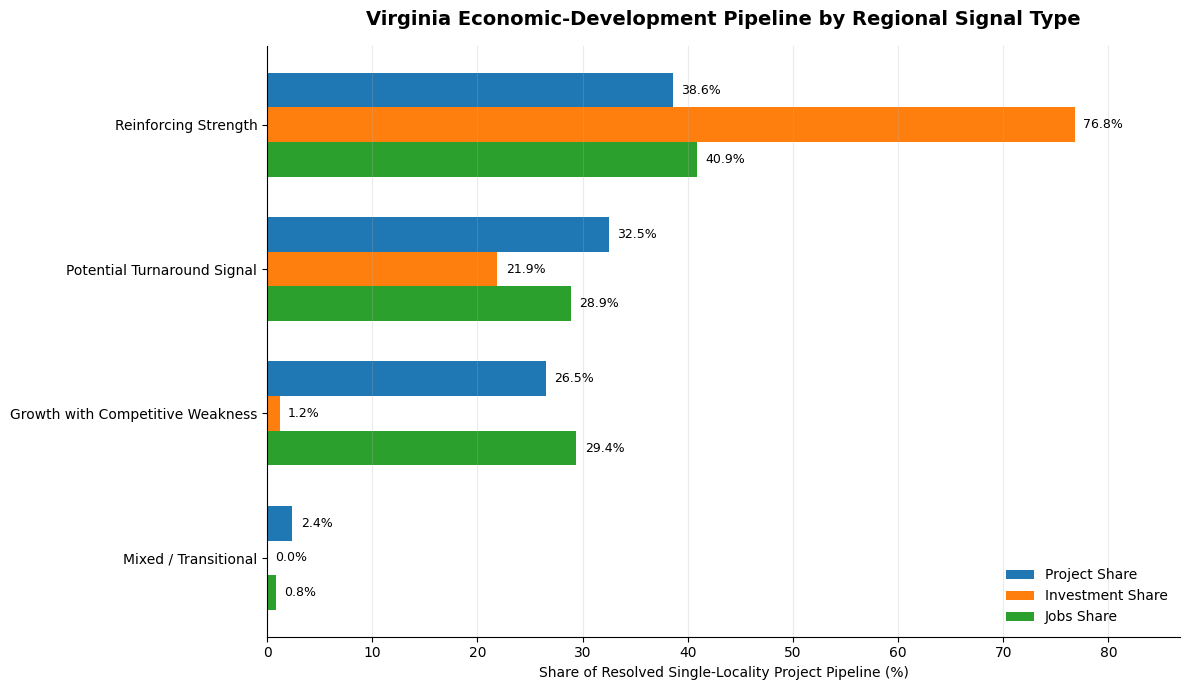

In [193]:
# Visualize project, investment, and job shares by regional signal type.
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

# Preserve the analytical ordering used throughout the notebook.
signal_order = [
    "Reinforcing Strength",
    "Potential Turnaround Signal",
    "Growth with Competitive Weakness",
    "Mixed / Transitional"
]

regional_plot = (
    regional_plot_data
    .set_index("regional_signal_type")
    .loc[signal_order]
    .reset_index()
)

# Reshape to long format for grouped plotting.
regional_plot_long = (
    regional_plot
    .melt(
        id_vars="regional_signal_type",
        value_vars=[
            "project_share_pct",
            "investment_share_pct",
            "jobs_share_pct"
        ],
        var_name="metric",
        value_name="share_pct"
    )
)

metric_labels = {
    "project_share_pct": "Project Share",
    "investment_share_pct": "Investment Share",
    "jobs_share_pct": "Jobs Share"
}

regional_plot_long["metric"] = (
    regional_plot_long["metric"]
    .map(metric_labels)
)

# Create grouped horizontal bars.
fig, ax = plt.subplots(
    figsize=(12, 7)
)

y_positions = np.arange(len(signal_order))
bar_height = 0.24

metrics = [
    "Project Share",
    "Investment Share",
    "Jobs Share"
]

offsets = [
    -bar_height,
    0,
    bar_height
]

for metric, offset in zip(metrics, offsets):

    metric_data = (
        regional_plot_long[
            regional_plot_long["metric"].eq(metric)
        ]
        .set_index("regional_signal_type")
        .loc[signal_order]
    )

    bars = ax.barh(
        y_positions + offset,
        metric_data["share_pct"],
        height=bar_height,
        label=metric
    )

    # Add percentage labels to each bar.
    for bar in bars:

        width = bar.get_width()

        ax.text(
            width + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=9
        )

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    signal_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "Share of Resolved Single-Locality Project Pipeline (%)"
)

ax.set_ylabel("")

ax.set_title(
    "Virginia Economic-Development Pipeline by Regional Signal Type",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.set_xlim(
    0,
    regional_plot_long["share_pct"].max() + 10
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

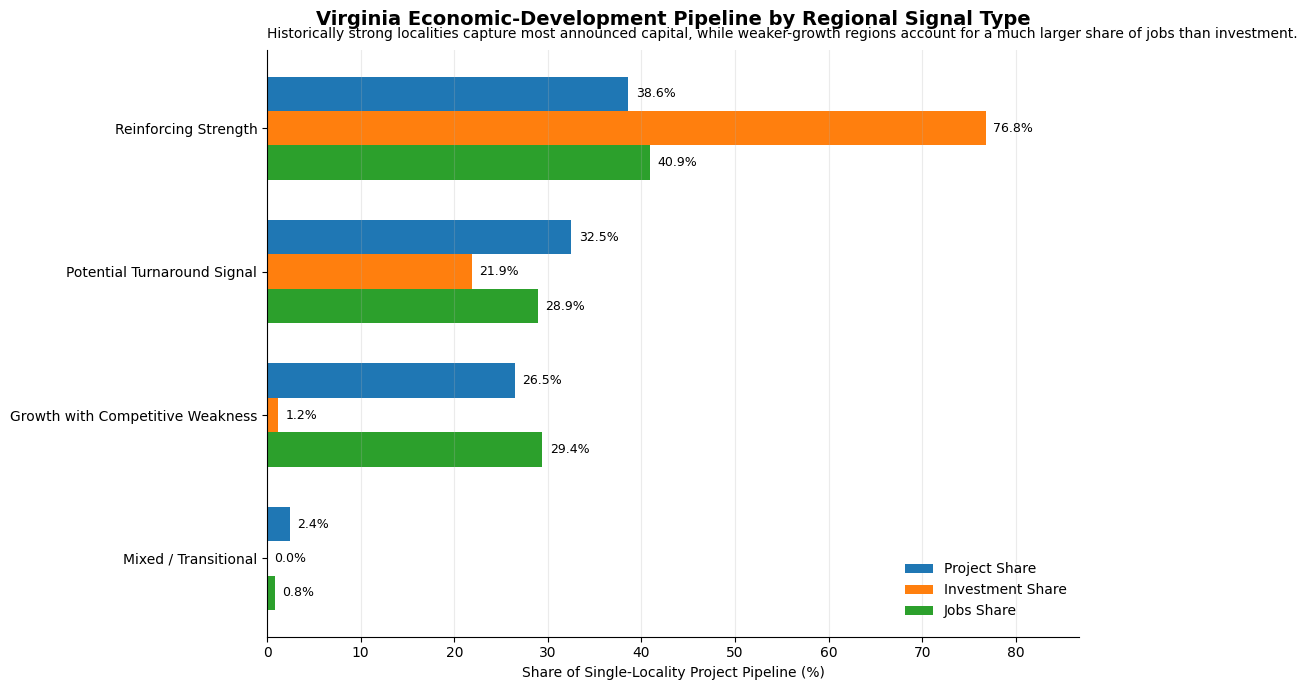

Saved figure: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures\regional_signal_project_investment_jobs_shares.png


In [194]:
# Create and save the polished regional-signal composition chart.
# ----------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 7)
)

y_positions = np.arange(len(signal_order))
bar_height = 0.24

metrics = [
    "Project Share",
    "Investment Share",
    "Jobs Share"
]

offsets = [
    -bar_height,
    0,
    bar_height
]

for metric, offset in zip(metrics, offsets):

    metric_data = (
        regional_plot_long[
            regional_plot_long["metric"].eq(metric)
        ]
        .set_index("regional_signal_type")
        .loc[signal_order]
    )

    bars = ax.barh(
        y_positions + offset,
        metric_data["share_pct"],
        height=bar_height,
        label=metric
    )

    # Add percentage labels.
    for bar in bars:

        width = bar.get_width()

        ax.text(
            width + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=9
        )


ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    signal_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "Share of Single-Locality Project Pipeline (%)"
)

ax.set_ylabel("")

ax.set_title(
    "Virginia Economic-Development Pipeline by Regional Signal Type",
    fontsize=14,
    fontweight="bold",
    pad=18
)

# Add a concise analytical takeaway beneath the title.
ax.text(
    0,
    1.015,
    (
        "Historically strong localities capture most announced capital, "
        "while weaker-growth regions account for a much larger share of jobs than investment."
    ),
    transform=ax.transAxes,
    fontsize=10,
    va="bottom"
)

ax.legend(
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.01)
)

ax.set_xlim(
    0,
    regional_plot_long["share_pct"].max() + 10
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save a high-resolution version for the project outputs.
regional_signal_figure_path = (
    OUTPUT_FIGURES
    / "regional_signal_project_investment_jobs_shares.png"
)

plt.savefig(
    regional_signal_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {regional_signal_figure_path}"
)

### 14.2 Project, Investment, and Job Shares by Industry-Alignment Type

The locality-industry analysis shows that projects differ substantially depending on whether they reinforce an established local industry, support an emerging competitive industry, or represent diversification activity.

The figure below compares each alignment category's share of:

- projects,
- announced investment,
- and announced jobs.

This highlights the contrast between highly capital-intensive emerging industries and employment-intensive established competitive industries.

In [195]:
# Prepare corrected industry-alignment composition data for visualization.

alignment_plot_data = (
    alignment_economic_summary_corrected[
        [
            "industry_alignment_type",
            "project_share_pct",
            "investment_share_pct",
            "jobs_share_pct"
        ]
    ]
    .copy()
)

alignment_order = [
    "Established & Competitive",
    "Established but Losing Ground",
    "Emerging Competitive Industry",
    "Diversification / Turnaround"
]

alignment_plot_data = (
    alignment_plot_data
    .set_index("industry_alignment_type")
    .loc[alignment_order]
    .reset_index()
)

alignment_plot_data

,industry_alignment_type,project_share_pct,investment_share_pct,jobs_share_pct
0,Established & Competitive,33.8,12.5,50.7
1,Established but Losing Ground,32.3,38.8,26.0
2,Emerging Competitive Industry,21.5,48.4,15.3
3,Diversification / Turnaround,12.3,0.2,8.0


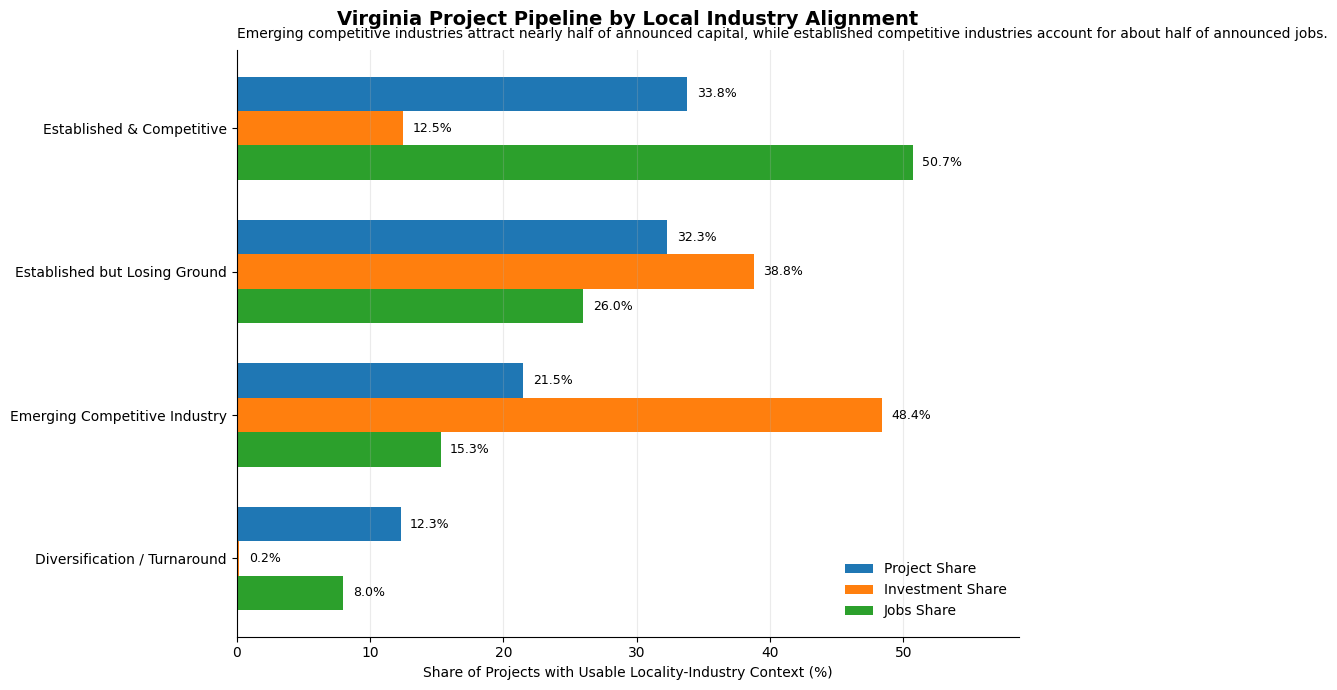

Saved figure: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures\industry_alignment_project_investment_jobs_shares.png


In [196]:
# Visualize project, investment, and job shares by
# locality-industry alignment type.
# ------------------------------------------------

alignment_plot_long = (
    alignment_plot_data
    .melt(
        id_vars="industry_alignment_type",
        value_vars=[
            "project_share_pct",
            "investment_share_pct",
            "jobs_share_pct"
        ],
        var_name="metric",
        value_name="share_pct"
    )
)

alignment_plot_long["metric"] = (
    alignment_plot_long["metric"]
    .map({
        "project_share_pct": "Project Share",
        "investment_share_pct": "Investment Share",
        "jobs_share_pct": "Jobs Share"
    })
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

y_positions = np.arange(len(alignment_order))
bar_height = 0.24

metrics = [
    "Project Share",
    "Investment Share",
    "Jobs Share"
]

offsets = [
    -bar_height,
    0,
    bar_height
]

for metric, offset in zip(metrics, offsets):

    metric_data = (
        alignment_plot_long[
            alignment_plot_long["metric"].eq(metric)
        ]
        .set_index("industry_alignment_type")
        .loc[alignment_order]
    )

    bars = ax.barh(
        y_positions + offset,
        metric_data["share_pct"],
        height=bar_height,
        label=metric
    )

    # Add percentage labels.
    for bar in bars:

        width = bar.get_width()

        ax.text(
            width + 0.7,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=9
        )

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    alignment_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "Share of Projects with Usable Locality-Industry Context (%)"
)

ax.set_ylabel("")

ax.set_title(
    "Virginia Project Pipeline by Local Industry Alignment",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.text(
    0,
    1.015,
    (
        "Emerging competitive industries attract nearly half of announced capital, "
        "while established competitive industries account for about half of announced jobs."
    ),
    transform=ax.transAxes,
    fontsize=10,
    va="bottom"
)

ax.legend(
    frameon=False,
    loc="lower right",
    bbox_to_anchor=(1.0, 0.01)
)

ax.set_xlim(
    0,
    alignment_plot_long["share_pct"].max() + 8
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

alignment_figure_path = (
    OUTPUT_FIGURES
    / "industry_alignment_project_investment_jobs_shares.png"
)

plt.savefig(
    alignment_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {alignment_figure_path}"
)

### 14.3 Announced Investment Across Historical Locality Growth

The previous figures compare aggregate development patterns across regional and industry categories.

The final visualization returns to the locality level and examines whether large announced investments are concentrated in places with strong historical employment growth or are also appearing in historically weaker regions.

Each point represents a Virginia locality with at least one resolved business-investment project:

- the horizontal axis shows 2019–2025 employment growth;
- the vertical axis shows total announced investment;
- point size reflects announced job commitments.

A logarithmic investment scale is used because announced capital ranges from relatively small expansions to multi-billion-dollar projects.

In [197]:
# Prepare locality-level data for the final integrated visualization.
# ------------------------------------------------------------------

locality_scatter_data = (
    locality_signal_context[
        [
            "primary_locality_name",
            "employment_growth_pct",
            "total_announced_investment_usd",
            "total_announced_jobs",
            "regional_signal_type"
        ]
    ]
    .dropna(
        subset=[
            "employment_growth_pct",
            "total_announced_investment_usd"
        ]
    )
    .copy()
)

# Convert historical growth to percentage points for readability.
locality_scatter_data["employment_growth_pct_display"] = (
    locality_scatter_data["employment_growth_pct"] * 100
)

locality_scatter_data.head()

,primary_locality_name,employment_growth_pct,total_announced_investment_usd,total_announced_jobs,regional_signal_type,employment_growth_pct_display
0,Albemarle County,0.053348,4.500000e+09,NaN,Reinforcing Strength,5.334817
1,Arlington County,0.005506,3.060000e+07,924.0,Growth with Competitive Weakness,0.550591
2,Augusta County,0.119903,1.900000e+07,214.0,Reinforcing Strength,11.990343
3,Bland County,0.158184,3.600000e+06,52.0,Reinforcing Strength,15.818432
4,Botetourt County,0.025350,2.995000e+07,270.0,Reinforcing Strength,2.535040


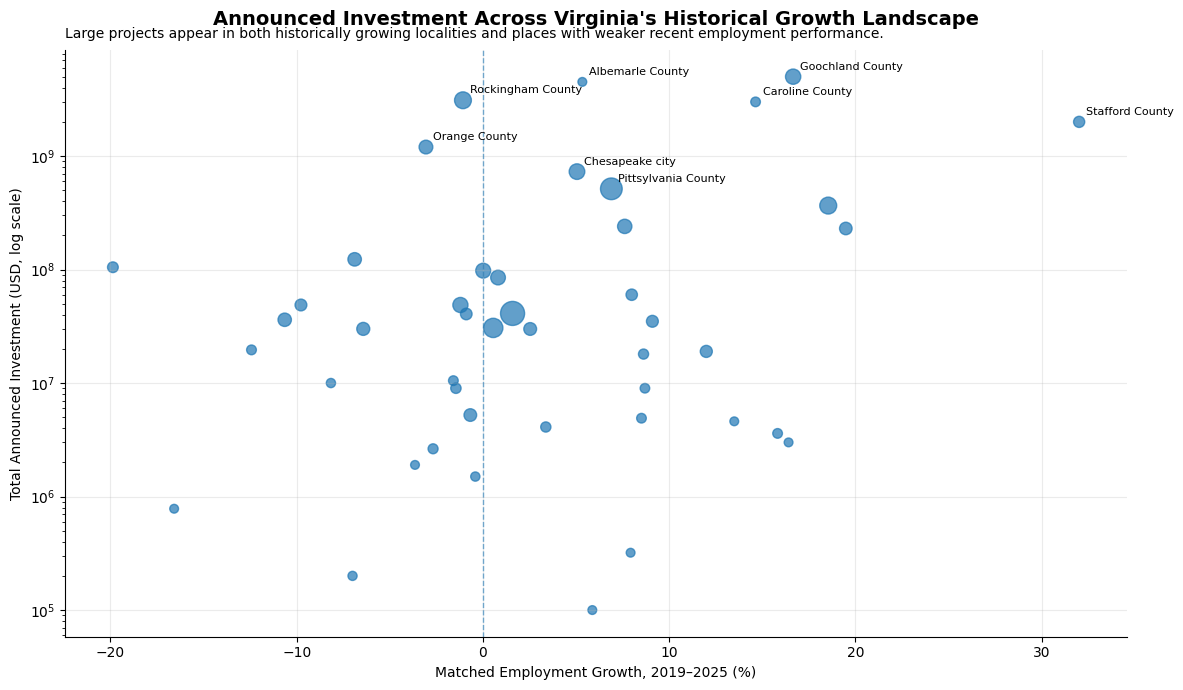

Saved figure: C:\Users\Chris\Documents\virginia-regional-economic-intelligence\outputs\figures\locality_growth_vs_announced_investment.png


In [198]:
# Visualize historical employment growth against recent announced investment.
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 7)
)

# Scale marker sizes by announced jobs.
# A minimum marker size keeps low-job or missing-job projects visible.
job_sizes = (
    locality_scatter_data["total_announced_jobs"]
    .fillna(0)
)

marker_sizes = (
    40
    + 260
    * job_sizes
    / max(job_sizes.max(), 1)
)

ax.scatter(
    locality_scatter_data["employment_growth_pct_display"],
    locality_scatter_data["total_announced_investment_usd"],
    s=marker_sizes,
    alpha=0.7
)

# Use a logarithmic scale because investment values span
# several orders of magnitude.
ax.set_yscale("log")

# Add reference line for zero historical employment growth.
ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.6
)

ax.set_xlabel(
    "Matched Employment Growth, 2019–2025 (%)"
)

ax.set_ylabel(
    "Total Announced Investment (USD, log scale)"
)

ax.set_title(
    "Announced Investment Across Virginia's Historical Growth Landscape",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.text(
    0,
    1.015,
    (
        "Large projects appear in both historically growing localities "
        "and places with weaker recent employment performance."
    ),
    transform=ax.transAxes,
    fontsize=10,
    va="bottom"
)

# Label the largest capital-investment localities.
label_data = (
    locality_scatter_data
    .nlargest(
        8,
        "total_announced_investment_usd"
    )
)

for _, row in label_data.iterrows():

    ax.annotate(
        row["primary_locality_name"],
        (
            row["employment_growth_pct_display"],
            row["total_announced_investment_usd"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.grid(
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

locality_scatter_figure_path = (
    OUTPUT_FIGURES
    / "locality_growth_vs_announced_investment.png"
)

plt.savefig(
    locality_scatter_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {locality_scatter_figure_path}"
)

## 15. Save Structured Document-Intelligence Outputs

The final step before the notebook conclusion is to save the structured datasets created from the VEDP document corpus.

These outputs preserve the project-level document intelligence, locality-level forward-looking signals, and integrated QCEW context for use in later analysis, visualization, or dashboard development.

In [199]:
# Save the primary Notebook 04 analytical outputs.
# -------------------------------------------------

# 1. Full structured VEDP business-project dataset
business_projects.to_csv(
    OUTPUT_TABLES / "vedp_business_projects_structured_2025_2026.csv",
    index=False
)

# 2. Resolved single-locality project context
project_locality_context.to_csv(
    OUTPUT_TABLES / "vedp_project_locality_qcew_context.csv",
    index=False
)

# 3. Locality-level forward-looking project signals
locality_signal_context.to_csv(
    OUTPUT_TABLES / "vedp_locality_project_signals.csv",
    index=False
)

# 4. Project-level locality-industry alignment
project_industry_context.to_csv(
    OUTPUT_TABLES / "vedp_project_industry_qcew_alignment.csv",
    index=False
)

# 5. Headline findings table
headline_findings_formatted.to_csv(
    OUTPUT_TABLES / "document_intelligence_headline_findings.csv",
    index=False
)

print("Saved Notebook 04 outputs:")
print(" - vedp_business_projects_structured_2025_2026.csv")
print(" - vedp_project_locality_qcew_context.csv")
print(" - vedp_locality_project_signals.csv")
print(" - vedp_project_industry_qcew_alignment.csv")
print(" - document_intelligence_headline_findings.csv")

Saved Notebook 04 outputs:
 - vedp_business_projects_structured_2025_2026.csv
 - vedp_project_locality_qcew_context.csv
 - vedp_locality_project_signals.csv
 - vedp_project_industry_qcew_alignment.csv
 - document_intelligence_headline_findings.csv


## 16. Answer to Research Question

### Research Question

**What forward-looking economic-development signals can be extracted from public Virginia documents, and how do those signals relate to the regional employment patterns identified in the QCEW analysis?**

### Answer

The VEDP press-release corpus provides a clear forward-looking signal of where new capital, jobs, and strategic economic activity are being announced across Virginia.

The document-intelligence pipeline identified 87 business-investment projects and converted unstructured press releases into structured information on company, locality, investment, job creation, industry, strategic theme, and latent NLP topic. Of these, 83 projects had sufficiently precise single-locality geography for direct integration with QCEW regional indicators.

The combined analysis shows that recent project activity is not concentrated exclusively in historically strong regions.

Historically growing and competitively strong localities received 38.6% of resolved projects but captured 76.8% of announced single-locality capital investment. This indicates that a substantial share of large, capital-intensive projects is reinforcing places that already exhibit positive employment growth and favorable competitive effects.

At the same time, 32.5% of projects occurred in localities classified as potential turnaround areas—places with both negative historical employment growth and negative regional competitive effects. These projects represented 21.9% of announced investment and 28.9% of announced jobs, suggesting that recent economic-development activity may also be creating new growth opportunities in weaker regional economies.

The industry-level analysis provides a similarly mixed picture. Among projects with usable locality-industry QCEW context, 33.8% occurred in industries that were already both specialized and competitive, while 32.3% reinforced specialized industries that had recently been losing competitive ground. Another 21.5% occurred in emerging competitive industries, and 12.3% represented diversification or turnaround activity.

The economic scale of these categories differs substantially. Emerging competitive industries accounted for 48.4% of announced investment but only 15.3% of announced jobs, indicating a highly capital-intensive project mix. In contrast, established and competitive industries accounted for 50.7% of announced jobs but only 12.5% of investment.

Taken together, the results suggest that Virginia's recent economic-development pipeline reflects both **reinforcement and structural change**. Large capital investments are disproportionately flowing toward regions and industries with demonstrated competitive momentum, while a meaningful share of projects and employment commitments is also appearing in historically weaker localities or less-established industries.

The document corpus therefore adds a useful forward-looking layer to the QCEW analysis: historical employment data describe where regional economies have been, while announced projects provide early signals of where future economic activity may be developing.

## 17. Conclusion

This notebook demonstrates how public economic-development documents can be transformed into a structured regional-intelligence dataset and integrated with traditional labor-market statistics.

The workflow combined:

- web-based document discovery and extraction;
- rule-based entity, geography, investment, and employment extraction;
- QCEW-aligned industry classification;
- strategic economic-theme classification;
- TF-IDF and NMF topic modeling;
- location quotients and shift-share indicators;
- and locality- and industry-level economic integration.

Several validation steps were intentionally built into the workflow. Ambiguous geography, repeated financial figures, missing QCEW observations, entity-extraction errors, and statewide or multi-locality projects were reviewed explicitly rather than silently forced into the analytical sample.

This is especially important for applied economic intelligence: automated document extraction can scale analysis, but high-quality regional conclusions still depend on careful validation and transparent treatment of uncertainty.

The resulting dataset provides a reusable framework for monitoring Virginia's economic-development pipeline. As new VEDP announcements become available, the same workflow could be rerun to track changes in investment, job creation, strategic industries, and emerging regional clusters over time.

Most importantly, the analysis shows the value of combining **backward-looking administrative data with forward-looking unstructured information**. QCEW data measure realized employment structure and competitive performance, while economic-development announcements provide earlier signals of planned capital formation and employment growth.

Together, these sources provide a richer view of Virginia's evolving regional economy than either source can provide independently.